In [1]:
# =============================================================================
# MODEL 3A - STEP 1
# CLEAN COLAB-ONLY 8-CLASS PROJECT
# =============================================================================

import os
import shutil
import json

print("=" * 80)
print("MODEL 3A - STEP 1")
print("COLAB-ONLY CLEAN PROJECT")
print("=" * 80)

BASE = "/content/model3a"

# -------------------------------------------------------------------------
# CLEAN OLD MODEL3A DIRECTORY
# -------------------------------------------------------------------------

if os.path.exists(BASE):

    print(
        "\nRemoving previous /content/model3a ..."
    )

    shutil.rmtree(BASE)

    print(
        "✅ Old project removed."
    )

# -------------------------------------------------------------------------
# CREATE PROJECT STRUCTURE
# -------------------------------------------------------------------------

PATHS = {

    "root":
        BASE,

    "raw":
        os.path.join(
            BASE,
            "raw"
        ),

    "processed":
        os.path.join(
            BASE,
            "processed"
        ),

    "segmented":
        os.path.join(
            BASE,
            "segmented"
        ),

    "dataset":
        os.path.join(
            BASE,
            "final_dataset"
        ),

    "manifests":
        os.path.join(
            BASE,
            "manifests"
        ),

    "audit":
        os.path.join(
            BASE,
            "audit"
        ),

    "models":
        os.path.join(
            BASE,
            "models"
        ),

    "checkpoints":
        os.path.join(
            BASE,
            "models",
            "checkpoints"
        ),

    "results":
        os.path.join(
            BASE,
            "training_results"
        ),

    "evaluation":
        os.path.join(
            BASE,
            "evaluation"
        )
}

for name, path in PATHS.items():

    os.makedirs(
        path,
        exist_ok=True
    )

    print(
        f"✅ {name:<12} {path}"
    )

# -------------------------------------------------------------------------
# EXACT CLASS ORDER
# -------------------------------------------------------------------------

CLASSES = [
    "No_Tumor",
    "Glioma",
    "Meningioma",
    "Pituitary",
    "Brain_Metastasis",
    "Schwannoma",
    "Meduloblastoma",
    "Ependymoma"
]

CLASS_TO_INDEX = {
    name: i
    for i, name in enumerate(CLASSES)
}

INDEX_TO_CLASS = {
    i: name
    for i, name in enumerate(CLASSES)
}

# -------------------------------------------------------------------------
# CONFIG
# -------------------------------------------------------------------------

CONFIG = {

    "project":
        "Model3A",

    "storage":
        "COLAB_ONLY",

    "num_classes":
        8,

    "classes":
        CLASSES,

    "class_to_index":
        CLASS_TO_INDEX,

    "index_to_class":
        INDEX_TO_CLASS,

    "image_size":
        [224, 224],

    "seed":
        42
}

CONFIG_PATH = os.path.join(
    BASE,
    "config.json"
)

with open(
    CONFIG_PATH,
    "w"
) as f:

    json.dump(
        CONFIG,
        f,
        indent=4
    )

# -------------------------------------------------------------------------
# CLASS DISPLAY
# -------------------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL CLASS ORDER")
print("=" * 80)

for i, name in enumerate(CLASSES):

    print(
        f"{i}  {name}"
    )

print("\nConfig:")
print(CONFIG_PATH)

print("\n" + "=" * 80)
print("✅ STEP 1 COMPLETE")
print("=" * 80)

print("""
STORAGE:
Everything is currently inside /content/model3a

Google Drive:
NOT USED
""")

MODEL 3A - STEP 1
COLAB-ONLY CLEAN PROJECT
✅ root         /content/model3a
✅ raw          /content/model3a/raw
✅ processed    /content/model3a/processed
✅ segmented    /content/model3a/segmented
✅ dataset      /content/model3a/final_dataset
✅ manifests    /content/model3a/manifests
✅ audit        /content/model3a/audit
✅ models       /content/model3a/models
✅ checkpoints  /content/model3a/models/checkpoints
✅ results      /content/model3a/training_results
✅ evaluation   /content/model3a/evaluation

FINAL CLASS ORDER
0  No_Tumor
1  Glioma
2  Meningioma
3  Pituitary
4  Brain_Metastasis
5  Schwannoma
6  Meduloblastoma
7  Ependymoma

Config:
/content/model3a/config.json

✅ STEP 1 COMPLETE

STORAGE:
Everything is currently inside /content/model3a

Google Drive:
NOT USED



In [1]:
# =============================================================================
# MODEL 3A - STEP 2
# INSTALL DEPENDENCIES
# =============================================================================

import subprocess
import sys

print("=" * 80)
print("MODEL 3A - STEP 2")
print("INSTALLING DEPENDENCIES")
print("=" * 80)

packages = [
    "kaggle",
    "nibabel",
    "opencv-python-headless",
    "scikit-learn",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn"
]

for package in packages:

    print(
        f"\nInstalling {package}..."
    )

    result = subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package
        ]
    )

    if result.returncode != 0:

        raise RuntimeError(
            f"Failed installing {package}"
        )

    print(
        f"✅ {package}"
    )

print("\n" + "=" * 80)
print("VERIFYING")
print("=" * 80)

import numpy
import pandas
import cv2
import nibabel
import sklearn

print(
    "NumPy:",
    numpy.__version__
)

print(
    "Pandas:",
    pandas.__version__
)

print(
    "OpenCV:",
    cv2.__version__
)

print(
    "NiBabel:",
    nibabel.__version__
)

print(
    "Scikit-learn:",
    sklearn.__version__
)

print("\n" + "=" * 80)
print("✅ STEP 2 COMPLETE")
print("=" * 80)

MODEL 3A - STEP 2
INSTALLING DEPENDENCIES

Installing kaggle...
✅ kaggle

Installing nibabel...
✅ nibabel

Installing opencv-python-headless...
✅ opencv-python-headless

Installing scikit-learn...
✅ scikit-learn

Installing pandas...
✅ pandas

Installing numpy...
✅ numpy

Installing matplotlib...
✅ matplotlib

Installing seaborn...
✅ seaborn

VERIFYING
NumPy: 2.0.2
Pandas: 2.2.2
OpenCV: 5.0.0
NiBabel: 5.4.2
Scikit-learn: 1.6.1

✅ STEP 2 COMPLETE


In [2]:
# =============================================================================
# MODEL 3A - STEP 3
# KAGGLE AUTHENTICATION
# =============================================================================

import os
import shutil

from google.colab import files

print("=" * 80)
print("MODEL 3A - STEP 3")
print("KAGGLE AUTHENTICATION")
print("=" * 80)

KAGGLE_DIR = "/root/.kaggle"
KAGGLE_JSON = os.path.join(
    KAGGLE_DIR,
    "kaggle.json"
)

os.makedirs(
    KAGGLE_DIR,
    exist_ok=True
)

if not os.path.exists(
    KAGGLE_JSON
):

    print("""
Upload your Kaggle API key.

Kaggle:
Settings
→ API
→ Create New Token

Upload:
kaggle.json
""")

    uploaded = files.upload()

    if "kaggle.json" not in uploaded:

        raise RuntimeError(
            "kaggle.json was not uploaded."
        )

    shutil.move(
        "kaggle.json",
        KAGGLE_JSON
    )

    os.chmod(
        KAGGLE_JSON,
        0o600
    )

else:

    print(
        "✅ Kaggle API key already exists."
    )

# -------------------------------------------------------------------------
# VERIFY
# -------------------------------------------------------------------------

import subprocess

result = subprocess.run(
    [
        "kaggle",
        "datasets",
        "list",
        "-s",
        "brain tumor"
    ],
    capture_output=True,
    text=True
)

if result.returncode != 0:

    print(result.stderr)

    raise RuntimeError(
        "Kaggle authentication failed."
    )

print(
    result.stdout[:5000]
)

print("\n" + "=" * 80)
print("✅ STEP 3 COMPLETE")
print("=" * 80)

MODEL 3A - STEP 3
KAGGLE AUTHENTICATION

Upload your Kaggle API key.

Kaggle:
Settings
→ API
→ Create New Token

Upload:
kaggle.json



Saving kaggle.json to kaggle.json
ref                                                       title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
jakeshbohaju/brain-tumor                                  Brain Tumor                                          14629270  2020-07-26 01:52:35.323000          27705        350  0.9411765        
masoudnickparvar/brain-tumor-mri-dataset                  Brain Tumor MRI Dataset                             164670110  2026-02-13 19:25:36.413000         208363       1417  0.875            
sartajbhuvaji/brain-tumor-classification-mri              Brain Tumor Classification (MRI)                     91002358  2025-08-12 15:45:16.840000         103224        866  0.875            
j

In [5]:
# =============================================================================
# MODEL 3A - STEP 4
# DOWNLOAD 4-CLASS BRAIN TUMOR MRI DATASET
# COLAB ONLY — NO GOOGLE DRIVE
# =============================================================================

import os
import subprocess
import shutil

print("=" * 80)
print("MODEL 3A - STEP 4")
print("DOWNLOADING 4-CLASS MRI DATASET")
print("=" * 80)

# =============================================================================
# PATHS — SELF CONTAINED
# =============================================================================

BASE = "/content/model3a"

RAW_DIR = os.path.join(
    BASE,
    "raw"
)

DEST = os.path.join(
    RAW_DIR,
    "4class"
)

os.makedirs(
    DEST,
    exist_ok=True
)

print("\nStorage:")
print("COLAB:", DEST)
print("DRIVE: NOT USED")

# =============================================================================
# KAGGLE CHECK
# =============================================================================

KAGGLE_JSON = "/root/.kaggle/kaggle.json"

if not os.path.exists(KAGGLE_JSON):

    raise RuntimeError(
        """
Kaggle authentication not found.

Run the Kaggle authentication cell first.
Upload kaggle.json to:

/root/.kaggle/kaggle.json
"""
    )

print(
    "\n✅ Kaggle authentication found."
)

# =============================================================================
# DATASET
# =============================================================================

DATASET = (
    "masoudnickparvar/"
    "brain-tumor-mri-dataset"
)

print(
    "\nDataset:",
    DATASET
)

print(
    "Destination:",
    DEST
)

# =============================================================================
# DOWNLOAD
# =============================================================================

print("\n" + "=" * 80)
print("DOWNLOADING")
print("=" * 80)

result = subprocess.run(
    [
        "kaggle",
        "datasets",
        "download",
        "-d",
        DATASET,
        "-p",
        DEST,
        "--unzip"
    ],
    capture_output=True,
    text=True
)

print(
    result.stdout
)

if result.returncode != 0:

    print(
        result.stderr
    )

    raise RuntimeError(
        "❌ 4-class dataset download failed."
    )

print(
    "✅ Download completed."
)

# =============================================================================
# FIND IMAGE FILES
# =============================================================================

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

print("\n" + "=" * 80)
print("SCANNING DOWNLOADED DATA")
print("=" * 80)

class_counts = {}

total_images = 0

for root, dirs, files in os.walk(
    DEST
):

    image_files = [
        f for f in files
        if f.lower().endswith(
            IMAGE_EXTENSIONS
        )
    ]

    if not image_files:
        continue

    folder_name = os.path.basename(
        root
    )

    count = len(
        image_files
    )

    class_counts[
        folder_name
    ] = class_counts.get(
        folder_name,
        0
    ) + count

    total_images += count

    print(
        f"{count:6d}  {folder_name}"
    )

# =============================================================================
# EXPECTED CLASSES
# =============================================================================

print("\n" + "=" * 80)
print("EXPECTED CLASSES")
print("=" * 80)

expected = [
    "glioma",
    "meningioma",
    "pituitary",
    "notumor"
]

for cls in expected:

    found = False

    for name, count in class_counts.items():

        if name.lower() == cls.lower():

            print(
                f"✅ {cls:<15} {count}"
            )

            found = True

    if not found:

        print(
            f"❌ {cls:<15} NOT FOUND"
        )

# =============================================================================
# FINAL CHECK
# =============================================================================

print("\n" + "=" * 80)
print("DOWNLOAD SUMMARY")
print("=" * 80)

print(
    "Total images:",
    total_images
)

print(
    "Location:",
    DEST
)

if total_images == 0:

    raise RuntimeError(
        "❌ No images were found after download."
    )

print("\n" + "=" * 80)
print("✅ STEP 4 COMPLETE")
print("=" * 80)

print("""
4-class source is now available in Colab:

/content/model3a/raw/4class

Classes:
    No_Tumor
    Glioma
    Meningioma
    Pituitary

Nothing was saved to Google Drive.
""")

MODEL 3A - STEP 4
DOWNLOADING 4-CLASS MRI DATASET

Storage:
COLAB: /content/model3a/raw/4class
DRIVE: NOT USED

✅ Kaggle authentication found.

Dataset: masoudnickparvar/brain-tumor-mri-dataset
Destination: /content/model3a/raw/4class

DOWNLOADING
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)


✅ Download completed.

SCANNING DOWNLOADED DATA
   400  glioma
   400  notumor
   400  meningioma
   400  pituitary
  1400  glioma
  1400  notumor
  1400  meningioma
  1400  pituitary

EXPECTED CLASSES
✅ glioma          1800
✅ meningioma      1800
✅ pituitary       1800
✅ notumor         1800

DOWNLOAD SUMMARY
Total images: 7200
Location: /content/model3a/raw/4class

✅ STEP 4 COMPLETE

4-class source is now available in Colab:

/content/model3a/raw/4class

Classes:
    No_Tumor
    Glioma
    Meningioma
    Pituitary

Nothing was saved to Google Drive.



In [6]:
# =============================================================================
# MODEL 3A - STEP 5
# DOWNLOAD 44-CLASS BRAIN TUMOR MRI DATASET
# COLAB ONLY — NO GOOGLE DRIVE
# =============================================================================

import os
import subprocess

print("=" * 80)
print("MODEL 3A - STEP 5")
print("DOWNLOADING 44-CLASS MRI DATASET")
print("=" * 80)

# =============================================================================
# PATHS — SELF CONTAINED
# =============================================================================

BASE = "/content/model3a"

DEST = os.path.join(
    BASE,
    "raw",
    "44class"
)

os.makedirs(
    DEST,
    exist_ok=True
)

print(
    "Destination:",
    DEST
)

print(
    "Google Drive: NOT USED"
)

# =============================================================================
# KAGGLE CHECK
# =============================================================================

KAGGLE_JSON = "/root/.kaggle/kaggle.json"

if not os.path.exists(
    KAGGLE_JSON
):

    raise RuntimeError(
        "Kaggle authentication not found."
    )

# =============================================================================
# DATASET
# =============================================================================

DATASET = (
    "fernando2rad/"
    "brain-tumor-mri-images-44c"
)

print(
    "\nDataset:",
    DATASET
)

# =============================================================================
# DOWNLOAD
# =============================================================================

print("\n" + "=" * 80)
print("DOWNLOADING")
print("=" * 80)

result = subprocess.run(
    [
        "kaggle",
        "datasets",
        "download",
        "-d",
        DATASET,
        "-p",
        DEST,
        "--unzip"
    ],
    capture_output=True,
    text=True
)

print(
    result.stdout
)

if result.returncode != 0:

    print(
        result.stderr
    )

    raise RuntimeError(
        "❌ 44-class dataset download failed."
    )

print(
    "✅ Download completed."
)

# =============================================================================
# SCAN TARGET CLASSES
# =============================================================================

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

targets = {
    "Schwannoma": [],
    "Meduloblastoma": [],
    "Ependimoma": []
}

all_folders = []

total_images = 0

for root, dirs, files in os.walk(
    DEST
):

    image_files = [
        f for f in files
        if f.lower().endswith(
            IMAGE_EXTENSIONS
        )
    ]

    if not image_files:
        continue

    folder = os.path.basename(
        root
    )

    count = len(
        image_files
    )

    total_images += count

    all_folders.append(
        (
            folder,
            count,
            root
        )
    )

    for target in targets:

        if target.lower() in folder.lower():

            targets[target].append(
                (
                    folder,
                    count,
                    root
                )
            )

# =============================================================================
# DISPLAY TARGETS
# =============================================================================

print("\n" + "=" * 80)
print("TARGET CLASSES")
print("=" * 80)

for target, matches in targets.items():

    print(
        f"\n{target}"
    )

    if not matches:

        print(
            "  ❌ NOT FOUND"
        )

    else:

        total = 0

        for folder, count, root in matches:

            print(
                f"  ✅ {count:4d}  {folder}"
            )

            total += count

        print(
            f"  TOTAL: {total}"
        )

# =============================================================================
# COMPLETE FOLDER SCAN
# =============================================================================

print("\n" + "=" * 80)
print("ALL SOURCE FOLDERS")
print("=" * 80)

for folder, count, root in sorted(
    all_folders
):

    print(
        f"{count:6d}  {folder}"
    )

print(
    "\nTotal images:",
    total_images
)

print("\n" + "=" * 80)
print("✅ STEP 5 COMPLETE")
print("=" * 80)

MODEL 3A - STEP 5
DOWNLOADING 44-CLASS MRI DATASET
Destination: /content/model3a/raw/44class
Google Drive: NOT USED

Dataset: fernando2rad/brain-tumor-mri-images-44c

DOWNLOADING
Dataset URL: https://www.kaggle.com/datasets/fernando2rad/brain-tumor-mri-images-44c
License(s): Community Data License Agreement - Sharing - Version 1.0


✅ Download completed.

TARGET CLASSES

Schwannoma
  ✅  194  Schwannoma T1C+
  ✅  123  Schwannoma T2
  ✅  148  Schwannoma T1
  TOTAL: 465

Meduloblastoma
  ✅   23  Meduloblastoma T1
  ✅   41  Meduloblastoma T2
  ✅   67  Meduloblastoma T1C+
  TOTAL: 131

Ependimoma
  ✅   45  Ependimoma T1
  ✅   57  Ependimoma T2
  ✅   48  Ependimoma T1C+
  TOTAL: 150

ALL SOURCE FOLDERS
   176  Astrocitoma T1
   233  Astrocitoma T1C+
   171  Astrocitoma T2
    66  Carcinoma T1
   112  Carcinoma T1C+
    73  Carcinoma T2
    45  Ependimoma T1
    48  Ependimoma T1C+
    57  Ependimoma T2
    20  Ganglioglioma T1
    18  Ganglioglioma T1C+
    23  Ganglioglioma T2
    27  Germi

In [7]:
# =============================================================================
# MODEL 3A - STEP 6
# DOWNLOAD BRAIN METASTASIS MRI + SEGMENTATION
# COLAB ONLY
# =============================================================================

import os
import subprocess

print("=" * 80)
print("MODEL 3A - STEP 6")
print("BRAIN METASTASIS MRI + SEGMENTATION")
print("=" * 80)

BASE = "/content/model3a"

DEST = os.path.join(
    BASE,
    "raw",
    "brain_metastasis"
)

os.makedirs(DEST, exist_ok=True)

DATASET = "nayeemasultana/pretreat-metstobrain-masks"

print("Dataset:", DATASET)
print("Destination:", DEST)
print("Google Drive: NOT USED")

# =============================================================================
# KAGGLE CHECK
# =============================================================================

if not os.path.exists("/root/.kaggle/kaggle.json"):
    raise RuntimeError("Kaggle authentication not found.")

# =============================================================================
# DOWNLOAD
# =============================================================================

print("\n" + "=" * 80)
print("DOWNLOADING")
print("=" * 80)

result = subprocess.run(
    [
        "kaggle",
        "datasets",
        "download",
        "-d", DATASET,
        "-p", DEST,
        "--unzip"
    ],
    text=True
)

if result.returncode != 0:
    raise RuntimeError("Brain metastasis dataset download failed.")

# =============================================================================
# SCAN NIFTI FILES
# =============================================================================

print("\n" + "=" * 80)
print("SCANNING NIFTI DATA")
print("=" * 80)

nifti_files = []

for root, dirs, files in os.walk(DEST):
    for filename in files:
        if filename.lower().endswith((".nii", ".nii.gz")):
            nifti_files.append(
                os.path.join(root, filename)
            )

print("NIfTI files:", len(nifti_files))

# =============================================================================
# SIZE
# =============================================================================

total_bytes = 0

for root, dirs, files in os.walk(DEST):
    for filename in files:
        path = os.path.join(root, filename)

        try:
            total_bytes += os.path.getsize(path)
        except OSError:
            pass

print(
    "Dataset size:",
    f"{total_bytes / (1024**3):.2f} GB"
)

if len(nifti_files) == 0:
    raise RuntimeError("No NIfTI files found.")

print("\nFirst 10 NIfTI files:")

for path in nifti_files[:10]:
    print(" ", os.path.basename(path))

print("\n" + "=" * 80)
print("✅ STEP 6 COMPLETE")
print("=" * 80)

MODEL 3A - STEP 6
BRAIN METASTASIS MRI + SEGMENTATION
Dataset: nayeemasultana/pretreat-metstobrain-masks
Destination: /content/model3a/raw/brain_metastasis
Google Drive: NOT USED

DOWNLOADING

SCANNING NIFTI DATA
NIfTI files: 1000
Dataset size: 19.17 GB

First 10 NIfTI files:
  BraTS-MET-00227-000-t2w.nii
  BraTS-MET-00227-000-t1c.nii
  BraTS-MET-00227-000-seg.nii
  BraTS-MET-00227-000-t1n.nii
  BraTS-MET-00227-000-t2f.nii
  BraTS-MET-00167-000-t2w.nii
  BraTS-MET-00167-000-t1n.nii
  BraTS-MET-00167-000-t2f.nii
  BraTS-MET-00167-000-t1c.nii
  BraTS-MET-00167-000-seg.nii

✅ STEP 6 COMPLETE


In [8]:
# =============================================================================
# MODEL 3A - STEP 7
# VERIFY BRAIN METASTASIS PATIENT PAIRING
# =============================================================================

import os
import re
import pandas as pd

print("=" * 80)
print("MODEL 3A - STEP 7")
print("VERIFYING BRAIN METASTASIS MRI ↔ MASK PAIRING")
print("=" * 80)

BASE = "/content/model3a"

MET_ROOT = os.path.join(
    BASE,
    "raw",
    "brain_metastasis"
)

MANIFEST_DIR = os.path.join(
    BASE,
    "manifests"
)

os.makedirs(
    MANIFEST_DIR,
    exist_ok=True
)

# =============================================================================
# FIND NIFTI
# =============================================================================

nifti_files = []

for root, dirs, files in os.walk(MET_ROOT):

    for filename in files:

        if filename.lower().endswith((".nii", ".nii.gz")):

            nifti_files.append(
                os.path.join(root, filename)
            )

print("\nNIfTI files found:", len(nifti_files))

# =============================================================================
# PARSE
# =============================================================================

pattern = re.compile(
    r"(BraTS-MET-\d{5}-\d{3})-(seg|t1c|t1n|t2f|t2w)\.nii(?:\.gz)?$",
    re.IGNORECASE
)

patients = {}
unrecognized = []

for path in nifti_files:

    filename = os.path.basename(path)

    match = pattern.match(filename)

    if not match:
        unrecognized.append(path)
        continue

    patient_id = match.group(1)
    modality = match.group(2).lower()

    patients.setdefault(
        patient_id,
        {}
    )[modality] = path

# =============================================================================
# VALIDATE
# =============================================================================

required = [
    "seg",
    "t1c",
    "t1n",
    "t2f",
    "t2w"
]

records = []

for patient_id, mapping in sorted(patients.items()):

    missing = [
        modality
        for modality in required
        if modality not in mapping
    ]

    records.append({
        "patient_id": patient_id,
        "seg": mapping.get("seg"),
        "t1c": mapping.get("t1c"),
        "t1n": mapping.get("t1n"),
        "t2f": mapping.get("t2f"),
        "t2w": mapping.get("t2w"),
        "valid": len(missing) == 0,
        "missing": ",".join(missing)
    })

df = pd.DataFrame(records)

# =============================================================================
# RESULTS
# =============================================================================

valid_count = int(df["valid"].sum())
invalid_count = len(df) - valid_count

print("\n" + "=" * 80)
print("PATIENT SUMMARY")
print("=" * 80)

print("Patients identified :", len(df))
print("Valid patients      :", valid_count)
print("Invalid patients    :", invalid_count)
print("Unrecognized files  :", len(unrecognized))

if invalid_count:

    print("\nInvalid:")
    print(
        df.loc[
            ~df["valid"],
            ["patient_id", "missing"]
        ].to_string(index=False)
    )

# =============================================================================
# SAVE LOCALLY
# =============================================================================

manifest_path = os.path.join(
    MANIFEST_DIR,
    "brain_metastasis_patient_pairing.csv"
)

df.to_csv(
    manifest_path,
    index=False
)

print("\nManifest:")
print(manifest_path)

# =============================================================================
# FINAL
# =============================================================================

if valid_count == 0:
    raise RuntimeError("No valid metastasis patients.")

print("\n" + "=" * 80)
print("✅ STEP 7 COMPLETE")
print("=" * 80)

MODEL 3A - STEP 7
VERIFYING BRAIN METASTASIS MRI ↔ MASK PAIRING

NIfTI files found: 1000

PATIENT SUMMARY
Patients identified : 200
Valid patients      : 200
Invalid patients    : 0
Unrecognized files  : 0

Manifest:
/content/model3a/manifests/brain_metastasis_patient_pairing.csv

✅ STEP 7 COMPLETE


In [9]:
# =============================================================================
# MODEL 3A - STEP 8
# INSPECT NIFTI DIMENSIONS + SEGMENTATION LABELS
# COLAB ONLY
# =============================================================================

import os
import json
import numpy as np
import pandas as pd
import nibabel as nib

print("=" * 80)
print("MODEL 3A - STEP 8")
print("INSPECTING NIFTI DIMENSIONS + SEGMENTATION LABELS")
print("=" * 80)

BASE = "/content/model3a"

PAIR_MANIFEST = os.path.join(
    BASE,
    "manifests",
    "brain_metastasis_patient_pairing.csv"
)

AUDIT_DIR = os.path.join(
    BASE,
    "audit"
)

os.makedirs(
    AUDIT_DIR,
    exist_ok=True
)

df = pd.read_csv(PAIR_MANIFEST)

df = df[df["valid"] == True].copy()

print("\nValid patients:", len(df))

# =============================================================================
# SAMPLE PATIENTS
# =============================================================================

sample_patients = df["patient_id"].head(5).tolist()

dimension_records = []
label_records = []

for patient_id in sample_patients:

    row = df[
        df["patient_id"] == patient_id
    ].iloc[0]

    print("\n" + "-" * 70)
    print("PATIENT:", patient_id)
    print("-" * 70)

    # -------------------------------------------------------------------------
    # MRI
    # -------------------------------------------------------------------------

    for modality in ["t1c", "t1n", "t2f", "t2w"]:

        path = row[modality]

        img = nib.load(path)

        data = img.get_fdata()

        print(
            f"{modality.upper():5s} "
            f"shape={data.shape} "
            f"min={data.min():.2f} "
            f"max={data.max():.2f}"
        )

        dimension_records.append({
            "patient_id": patient_id,
            "modality": modality,
            "shape": str(data.shape),
            "min": float(data.min()),
            "max": float(data.max())
        })

    # -------------------------------------------------------------------------
    # SEGMENTATION
    # -------------------------------------------------------------------------

    seg_img = nib.load(
        row["seg"]
    )

    seg = seg_img.get_fdata()

    unique, counts = np.unique(
        seg,
        return_counts=True
    )

    print("\nSEGMENTATION")
    print(
        "shape:",
        seg.shape
    )

    print(
        "labels:",
        unique
    )

    print(
        "non-zero voxels:",
        int(np.count_nonzero(seg))
    )

    for label, count in zip(
        unique,
        counts
    ):

        print(
            f"  label {label:g}: "
            f"{int(count):,} voxels"
        )

        label_records.append({
            "patient_id": patient_id,
            "label": float(label),
            "voxel_count": int(count)
        })

# =============================================================================
# CHECK ALL PATIENTS FOR NON-EMPTY MASK
# =============================================================================

print("\n" + "=" * 80)
print("CHECKING ALL 200 SEGMENTATION MASKS")
print("=" * 80)

mask_summary = []

for i, (_, row) in enumerate(
    df.iterrows(),
    start=1
):

    seg_img = nib.load(
        row["seg"]
    )

    seg = seg_img.get_fdata()

    nonzero = int(
        np.count_nonzero(seg)
    )

    mask_summary.append({
        "patient_id": row["patient_id"],
        "shape": str(seg.shape),
        "nonzero_voxels": nonzero,
        "has_tumor": nonzero > 0
    })

    if i % 25 == 0:
        print(
            f"Checked {i}/{len(df)}"
        )

mask_df = pd.DataFrame(
    mask_summary
)

# =============================================================================
# SAVE SMALL AUDIT FILES
# =============================================================================

dimensions_path = os.path.join(
    AUDIT_DIR,
    "brain_metastasis_dimensions.csv"
)

labels_path = os.path.join(
    AUDIT_DIR,
    "brain_metastasis_labels.csv"
)

mask_path = os.path.join(
    AUDIT_DIR,
    "brain_metastasis_mask_summary.csv"
)

pd.DataFrame(
    dimension_records
).to_csv(
    dimensions_path,
    index=False
)

pd.DataFrame(
    label_records
).to_csv(
    labels_path,
    index=False
)

mask_df.to_csv(
    mask_path,
    index=False
)

# =============================================================================
# SUMMARY
# =============================================================================

global_labels = sorted(
    mask_df.empty
    and []
    or set(
        label_df["label"]
        for label_df in []
    )
)

all_sample_labels = sorted(
    set(
        x["label"]
        for x in label_records
    )
)

print("\n" + "=" * 80)
print("FINAL MASK CHECK")
print("=" * 80)

print(
    "Patients:",
    len(mask_df)
)

print(
    "Non-empty masks:",
    int(mask_df["has_tumor"].sum())
)

print(
    "Empty masks:",
    int((~mask_df["has_tumor"]).sum())
)

print(
    "Observed labels in sample:",
    all_sample_labels
)

print("\nAudit files:")
print(dimensions_path)
print(labels_path)
print(mask_path)

print("\n" + "=" * 80)
print("✅ STEP 8 COMPLETE")
print("=" * 80)

print("""
NEXT:
STEP 9 → identify tumor-positive axial slices
         using the segmentation masks.

No images will be extracted yet.
""")

MODEL 3A - STEP 8
INSPECTING NIFTI DIMENSIONS + SEGMENTATION LABELS

Valid patients: 200

----------------------------------------------------------------------
PATIENT: BraTS-MET-00086-000
----------------------------------------------------------------------
T1C   shape=(240, 240, 155) min=0.00 max=1750.00
T1N   shape=(240, 240, 155) min=0.00 max=671.00
T2F   shape=(240, 240, 155) min=0.00 max=645.00
T2W   shape=(240, 240, 155) min=0.00 max=2088.00

SEGMENTATION
shape: (240, 240, 155)
labels: [0. 2. 3.]
non-zero voxels: 3927
  label 0: 8,924,073 voxels
  label 2: 3,469 voxels
  label 3: 458 voxels

----------------------------------------------------------------------
PATIENT: BraTS-MET-00089-000
----------------------------------------------------------------------
T1C   shape=(240, 240, 155) min=0.00 max=1878.00
T1N   shape=(240, 240, 155) min=0.00 max=567.00
T2F   shape=(240, 240, 155) min=0.00 max=787.00
T2W   shape=(240, 240, 155) min=0.00 max=2371.00

SEGMENTATION
shape: (240, 

In [10]:
# =============================================================================
# MODEL 3A - STEP 9
# IDENTIFY TUMOR-POSITIVE SLICES
# COLAB ONLY
# =============================================================================

import os
import json
import numpy as np
import pandas as pd
import nibabel as nib

print("=" * 80)
print("MODEL 3A - STEP 9")
print("IDENTIFYING TUMOR-POSITIVE SLICES")
print("=" * 80)

BASE = "/content/model3a"

PAIR_MANIFEST = os.path.join(
    BASE,
    "manifests",
    "brain_metastasis_patient_pairing.csv"
)

MANIFEST_DIR = os.path.join(
    BASE,
    "manifests"
)

AUDIT_DIR = os.path.join(
    BASE,
    "audit"
)

os.makedirs(MANIFEST_DIR, exist_ok=True)
os.makedirs(AUDIT_DIR, exist_ok=True)

# =============================================================================
# LOAD PATIENT PAIRS
# =============================================================================

df = pd.read_csv(
    PAIR_MANIFEST
)

df = df[
    df["valid"] == True
].copy()

print(
    "\nPatients:",
    len(df)
)

# =============================================================================
# SETTINGS
# =============================================================================

# Any non-zero label = tumor
TUMOR_LABELS = [1, 2, 3]

# Ignore extremely tiny edge/noise slices
MIN_TUMOR_VOXELS = 20

print(
    "Tumor labels:",
    TUMOR_LABELS
)

print(
    "Minimum tumor voxels per slice:",
    MIN_TUMOR_VOXELS
)

# =============================================================================
# PROCESS
# =============================================================================

slice_records = []
patient_records = []

for number, (_, row) in enumerate(
    df.iterrows(),
    start=1
):

    patient_id = row["patient_id"]

    seg_img = nib.load(
        row["seg"]
    )

    seg = seg_img.get_fdata()

    # Tumor mask
    tumor_mask = np.isin(
        seg,
        TUMOR_LABELS
    )

    # Tumor voxel count for every axial slice
    tumor_voxels = np.sum(
        tumor_mask,
        axis=(0, 1)
    )

    # Any tumor
    any_positive = np.where(
        tumor_voxels > 0
    )[0]

    # Reliable tumor-positive slices
    selected = np.where(
        tumor_voxels >= MIN_TUMOR_VOXELS
    )[0]

    patient_records.append({

        "patient_id":
            patient_id,

        "volume_depth":
            int(seg.shape[2]),

        "any_positive_slices":
            int(len(any_positive)),

        "selected_slices":
            int(len(selected)),

        "total_tumor_voxels":
            int(tumor_mask.sum()),

        "max_voxels_single_slice":
            int(tumor_voxels.max())
    })

    for z in selected:

        slice_records.append({

            "patient_id":
                patient_id,

            "slice_index":
                int(z),

            "tumor_voxels":
                int(tumor_voxels[z]),

            "tumor_fraction":
                float(
                    tumor_voxels[z]
                    /
                    (
                        seg.shape[0]
                        *
                        seg.shape[1]
                    )
                ),

            "t1c_path":
                row["t1c"],

            "seg_path":
                row["seg"]
        })

    if number % 25 == 0:

        print(
            f"Processed {number}/{len(df)} patients"
        )

# =============================================================================
# DATAFRAMES
# =============================================================================

slice_df = pd.DataFrame(
    slice_records
)

patient_df = pd.DataFrame(
    patient_records
)

# =============================================================================
# SAVE MANIFESTS
# =============================================================================

SLICE_MANIFEST = os.path.join(
    MANIFEST_DIR,
    "brain_metastasis_tumor_positive_slices.csv"
)

PATIENT_MANIFEST = os.path.join(
    MANIFEST_DIR,
    "brain_metastasis_slice_summary.csv"
)

slice_df.to_csv(
    SLICE_MANIFEST,
    index=False
)

patient_df.to_csv(
    PATIENT_MANIFEST,
    index=False
)

# =============================================================================
# STATISTICS
# =============================================================================

patients_with_slices = set(
    slice_df["patient_id"]
)

all_patients = set(
    df["patient_id"]
)

patients_without_slices = (
    all_patients -
    patients_with_slices
)

print("\n" + "=" * 80)
print("SLICE SELECTION RESULTS")
print("=" * 80)

print(
    "Total patients:",
    len(df)
)

print(
    "Patients with selected slices:",
    len(patients_with_slices)
)

print(
    "Patients without selected slices:",
    len(patients_without_slices)
)

print(
    "Total selected slices:",
    len(slice_df)
)

if len(slice_df):

    print(
        "\nSlices per patient:"
    )

    print(
        patient_df[
            "selected_slices"
        ].describe()
    )

    print(
        "\nTumor voxels per selected slice:"
    )

    print(
        slice_df[
            "tumor_voxels"
        ].describe()
    )

# =============================================================================
# PATIENTS WITHOUT SLICES
# =============================================================================

if patients_without_slices:

    print(
        "\nPatients without selected slices:"
    )

    for patient in sorted(
        patients_without_slices
    ):

        print(
            " ",
            patient
        )

# =============================================================================
# SAVE SUMMARY
# =============================================================================

summary = {

    "total_patients":
        int(len(df)),

    "patients_with_selected_slices":
        int(len(patients_with_slices)),

    "patients_without_selected_slices":
        int(len(patients_without_slices)),

    "total_selected_slices":
        int(len(slice_df)),

    "tumor_labels":
        TUMOR_LABELS,

    "minimum_tumor_voxels":
        MIN_TUMOR_VOXELS
}

SUMMARY_PATH = os.path.join(
    AUDIT_DIR,
    "brain_metastasis_slice_selection.json"
)

with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )

# =============================================================================
# FINAL
# =============================================================================

print("\n" + "=" * 80)
print("FILES CREATED")
print("=" * 80)

print(
    SLICE_MANIFEST
)

print(
    PATIENT_MANIFEST
)

print(
    SUMMARY_PATH
)

print("\n" + "=" * 80)
print("✅ STEP 9 COMPLETE")
print("=" * 80)

print("""
NEXT:
STEP 10 → extract T1C tumor-positive slices
          and apply segmentation-based cropping.
""")

MODEL 3A - STEP 9
IDENTIFYING TUMOR-POSITIVE SLICES

Patients: 200
Tumor labels: [1, 2, 3]
Minimum tumor voxels per slice: 20
Processed 25/200 patients
Processed 50/200 patients
Processed 75/200 patients
Processed 100/200 patients
Processed 125/200 patients
Processed 150/200 patients
Processed 175/200 patients
Processed 200/200 patients

SLICE SELECTION RESULTS
Total patients: 200
Patients with selected slices: 195
Patients without selected slices: 5
Total selected slices: 9822

Slices per patient:
count    200.000000
mean      49.110000
std       31.553702
min        0.000000
25%       19.000000
50%       48.000000
75%       74.500000
max      123.000000
Name: selected_slices, dtype: float64

Tumor voxels per selected slice:
count    9822.000000
mean     1187.590918
std      1139.011435
min        20.000000
25%       202.000000
50%       795.000000
75%      1988.000000
max      5397.000000
Name: tumor_voxels, dtype: float64

Patients without selected slices:
  BraTS-MET-00185-000
  Br

In [ ]:
# =============================================================================
# MODEL 3A - STEP 10
# BRAIN METASTASIS TUMOR EXTRACTION + SEGMENTATION
# COLAB ONLY
# =============================================================================

import os
import cv2
import numpy as np
import pandas as pd
import nibabel as nib
from tqdm.auto import tqdm

print("=" * 80)
print("MODEL 3A - STEP 10")
print("BRAIN METASTASIS EXTRACTION + SEGMENTATION")
print("=" * 80)

# =============================================================================
# PATHS
# =============================================================================

BASE = "/content/model3a"

SLICE_MANIFEST = os.path.join(
    BASE,
    "manifests",
    "brain_metastasis_tumor_positive_slices.csv"
)

OUTPUT_ROOT = os.path.join(
    BASE,
    "segmented",
    "Brain_Metastasis"
)

IMAGE_DIR = os.path.join(
    OUTPUT_ROOT,
    "images"
)

MASK_DIR = os.path.join(
    OUTPUT_ROOT,
    "masks"
)

MANIFEST_DIR = os.path.join(
    BASE,
    "manifests"
)

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(MANIFEST_DIR, exist_ok=True)

# =============================================================================
# SETTINGS
# =============================================================================

IMAGE_SIZE = 224

# Padding around tumor bounding box
PADDING = 15

TUMOR_LABELS = [1, 2, 3]

print("\nOutput:")
print(OUTPUT_ROOT)

print(
    "\nImage size:",
    IMAGE_SIZE
)

print(
    "Tumor labels:",
    TUMOR_LABELS
)

print(
    "Crop padding:",
    PADDING
)

# =============================================================================
# LOAD MANIFEST
# =============================================================================

slice_df = pd.read_csv(
    SLICE_MANIFEST
)

print(
    "\nSlices to process:",
    len(slice_df)
)

# =============================================================================
# CACHE NIFTI FILES
# =============================================================================
# We don't repeatedly reload the same patient volumes.

loaded_patients = {}

# =============================================================================
# OUTPUT RECORDS
# =============================================================================

records = []

failed = []

# =============================================================================
# PROCESS EACH SLICE
# =============================================================================

for index, row in tqdm(
    slice_df.iterrows(),
    total=len(slice_df),
    desc="Extracting tumor slices"
):

    patient_id = row["patient_id"]
    z = int(row["slice_index"])

    try:

        # ---------------------------------------------------------------------
        # LOAD PATIENT VOLUMES ONCE
        # ---------------------------------------------------------------------

        if patient_id not in loaded_patients:

            t1c_img = nib.load(
                row["t1c_path"]
            )

            seg_img = nib.load(
                row["seg_path"]
            )

            t1c_volume = t1c_img.get_fdata()
            seg_volume = seg_img.get_fdata()

            loaded_patients[
                patient_id
            ] = (
                t1c_volume,
                seg_volume
            )

        else:

            t1c_volume, seg_volume = (
                loaded_patients[
                    patient_id
                ]
            )

        # ---------------------------------------------------------------------
        # GET AXIAL SLICE
        # ---------------------------------------------------------------------

        image = t1c_volume[:, :, z]

        segmentation = seg_volume[:, :, z]

        # ---------------------------------------------------------------------
        # CREATE BINARY TUMOR MASK
        # ---------------------------------------------------------------------

        mask = np.isin(
            segmentation,
            TUMOR_LABELS
        ).astype(
            np.uint8
        )

        # ---------------------------------------------------------------------
        # VERIFY MASK
        # ---------------------------------------------------------------------

        if np.count_nonzero(mask) == 0:

            failed.append({

                "patient_id":
                    patient_id,

                "slice_index":
                    z,

                "reason":
                    "empty_mask"
            })

            continue

        # ---------------------------------------------------------------------
        # FIND TUMOR BOUNDING BOX
        # ---------------------------------------------------------------------

        ys, xs = np.where(
            mask > 0
        )

        x_min = int(xs.min())
        x_max = int(xs.max())

        y_min = int(ys.min())
        y_max = int(ys.max())

        # ---------------------------------------------------------------------
        # ADD PADDING
        # ---------------------------------------------------------------------

        x_min = max(
            0,
            x_min - PADDING
        )

        y_min = max(
            0,
            y_min - PADDING
        )

        x_max = min(
            image.shape[1] - 1,
            x_max + PADDING
        )

        y_max = min(
            image.shape[0] - 1,
            y_max + PADDING
        )

        # ---------------------------------------------------------------------
        # CROP
        # ---------------------------------------------------------------------

        cropped_image = image[
            y_min:y_max + 1,
            x_min:x_max + 1
        ]

        cropped_mask = mask[
            y_min:y_max + 1,
            x_min:x_max + 1
        ]

        # ---------------------------------------------------------------------
        # NORMALIZE IMAGE
        # ---------------------------------------------------------------------

        cropped_image = np.nan_to_num(
            cropped_image,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        # Percentile normalization avoids extreme MRI intensity values
        nonzero = cropped_image[
            cropped_image > 0
        ]

        if len(nonzero) > 0:

            low = np.percentile(
                nonzero,
                1
            )

            high = np.percentile(
                nonzero,
                99
            )

            if high > low:

                cropped_image = np.clip(
                    cropped_image,
                    low,
                    high
                )

                cropped_image = (
                    (
                        cropped_image
                        - low
                    )
                    /
                    (
                        high
                        - low
                    )
                    * 255.0
                )

            else:

                cropped_image = (
                    cropped_image
                    / high
                    * 255.0
                    if high > 0
                    else cropped_image
                )

        else:

            cropped_image = np.zeros_like(
                cropped_image
            )

        cropped_image = np.clip(
            cropped_image,
            0,
            255
        ).astype(
            np.uint8
        )

        # ---------------------------------------------------------------------
        # RESIZE
        # ---------------------------------------------------------------------

        processed_image = cv2.resize(
            cropped_image,
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=cv2.INTER_AREA
        )

        processed_mask = cv2.resize(
            cropped_mask,
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=cv2.INTER_NEAREST
        )

        processed_mask = (
            processed_mask > 0
        ).astype(
            np.uint8
        ) * 255

        # ---------------------------------------------------------------------
        # CREATE UNIQUE FILE NAME
        # ---------------------------------------------------------------------

        stem = (
            f"{patient_id}"
            f"_slice_{z:03d}"
        )

        image_path = os.path.join(
            IMAGE_DIR,
            stem + ".png"
        )

        mask_path = os.path.join(
            MASK_DIR,
            stem + "_mask.png"
        )

        # ---------------------------------------------------------------------
        # SAVE
        # ---------------------------------------------------------------------

        cv2.imwrite(
            image_path,
            processed_image
        )

        cv2.imwrite(
            mask_path,
            processed_mask
        )

        # ---------------------------------------------------------------------
        # MANIFEST RECORD
        # ---------------------------------------------------------------------

        records.append({

            "patient_id":
                patient_id,

            "slice_index":
                z,

            "image_path":
                image_path,

            "mask_path":
                mask_path,

            "tumor_voxels":
                int(row["tumor_voxels"]),

            "bbox_x_min":
                x_min,

            "bbox_x_max":
                x_max,

            "bbox_y_min":
                y_min,

            "bbox_y_max":
                y_max,

            "crop_width":
                int(cropped_image.shape[1]),

            "crop_height":
                int(cropped_image.shape[0]),

            "output_size":
                IMAGE_SIZE
        })

    except Exception as e:

        failed.append({

            "patient_id":
                patient_id,

            "slice_index":
                z,

            "reason":
                str(e)
        })

# =============================================================================
# MANIFEST
# =============================================================================

output_df = pd.DataFrame(
    records
)

output_manifest = os.path.join(
    MANIFEST_DIR,
    "brain_metastasis_processed_manifest.csv"
)

output_df.to_csv(
    output_manifest,
    index=False
)

# =============================================================================
# FAILED
# =============================================================================

failed_df = pd.DataFrame(
    failed
)

failed_manifest = os.path.join(
    MANIFEST_DIR,
    "brain_metastasis_extraction_failures.csv"
)

failed_df.to_csv(
    failed_manifest,
    index=False
)

# =============================================================================
# SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("EXTRACTION SUMMARY")
print("=" * 80)

print(
    "Input slices:",
    len(slice_df)
)

print(
    "Successfully processed:",
    len(output_df)
)

print(
    "Failed:",
    len(failed_df)
)

print(
    "Unique patients:",
    output_df["patient_id"].nunique()
    if len(output_df)
    else 0
)

print(
    "Images directory:",
    IMAGE_DIR
)

print(
    "Masks directory:",
    MASK_DIR
)

print(
    "Manifest:",
    output_manifest
)

print(
    "Failures:",
    failed_manifest
)

# =============================================================================
# VERIFY OUTPUT
# =============================================================================

if len(output_df) == 0:

    raise RuntimeError(
        "No metastasis images were successfully processed."
    )

# Check image/mask pairing

missing_images = 0
missing_masks = 0

for _, row in output_df.iterrows():

    if not os.path.exists(
        row["image_path"]
    ):
        missing_images += 1

    if not os.path.exists(
        row["mask_path"]
    ):
        missing_masks += 1

print("\n" + "=" * 80)
print("OUTPUT VERIFICATION")
print("=" * 80)

print(
    "Missing images:",
    missing_images
)

print(
    "Missing masks:",
    missing_masks
)

print("\n" + "=" * 80)
print("✅ STEP 10 COMPLETE")
print("=" * 80)

print("""
Brain Metastasis has now been:

    T1C MRI
        ↓
    tumor-positive slice
        ↓
    segmentation mask
        ↓
    tumor bounding box
        ↓
    padded crop
        ↓
    intensity normalization
        ↓
    224 × 224 image
        ↓
    segmented mask

Everything is stored in COLAB only.
""")

print(
    "NEXT: STEP 11 → verify extracted images and masks visually/statistically."
)

MODEL 3A - STEP 10
BRAIN METASTASIS EXTRACTION + SEGMENTATION

Output:
/content/model3a/segmented/Brain_Metastasis

Image size: 224
Tumor labels: [1, 2, 3]
Crop padding: 15

Slices to process: 9822


Extracting tumor slices:   0%|          | 0/9822 [00:00<?, ?it/s]

In [1]:
# =============================================================================
# MODEL 3A - STEP 10A
# RAM + STORAGE CLEANUP
# COLAB ONLY
# =============================================================================

import os
import gc
import shutil
import glob
import psutil

print("=" * 80)
print("MODEL 3A - STEP 10A")
print("RAM + STORAGE CLEANUP")
print("=" * 80)

BASE = "/content/model3a"

# =============================================================================
# 1. CLEAR LARGE PYTHON VARIABLES
# =============================================================================

print("\n[1] Clearing Python RAM...")

# Remove variables known to cause large RAM usage
large_variables = [
    "loaded_patients",
    "t1c_volume",
    "seg_volume",
    "t1c_img",
    "seg_img",
    "slice_df",
    "output_df",
    "patient_df",
    "mask_df",
    "df",
    "seg",
    "image",
    "segmentation",
    "tumor_mask",
    "cropped_image",
    "cropped_mask"
]

for name in large_variables:

    if name in globals():

        try:
            del globals()[name]
        except:
            pass

gc.collect()

print("✅ Python garbage collection complete.")

# =============================================================================
# 2. DELETE ZIP FILES
# =============================================================================

print("\n[2] Searching for unnecessary ZIP files...")

zip_files = []

for root, dirs, files in os.walk(BASE):

    for filename in files:

        if filename.lower().endswith(".zip"):

            zip_files.append(
                os.path.join(root, filename)
            )

zip_size = 0

for path in zip_files:

    try:
        zip_size += os.path.getsize(path)
    except:
        pass

print(
    "ZIP files found:",
    len(zip_files)
)

print(
    "ZIP storage:",
    f"{zip_size/(1024**3):.2f} GB"
)

for path in zip_files:

    print(
        "🗑️",
        path
    )

    try:
        os.remove(path)
    except Exception as e:
        print(
            "Could not delete:",
            e
        )

print("✅ ZIP cleanup complete.")

# =============================================================================
# 3. DELETE INCOMPLETE STEP 10 OUTPUT
# =============================================================================

print("\n[3] Removing incomplete Step 10 output...")

segmented_met = os.path.join(
    BASE,
    "segmented",
    "Brain_Metastasis"
)

if os.path.exists(segmented_met):

    shutil.rmtree(
        segmented_met
    )

    print(
        "🗑️ Deleted:",
        segmented_met
    )

else:

    print(
        "Nothing to delete."
    )

# Recreate empty output directories

os.makedirs(
    os.path.join(
        segmented_met,
        "images"
    ),
    exist_ok=True
)

os.makedirs(
    os.path.join(
        segmented_met,
        "masks"
    ),
    exist_ok=True
)

# =============================================================================
# 4. DELETE INCOMPLETE MANIFEST
# =============================================================================

manifest = os.path.join(
    BASE,
    "manifests",
    "brain_metastasis_processed_manifest.csv"
)

failure_manifest = os.path.join(
    BASE,
    "manifests",
    "brain_metastasis_extraction_failures.csv"
)

for path in [
    manifest,
    failure_manifest
]:

    if os.path.exists(path):

        os.remove(path)

        print(
            "🗑️ Deleted:",
            path
        )

# =============================================================================
# 5. MEMORY STATUS
# =============================================================================

gc.collect()

process = psutil.Process(
    os.getpid()
)

ram_used = process.memory_info().rss

ram_total = psutil.virtual_memory().total

ram_available = psutil.virtual_memory().available

print("\n" + "=" * 80)
print("RAM STATUS")
print("=" * 80)

print(
    "Python process:",
    f"{ram_used/(1024**3):.2f} GB"
)

print(
    "Total RAM:",
    f"{ram_total/(1024**3):.2f} GB"
)

print(
    "Available RAM:",
    f"{ram_available/(1024**3):.2f} GB"
)

# =============================================================================
# 6. DISK STATUS
# =============================================================================

disk = psutil.disk_usage(
    "/content"
)

print("\n" + "=" * 80)
print("COLAB DISK")
print("=" * 80)

print(
    "Used:",
    f"{disk.used/(1024**3):.2f} GB"
)

print(
    "Free:",
    f"{disk.free/(1024**3):.2f} GB"
)

print("\n" + "=" * 80)
print("✅ STEP 10A COMPLETE")
print("=" * 80)

print("""
IMPORTANT:

We did NOT delete:

    raw/4class
    raw/44class
    raw/brain_metastasis

Those are still required.

We deleted:

    Python RAM caches
    Kaggle ZIP files
    incomplete Step 10 output
    incomplete Step 10 manifests

The next Step 10 will process:
    ONE PATIENT AT A TIME

It will NOT keep all MRI volumes in RAM.
""")

MODEL 3A - STEP 10A
RAM + STORAGE CLEANUP

[1] Clearing Python RAM...
✅ Python garbage collection complete.

[2] Searching for unnecessary ZIP files...
ZIP files found: 0
ZIP storage: 0.00 GB
✅ ZIP cleanup complete.

[3] Removing incomplete Step 10 output...
🗑️ Deleted: /content/model3a/segmented/Brain_Metastasis

RAM STATUS
Python process: 0.10 GB
Total RAM: 12.67 GB
Available RAM: 11.37 GB

COLAB DISK
Used: 66.61 GB
Free: 46.02 GB

✅ STEP 10A COMPLETE

IMPORTANT:

We did NOT delete:

    raw/4class
    raw/44class
    raw/brain_metastasis

Those are still required.

We deleted:

    Python RAM caches
    Kaggle ZIP files
    incomplete Step 10 output
    incomplete Step 10 manifests

The next Step 10 will process:
    ONE PATIENT AT A TIME

It will NOT keep all MRI volumes in RAM.



In [3]:
# =============================================================================
# MODEL 3A - STEP 10
# FIXED MEMORY-SAFE BRAIN METASTASIS SEGMENTATION
# =============================================================================

import os
import gc
import cv2
import numpy as np
import pandas as pd
import nibabel as nib
from tqdm.auto import tqdm

print("=" * 80)
print("MODEL 3A - STEP 10")
print("FIXED MEMORY-SAFE BRAIN METASTASIS SEGMENTATION")
print("=" * 80)

BASE = "/content/model3a"

SLICE_MANIFEST = os.path.join(
    BASE,
    "manifests",
    "brain_metastasis_tumor_positive_slices.csv"
)

OUTPUT_ROOT = os.path.join(
    BASE,
    "segmented",
    "Brain_Metastasis"
)

IMAGE_DIR = os.path.join(
    OUTPUT_ROOT,
    "images"
)

MASK_DIR = os.path.join(
    OUTPUT_ROOT,
    "masks"
)

MANIFEST_DIR = os.path.join(
    BASE,
    "manifests"
)

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(MANIFEST_DIR, exist_ok=True)

# =============================================================================
# SETTINGS
# =============================================================================

IMAGE_SIZE = 224
PADDING = 15
TUMOR_LABELS = [1, 2, 3]

# =============================================================================
# LOAD SLICE MANIFEST
# =============================================================================

slice_df = pd.read_csv(
    SLICE_MANIFEST
)

print(
    "\nInput slices:",
    len(slice_df)
)

print(
    "Patients:",
    slice_df["patient_id"].nunique()
)

# =============================================================================
# OUTPUT
# =============================================================================

records = []
failures = []

grouped = slice_df.groupby(
    "patient_id",
    sort=True
)

patient_count = len(grouped)

print(
    "\nPatients to process:",
    patient_count
)

# =============================================================================
# PATIENT-BY-PATIENT PROCESSING
# =============================================================================

for patient_number, (
    patient_id,
    patient_slices
) in enumerate(
    grouped,
    start=1
):

    print(
        f"[{patient_number}/{patient_count}] "
        f"{patient_id} "
        f"({len(patient_slices)} slices)"
    )

    t1c_volume = None
    seg_volume = None
    t1c_img = None
    seg_img = None

    try:

        # =====================================================================
        # LOAD ONLY CURRENT PATIENT
        # =====================================================================

        t1c_path = patient_slices.iloc[0]["t1c_path"]
        seg_path = patient_slices.iloc[0]["seg_path"]

        t1c_img = nib.load(
            t1c_path
        )

        seg_img = nib.load(
            seg_path
        )

        # IMPORTANT:
        # get_fdata requires floating-point dtype.
        t1c_volume = t1c_img.get_fdata(
            dtype=np.float32
        )

        seg_volume = seg_img.get_fdata(
            dtype=np.float32
        )

        # =====================================================================
        # PROCESS SLICES
        # =====================================================================

        for _, row in patient_slices.iterrows():

            z = int(
                row["slice_index"]
            )

            # -------------------------------------------------------------
            # AXIAL SLICES
            # -------------------------------------------------------------

            image = t1c_volume[:, :, z]

            segmentation = seg_volume[:, :, z]

            # -------------------------------------------------------------
            # BINARY TUMOR MASK
            # -------------------------------------------------------------

            mask = np.isin(
                segmentation,
                TUMOR_LABELS
            ).astype(
                np.uint8
            )

            if np.count_nonzero(mask) == 0:

                failures.append({
                    "patient_id": patient_id,
                    "slice_index": z,
                    "reason": "empty_mask"
                })

                continue

            # -------------------------------------------------------------
            # FIND TUMOR BOUNDING BOX
            # -------------------------------------------------------------

            ys, xs = np.where(
                mask > 0
            )

            x_min = int(
                xs.min()
            )

            x_max = int(
                xs.max()
            )

            y_min = int(
                ys.min()
            )

            y_max = int(
                ys.max()
            )

            # -------------------------------------------------------------
            # ADD PADDING
            # -------------------------------------------------------------

            x_min = max(
                0,
                x_min - PADDING
            )

            y_min = max(
                0,
                y_min - PADDING
            )

            x_max = min(
                image.shape[1] - 1,
                x_max + PADDING
            )

            y_max = min(
                image.shape[0] - 1,
                y_max + PADDING
            )

            # -------------------------------------------------------------
            # CROP IMAGE + MASK
            # -------------------------------------------------------------

            cropped_image = image[
                y_min:y_max + 1,
                x_min:x_max + 1
            ]

            cropped_mask = mask[
                y_min:y_max + 1,
                x_min:x_max + 1
            ]

            # -------------------------------------------------------------
            # NORMALIZE MRI
            # -------------------------------------------------------------

            cropped_image = np.nan_to_num(
                cropped_image,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            nonzero = cropped_image[
                cropped_image > 0
            ]

            if nonzero.size > 0:

                low = float(
                    np.percentile(
                        nonzero,
                        1
                    )
                )

                high = float(
                    np.percentile(
                        nonzero,
                        99
                    )
                )

                if high > low:

                    cropped_image = np.clip(
                        cropped_image,
                        low,
                        high
                    )

                    cropped_image = (
                        (
                            cropped_image - low
                        )
                        /
                        (
                            high - low
                        )
                        * 255.0
                    )

                elif high > 0:

                    cropped_image = (
                        cropped_image
                        / high
                        * 255.0
                    )

                else:

                    cropped_image = np.zeros_like(
                        cropped_image,
                        dtype=np.float32
                    )

            else:

                cropped_image = np.zeros_like(
                    cropped_image,
                    dtype=np.float32
                )

            cropped_image = np.clip(
                cropped_image,
                0,
                255
            ).astype(
                np.uint8
            )

            # -------------------------------------------------------------
            # RESIZE TO 224 x 224
            # -------------------------------------------------------------

            processed_image = cv2.resize(
                cropped_image,
                (
                    IMAGE_SIZE,
                    IMAGE_SIZE
                ),
                interpolation=cv2.INTER_AREA
            )

            processed_mask = cv2.resize(
                cropped_mask,
                (
                    IMAGE_SIZE,
                    IMAGE_SIZE
                ),
                interpolation=cv2.INTER_NEAREST
            )

            processed_mask = (
                processed_mask > 0
            ).astype(
                np.uint8
            ) * 255

            # -------------------------------------------------------------
            # UNIQUE NAME
            # -------------------------------------------------------------

            filename = (
                f"{patient_id}"
                f"_slice_{z:03d}.png"
            )

            image_path = os.path.join(
                IMAGE_DIR,
                filename
            )

            mask_path = os.path.join(
                MASK_DIR,
                filename.replace(
                    ".png",
                    "_mask.png"
                )
            )

            # -------------------------------------------------------------
            # SAVE
            # -------------------------------------------------------------

            success_image = cv2.imwrite(
                image_path,
                processed_image
            )

            success_mask = cv2.imwrite(
                mask_path,
                processed_mask
            )

            if not success_image or not success_mask:

                failures.append({
                    "patient_id": patient_id,
                    "slice_index": z,
                    "reason": "image_write_failed"
                })

                continue

            # -------------------------------------------------------------
            # RECORD
            # -------------------------------------------------------------

            records.append({

                "patient_id":
                    patient_id,

                "slice_index":
                    z,

                "image_path":
                    image_path,

                "mask_path":
                    mask_path,

                "tumor_voxels":
                    int(row["tumor_voxels"]),

                "bbox_x_min":
                    x_min,

                "bbox_x_max":
                    x_max,

                "bbox_y_min":
                    y_min,

                "bbox_y_max":
                    y_max,

                "crop_width":
                    int(cropped_image.shape[1]),

                "crop_height":
                    int(cropped_image.shape[0]),

                "output_width":
                    IMAGE_SIZE,

                "output_height":
                    IMAGE_SIZE
            })

        # =====================================================================
        # RELEASE PATIENT MEMORY
        # =====================================================================

        del t1c_volume
        del seg_volume
        del t1c_img
        del seg_img

        gc.collect()

    except Exception as e:

        failures.append({
            "patient_id": patient_id,
            "slice_index": -1,
            "reason": str(e)
        })

        print(
            "  ❌ ERROR:",
            str(e)
        )

        # Release even if an error occurs
        t1c_volume = None
        seg_volume = None
        t1c_img = None
        seg_img = None

        gc.collect()

# =============================================================================
# SAVE MANIFESTS
# =============================================================================

output_df = pd.DataFrame(
    records
)

failure_df = pd.DataFrame(
    failures
)

OUTPUT_MANIFEST = os.path.join(
    MANIFEST_DIR,
    "brain_metastasis_processed_manifest.csv"
)

FAILURE_MANIFEST = os.path.join(
    MANIFEST_DIR,
    "brain_metastasis_extraction_failures.csv"
)

output_df.to_csv(
    OUTPUT_MANIFEST,
    index=False
)

failure_df.to_csv(
    FAILURE_MANIFEST,
    index=False
)

# =============================================================================
# FINAL RESULTS
# =============================================================================

print("\n" + "=" * 80)
print("STEP 10 RESULTS")
print("=" * 80)

print(
    "Input slices:",
    len(slice_df)
)

print(
    "Processed:",
    len(output_df)
)

print(
    "Failures:",
    len(failure_df)
)

if len(output_df) > 0:

    print(
        "Patients processed:",
        output_df["patient_id"].nunique()
    )

else:

    print(
        "Patients processed:",
        0
    )

print(
    "\nImages:",
    IMAGE_DIR
)

print(
    "Masks:",
    MASK_DIR
)

print(
    "Manifest:",
    OUTPUT_MANIFEST
)

print(
    "Failures:",
    FAILURE_MANIFEST
)

# =============================================================================
# VERIFY
# =============================================================================

if len(output_df) == 0:

    raise RuntimeError(
        "STEP 10 FAILED: No images were processed."
    )

missing_images = sum(
    not os.path.exists(path)
    for path in output_df["image_path"]
)

missing_masks = sum(
    not os.path.exists(path)
    for path in output_df["mask_path"]
)

print("\n" + "=" * 80)
print("OUTPUT VERIFICATION")
print("=" * 80)

print(
    "Missing images:",
    missing_images
)

print(
    "Missing masks:",
    missing_masks
)

print("\n" + "=" * 80)
print("✅ STEP 10 COMPLETE")
print("=" * 80)

MODEL 3A - STEP 10
FIXED MEMORY-SAFE BRAIN METASTASIS SEGMENTATION

Input slices: 9822
Patients: 195

Patients to process: 195
[1/195] BraTS-MET-00086-000 (21 slices)
[2/195] BraTS-MET-00089-000 (12 slices)
[3/195] BraTS-MET-00090-000 (4 slices)
[4/195] BraTS-MET-00096-000 (9 slices)
[5/195] BraTS-MET-00097-000 (38 slices)
[6/195] BraTS-MET-00098-000 (42 slices)
[7/195] BraTS-MET-00100-000 (45 slices)
[8/195] BraTS-MET-00102-000 (36 slices)
[9/195] BraTS-MET-00104-000 (71 slices)
[10/195] BraTS-MET-00105-000 (97 slices)
[11/195] BraTS-MET-00106-000 (7 slices)
[12/195] BraTS-MET-00107-000 (9 slices)
[13/195] BraTS-MET-00108-000 (7 slices)
[14/195] BraTS-MET-00109-000 (25 slices)
[15/195] BraTS-MET-00110-000 (86 slices)
[16/195] BraTS-MET-00111-000 (10 slices)
[17/195] BraTS-MET-00112-000 (69 slices)
[18/195] BraTS-MET-00113-000 (8 slices)
[19/195] BraTS-MET-00114-000 (97 slices)
[20/195] BraTS-MET-00115-000 (46 slices)
[21/195] BraTS-MET-00116-000 (67 slices)
[22/195] BraTS-MET-00117-00

MODEL 3A - STEP 11
VERIFYING BRAIN METASTASIS SEGMENTATION OUTPUT

1. MANIFEST
Images: 9822
Patients: 195

2. FILE CHECK
Missing images: 0
Missing masks : 0

3. IMAGE / MASK DIMENSIONS

Image shapes:
(224, 224) : 500

Mask shapes:
(224, 224) : 500

4. MASK VALIDITY
Sample masks checked: 500
Non-empty masks: 500
Empty masks: 0

Mask pixel values observed:
[0, 255]

5. TUMOR AREA
count     9822.000000
mean      7614.899409
std       4813.264221
min         86.000000
25%       3223.250000
50%       7276.000000
75%      11725.500000
max      19209.000000
Name: mask_area_pixels, dtype: float64

6. PATIENT SLICE DISTRIBUTION
count    195.000000
mean      50.369231
std       30.944198
min        3.000000
25%       21.000000
50%       48.000000
75%       76.500000
max      123.000000
dtype: float64

Patients: 195
Minimum slices: 3
Maximum slices: 123

7. VISUAL SAMPLE


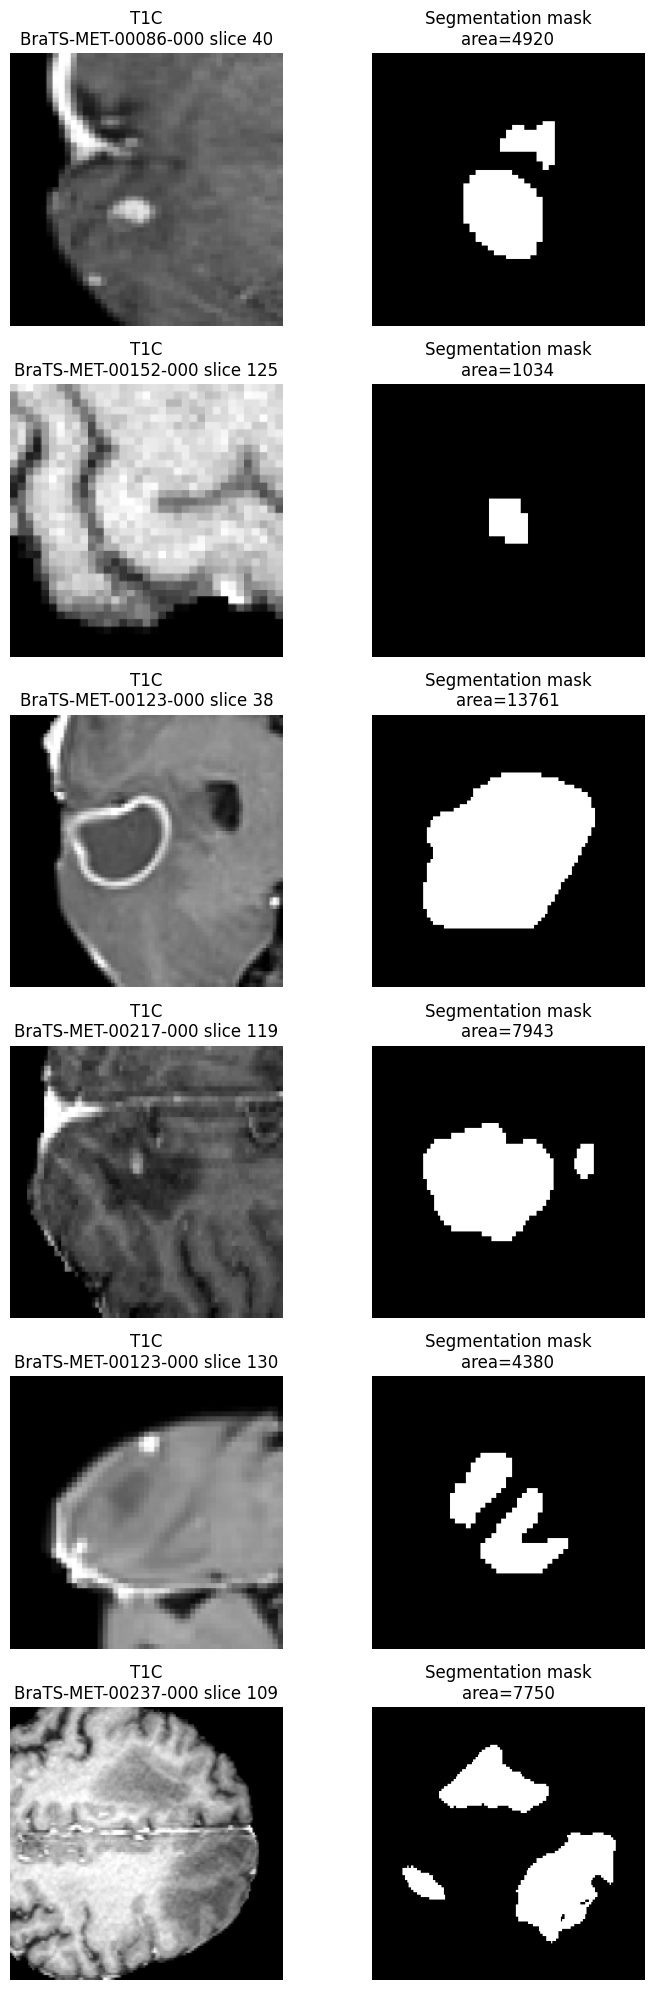


STEP 11 STATUS
✅ SEGMENTATION OUTPUT PASSED BASIC CHECKS


In [4]:
# =============================================================================
# MODEL 3A - STEP 11
# VERIFY BRAIN METASTASIS SEGMENTATION OUTPUT
# =============================================================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

print("=" * 80)
print("MODEL 3A - STEP 11")
print("VERIFYING BRAIN METASTASIS SEGMENTATION OUTPUT")
print("=" * 80)

BASE = "/content/model3a"

IMAGE_DIR = os.path.join(
    BASE,
    "segmented",
    "Brain_Metastasis",
    "images"
)

MASK_DIR = os.path.join(
    BASE,
    "segmented",
    "Brain_Metastasis",
    "masks"
)

MANIFEST = os.path.join(
    BASE,
    "manifests",
    "brain_metastasis_processed_manifest.csv"
)

# =============================================================================
# LOAD MANIFEST
# =============================================================================

df = pd.read_csv(MANIFEST)

print("\n" + "=" * 80)
print("1. MANIFEST")
print("=" * 80)

print("Images:", len(df))
print("Patients:", df["patient_id"].nunique())

# =============================================================================
# FILE CHECK
# =============================================================================

print("\n" + "=" * 80)
print("2. FILE CHECK")
print("=" * 80)

missing_images = []
missing_masks = []

for _, row in df.iterrows():

    if not os.path.exists(row["image_path"]):
        missing_images.append(row["image_path"])

    if not os.path.exists(row["mask_path"]):
        missing_masks.append(row["mask_path"])

print("Missing images:", len(missing_images))
print("Missing masks :", len(missing_masks))

# =============================================================================
# IMAGE SIZE CHECK
# =============================================================================

print("\n" + "=" * 80)
print("3. IMAGE / MASK DIMENSIONS")
print("=" * 80)

image_shapes = Counter()
mask_shapes = Counter()

sample_count = min(500, len(df))

sample_df = df.sample(
    sample_count,
    random_state=42
)

for _, row in sample_df.iterrows():

    image = cv2.imread(
        row["image_path"],
        cv2.IMREAD_GRAYSCALE
    )

    mask = cv2.imread(
        row["mask_path"],
        cv2.IMREAD_GRAYSCALE
    )

    if image is not None:
        image_shapes[image.shape] += 1

    if mask is not None:
        mask_shapes[mask.shape] += 1

print("\nImage shapes:")
for shape, count in image_shapes.items():
    print(shape, ":", count)

print("\nMask shapes:")
for shape, count in mask_shapes.items():
    print(shape, ":", count)

# =============================================================================
# MASK CHECK
# =============================================================================

print("\n" + "=" * 80)
print("4. MASK VALIDITY")
print("=" * 80)

empty_masks = 0
nonempty_masks = 0
mask_values = Counter()

for _, row in sample_df.iterrows():

    mask = cv2.imread(
        row["mask_path"],
        cv2.IMREAD_GRAYSCALE
    )

    if mask is None:
        continue

    unique = np.unique(mask)

    for value in unique:
        mask_values[int(value)] += 1

    if np.count_nonzero(mask) == 0:
        empty_masks += 1
    else:
        nonempty_masks += 1

print("Sample masks checked:", sample_count)
print("Non-empty masks:", nonempty_masks)
print("Empty masks:", empty_masks)

print("\nMask pixel values observed:")
print(sorted(mask_values.keys()))

# =============================================================================
# TUMOR AREA CHECK
# =============================================================================

df["mask_area_pixels"] = 0

for i, (_, row) in enumerate(df.iterrows()):

    mask = cv2.imread(
        row["mask_path"],
        cv2.IMREAD_GRAYSCALE
    )

    if mask is not None:
        df.loc[row.name, "mask_area_pixels"] = np.count_nonzero(mask)

print("\n" + "=" * 80)
print("5. TUMOR AREA")
print("=" * 80)

print(
    df["mask_area_pixels"].describe()
)

# =============================================================================
# PATIENT DISTRIBUTION
# =============================================================================

patient_counts = (
    df.groupby("patient_id")
      .size()
)

print("\n" + "=" * 80)
print("6. PATIENT SLICE DISTRIBUTION")
print("=" * 80)

print(
    patient_counts.describe()
)

print(
    "\nPatients:",
    len(patient_counts)
)

print(
    "Minimum slices:",
    patient_counts.min()
)

print(
    "Maximum slices:",
    patient_counts.max()
)

# =============================================================================
# VISUAL CHECK
# =============================================================================

print("\n" + "=" * 80)
print("7. VISUAL SAMPLE")
print("=" * 80)

visual_df = df.sample(
    min(6, len(df)),
    random_state=123
).reset_index(drop=True)

fig, axes = plt.subplots(
    6,
    2,
    figsize=(8, 20)
)

for i, row in visual_df.iterrows():

    image = cv2.imread(
        row["image_path"],
        cv2.IMREAD_GRAYSCALE
    )

    mask = cv2.imread(
        row["mask_path"],
        cv2.IMREAD_GRAYSCALE
    )

    axes[i, 0].imshow(
        image,
        cmap="gray"
    )

    axes[i, 0].set_title(
        f"T1C\n{row['patient_id']} "
        f"slice {row['slice_index']}"
    )

    axes[i, 0].axis("off")

    axes[i, 1].imshow(
        mask,
        cmap="gray"
    )

    axes[i, 1].set_title(
        f"Segmentation mask\n"
        f"area={row['mask_area_pixels']}"
    )

    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

# =============================================================================
# FINAL STATUS
# =============================================================================

print("\n" + "=" * 80)
print("STEP 11 STATUS")
print("=" * 80)

if (
    len(missing_images) == 0
    and
    len(missing_masks) == 0
    and
    empty_masks == 0
    and
    set(image_shapes.keys()) == {(224, 224)}
    and
    set(mask_shapes.keys()) == {(224, 224)}
):

    print("✅ SEGMENTATION OUTPUT PASSED BASIC CHECKS")

else:

    print("⚠️ REVIEW THE RESULTS ABOVE BEFORE CONTINUING")

print("=" * 80)

In [5]:
# =============================================================================
# MODEL 3A - STEP 12
# LOCATE + VALIDATE ALL 8 CLASS SOURCES
# COLAB ONLY
# =============================================================================

import os
import glob
import pandas as pd

print("=" * 80)
print("MODEL 3A - STEP 12")
print("LOCATING + VALIDATING ALL 8 CLASS SOURCES")
print("=" * 80)

BASE = "/content/model3a"

# =============================================================================
# REQUIRED CLASS ORDER
# =============================================================================

CLASS_MAP = {
    0: "No_Tumor",
    1: "Glioma",
    2: "Meningioma",
    3: "Pituitary",
    4: "Brain_Metastasis",
    5: "Schwannoma",
    6: "Meduloblastoma",
    7: "Ependymoma"
}

print("\nRequired classes:")

for idx, name in CLASS_MAP.items():
    print(f"{idx}: {name}")

# =============================================================================
# SOURCE LOCATIONS
# =============================================================================

SOURCES = {}

# -------------------------------------------------------------------------
# Existing 4-class MRI dataset
# -------------------------------------------------------------------------

SOURCES["No_Tumor"] = [
    os.path.join(
        BASE,
        "raw",
        "4class",
        "Training",
        "notumor"
    ),
    os.path.join(
        BASE,
        "raw",
        "4class",
        "Testing",
        "notumor"
    )
]

SOURCES["Glioma"] = [
    os.path.join(
        BASE,
        "raw",
        "4class",
        "Training",
        "glioma"
    ),
    os.path.join(
        BASE,
        "raw",
        "4class",
        "Testing",
        "glioma"
    )
]

SOURCES["Meningioma"] = [
    os.path.join(
        BASE,
        "raw",
        "4class",
        "Training",
        "meningioma"
    ),
    os.path.join(
        BASE,
        "raw",
        "4class",
        "Testing",
        "meningioma"
    )
]

SOURCES["Pituitary"] = [
    os.path.join(
        BASE,
        "raw",
        "4class",
        "Training",
        "pituitary"
    ),
    os.path.join(
        BASE,
        "raw",
        "4class",
        "Testing",
        "pituitary"
    )
]

# -------------------------------------------------------------------------
# 44-class dataset
# -------------------------------------------------------------------------

SOURCES["Schwannoma"] = [
    os.path.join(
        BASE,
        "raw",
        "44class",
        "Schwannoma T1"
    ),
    os.path.join(
        BASE,
        "raw",
        "44class",
        "Schwannoma T1C+"
    ),
    os.path.join(
        BASE,
        "raw",
        "44class",
        "Schwannoma T2"
    )
]

SOURCES["Meduloblastoma"] = [
    os.path.join(
        BASE,
        "raw",
        "44class",
        "Meduloblastoma T1"
    ),
    os.path.join(
        BASE,
        "raw",
        "44class",
        "Meduloblastoma T1C+"
    ),
    os.path.join(
        BASE,
        "raw",
        "44class",
        "Meduloblastoma T2"
    )
]

SOURCES["Ependymoma"] = [
    os.path.join(
        BASE,
        "raw",
        "44class",
        "Ependimoma T1"
    ),
    os.path.join(
        BASE,
        "raw",
        "44class",
        "Ependimoma T1C+"
    ),
    os.path.join(
        BASE,
        "raw",
        "44class",
        "Ependimoma T2"
    )
]

# -------------------------------------------------------------------------
# Brain Metastasis processed data
# -------------------------------------------------------------------------

SOURCES["Brain_Metastasis"] = [
    os.path.join(
        BASE,
        "segmented",
        "Brain_Metastasis",
        "images"
    )
]

# =============================================================================
# IMAGE EXTENSIONS
# =============================================================================

EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}

# =============================================================================
# SCAN
# =============================================================================

rows = []

print("\n" + "=" * 80)
print("SOURCE SCAN")
print("=" * 80)

for class_id, class_name in CLASS_MAP.items():

    print("\n" + "-" * 60)
    print(
        f"{class_id}: {class_name}"
    )
    print("-" * 60)

    total = 0
    existing_sources = 0

    for source in SOURCES[class_name]:

        if not os.path.isdir(source):

            print(
                "❌ NOT FOUND:",
                source
            )

            continue

        existing_sources += 1

        files = []

        for root, dirs, filenames in os.walk(source):

            for filename in filenames:

                ext = os.path.splitext(
                    filename
                )[1].lower()

                if ext in EXTENSIONS:

                    files.append(
                        os.path.join(
                            root,
                            filename
                        )
                    )

        print(
            f"{len(files):5d}  {source}"
        )

        total += len(files)

        for path in files:

            rows.append({

                "class_id":
                    class_id,

                "class_name":
                    class_name,

                "source":
                    source,

                "path":
                    path,

                "filename":
                    os.path.basename(path)
            })

    print(
        "TOTAL:",
        total
    )

    if total == 0:

        print(
            "❌ NO IMAGES FOUND"
        )

    else:

        print(
            "✅ SOURCE AVAILABLE"
        )

# =============================================================================
# MANIFEST
# =============================================================================

manifest = pd.DataFrame(
    rows
)

manifest_path = os.path.join(
    BASE,
    "manifests",
    "model3a_8class_source_manifest.csv"
)

os.makedirs(
    os.path.dirname(manifest_path),
    exist_ok=True
)

manifest.to_csv(
    manifest_path,
    index=False
)

# =============================================================================
# SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("FINAL SOURCE COUNTS")
print("=" * 80)

summary = (
    manifest
    .groupby(
        [
            "class_id",
            "class_name"
        ]
    )
    .size()
    .reset_index(
        name="image_count"
    )
)

print(
    summary.to_string(
        index=False
    )
)

# =============================================================================
# MISSING CLASSES
# =============================================================================

found_ids = set(
    summary["class_id"].tolist()
)

missing = [
    (idx, name)
    for idx, name in CLASS_MAP.items()
    if idx not in found_ids
]

print("\n" + "=" * 80)
print("MISSING CLASSES")
print("=" * 80)

if missing:

    for idx, name in missing:

        print(
            f"❌ {idx}: {name}"
        )

    raise RuntimeError(
        "One or more required classes have no images. "
        "DO NOT continue to dataset construction."
    )

else:

    print(
        "✅ ALL 8 CLASSES FOUND"
    )

# =============================================================================
# FINAL
# =============================================================================

print("\n" + "=" * 80)
print("CLASS ORDER")
print("=" * 80)

for idx, name in CLASS_MAP.items():

    count = int(
        summary.loc[
            summary["class_id"] == idx,
            "image_count"
        ].iloc[0]
    )

    print(
        f"{idx}: {name:<20} {count} images"
    )

print("\nManifest:")
print(manifest_path)

print("\n" + "=" * 80)
print("✅ STEP 12 COMPLETE")
print("=" * 80)

print("""
NO DATA WAS COPIED.

NO DATA WAS DELETED.

This step only validated that all 8 required classes
are actually available before we build the dataset.
""")

MODEL 3A - STEP 12
LOCATING + VALIDATING ALL 8 CLASS SOURCES

Required classes:
0: No_Tumor
1: Glioma
2: Meningioma
3: Pituitary
4: Brain_Metastasis
5: Schwannoma
6: Meduloblastoma
7: Ependymoma

SOURCE SCAN

------------------------------------------------------------
0: No_Tumor
------------------------------------------------------------
 1400  /content/model3a/raw/4class/Training/notumor
  400  /content/model3a/raw/4class/Testing/notumor
TOTAL: 1800
✅ SOURCE AVAILABLE

------------------------------------------------------------
1: Glioma
------------------------------------------------------------
 1400  /content/model3a/raw/4class/Training/glioma
  400  /content/model3a/raw/4class/Testing/glioma
TOTAL: 1800
✅ SOURCE AVAILABLE

------------------------------------------------------------
2: Meningioma
------------------------------------------------------------
 1400  /content/model3a/raw/4class/Training/meningioma
  400  /content/model3a/raw/4class/Testing/meningioma
TOTAL: 1800


In [6]:
# =============================================================================
# MODEL 3A - STEP 13
# CONTENT-HASH DUPLICATE AUDIT
# =============================================================================

import os
import hashlib
import pandas as pd
from tqdm.auto import tqdm

print("=" * 80)
print("MODEL 3A - STEP 13")
print("CONTENT-HASH DUPLICATE AUDIT")
print("=" * 80)

BASE = "/content/model3a"

SOURCE_MANIFEST = os.path.join(
    BASE,
    "manifests",
    "model3a_8class_source_manifest.csv"
)

AUDIT_DIR = os.path.join(
    BASE,
    "audit"
)

os.makedirs(
    AUDIT_DIR,
    exist_ok=True
)

# =============================================================================
# LOAD
# =============================================================================

df = pd.read_csv(
    SOURCE_MANIFEST
)

print(
    "\nImages to audit:",
    len(df)
)

# =============================================================================
# SHA256
# =============================================================================

def sha256_file(path, chunk_size=1024 * 1024):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(
                chunk_size
            )

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()

# =============================================================================
# HASH FILES
# =============================================================================

hashes = []

for path in tqdm(
    df["path"],
    desc="Hashing images"
):

    try:

        hashes.append(
            sha256_file(path)
        )

    except Exception as e:

        print(
            "\nERROR:",
            path,
            e
        )

        hashes.append(
            None
        )

df["sha256"] = hashes

# =============================================================================
# EXACT DUPLICATES
# =============================================================================

duplicate_mask = (
    df["sha256"].notna()
    &
    df["sha256"].duplicated(
        keep=False
    )
)

duplicates = df[
    duplicate_mask
].copy()

unique_images = (
    df["sha256"]
    .nunique(
        dropna=True
    )
)

total_images = len(df)

duplicate_rows = len(
    duplicates
)

duplicate_groups = (
    duplicates["sha256"]
    .nunique()
)

# =============================================================================
# SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("DUPLICATE SUMMARY")
print("=" * 80)

print(
    "Total files:",
    total_images
)

print(
    "Unique SHA256:",
    unique_images
)

print(
    "Duplicate rows:",
    duplicate_rows
)

print(
    "Duplicate groups:",
    duplicate_groups
)

# =============================================================================
# CROSS-CLASS DUPLICATES
# =============================================================================

cross_class = []

if len(duplicates) > 0:

    for sha, group in duplicates.groupby(
        "sha256"
    ):

        classes = group[
            "class_name"
        ].unique()

        if len(classes) > 1:

            cross_class.append({

                "sha256":
                    sha,

                "classes":
                    "|".join(
                        classes
                    ),

                "count":
                    len(group)
            })

cross_class_df = pd.DataFrame(
    cross_class
)

print("\n" + "=" * 80)
print("CROSS-CLASS DUPLICATES")
print("=" * 80)

print(
    "Cross-class duplicate groups:",
    len(cross_class_df)
)

if len(cross_class_df) > 0:

    print(
        cross_class_df.head(
            20
        ).to_string(
            index=False
        )
    )

# =============================================================================
# DUPLICATES BY CLASS
# =============================================================================

if len(duplicates) > 0:

    duplicate_by_class = (
        duplicates
        .groupby(
            "class_name"
        )
        .size()
        .reset_index(
            name="duplicate_file_count"
        )
    )

else:

    duplicate_by_class = pd.DataFrame(
        columns=[
            "class_name",
            "duplicate_file_count"
        ]
    )

print("\n" + "=" * 80)
print("DUPLICATES BY CLASS")
print("=" * 80)

print(
    duplicate_by_class.to_string(
        index=False
    )
)

# =============================================================================
# SAVE
# =============================================================================

full_hash_manifest = os.path.join(
    AUDIT_DIR,
    "model3a_8class_sha256_manifest.csv"
)

duplicate_manifest = os.path.join(
    AUDIT_DIR,
    "model3a_8class_duplicates.csv"
)

cross_class_manifest = os.path.join(
    AUDIT_DIR,
    "model3a_8class_cross_class_duplicates.csv"
)

df.to_csv(
    full_hash_manifest,
    index=False
)

duplicates.to_csv(
    duplicate_manifest,
    index=False
)

cross_class_df.to_csv(
    cross_class_manifest,
    index=False
)

print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)

print(
    full_hash_manifest
)

print(
    duplicate_manifest
)

print(
    cross_class_manifest
)

print("\n" + "=" * 80)
print("✅ STEP 13 COMPLETE")
print("=" * 80)

print("""
IMPORTANT:

No images were deleted.

No images were copied.

No dataset split was performed.

This step only identifies exact duplicate files.

NEXT:
STEP 14 → remove exact duplicates safely
          and prepare leakage-safe patient/image split.
""")

MODEL 3A - STEP 13
CONTENT-HASH DUPLICATE AUDIT

Images to audit: 17768


Hashing images:   0%|          | 0/17768 [00:00<?, ?it/s]


DUPLICATE SUMMARY
Total files: 17768
Unique SHA256: 17581
Duplicate rows: 340
Duplicate groups: 153

CROSS-CLASS DUPLICATES
Cross-class duplicate groups: 0

DUPLICATES BY CLASS
class_name  duplicate_file_count
    Glioma                    27
Meningioma                    31
  No_Tumor                   216
 Pituitary                    66

FILES SAVED
/content/model3a/audit/model3a_8class_sha256_manifest.csv
/content/model3a/audit/model3a_8class_duplicates.csv
/content/model3a/audit/model3a_8class_cross_class_duplicates.csv

✅ STEP 13 COMPLETE

IMPORTANT:

No images were deleted.

No images were copied.

No dataset split was performed.

This step only identifies exact duplicate files.

NEXT:
STEP 14 → remove exact duplicates safely
          and prepare leakage-safe patient/image split.



In [7]:
# =============================================================================
# MODEL 3A - STEP 14
# REMOVE EXACT DUPLICATES + BUILD CLEAN 8-CLASS POOL
# =============================================================================

import os
import pandas as pd

print("=" * 80)
print("MODEL 3A - STEP 14")
print("REMOVING EXACT DUPLICATES")
print("=" * 80)

BASE = "/content/model3a"

HASH_MANIFEST = os.path.join(
    BASE,
    "audit",
    "model3a_8class_sha256_manifest.csv"
)

OUTPUT_DIR = os.path.join(
    BASE,
    "manifests"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# =============================================================================
# LOAD HASH MANIFEST
# =============================================================================

df = pd.read_csv(
    HASH_MANIFEST
)

print("\nOriginal images:", len(df))

# =============================================================================
# REMOVE FILES WITH INVALID HASH
# =============================================================================

invalid_hash = df["sha256"].isna().sum()

print(
    "Invalid hashes:",
    invalid_hash
)

df = df[
    df["sha256"].notna()
].copy()

# =============================================================================
# REMOVE EXACT DUPLICATES
# =============================================================================
#
# Keep the first occurrence of every exact image.
#
# IMPORTANT:
# We are NOT deleting the physical raw image.
# We are only removing duplicate entries from our training pool.
# =============================================================================

before = len(df)

df_clean = df.drop_duplicates(
    subset=["sha256"],
    keep="first"
).copy()

removed = before - len(df_clean)

print(
    "Exact duplicate entries removed:",
    removed
)

print(
    "Clean pool:",
    len(df_clean)
)

# =============================================================================
# CLASS COUNTS
# =============================================================================

print("\n" + "=" * 80)
print("CLEAN CLASS COUNTS")
print("=" * 80)

class_counts = (
    df_clean
    .groupby(
        [
            "class_id",
            "class_name"
        ]
    )
    .size()
    .reset_index(
        name="image_count"
    )
    .sort_values(
        "class_id"
    )
)

print(
    class_counts.to_string(
        index=False
    )
)

# =============================================================================
# CHECK ALL 8 CLASSES
# =============================================================================

required_classes = {
    0: "No_Tumor",
    1: "Glioma",
    2: "Meningioma",
    3: "Pituitary",
    4: "Brain_Metastasis",
    5: "Schwannoma",
    6: "Meduloblastoma",
    7: "Ependymoma"
}

present_ids = set(
    df_clean["class_id"]
)

missing = [
    name
    for idx, name in required_classes.items()
    if idx not in present_ids
]

if missing:

    raise RuntimeError(
        f"Classes disappeared after deduplication: {missing}"
    )

print(
    "\n✅ All 8 classes remain."
)

# =============================================================================
# CHECK CROSS-CLASS DUPLICATES
# =============================================================================

hash_class_count = (
    df
    .groupby("sha256")["class_id"]
    .nunique()
)

cross_class_hashes = set(
    hash_class_count[
        hash_class_count > 1
    ].index
)

print(
    "\nCross-class exact duplicate hashes:",
    len(cross_class_hashes)
)

# If a hash occurs in multiple classes, keeping only the first occurrence
# could silently remove an entire class image. Report them explicitly.

if len(cross_class_hashes) > 0:

    print(
        "⚠️ Cross-class duplicates detected."
    )

    print(
        "They will NOT be automatically deleted from raw data."
    )

# =============================================================================
# SAVE CLEAN POOL
# =============================================================================

CLEAN_MANIFEST = os.path.join(
    OUTPUT_DIR,
    "model3a_8class_clean_pool_manifest.csv"
)

df_clean.to_csv(
    CLEAN_MANIFEST,
    index=False
)

# =============================================================================
# SAVE CLASS COUNTS
# =============================================================================

COUNT_MANIFEST = os.path.join(
    OUTPUT_DIR,
    "model3a_8class_clean_class_counts.csv"
)

class_counts.to_csv(
    COUNT_MANIFEST,
    index=False
)

# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("STEP 14 SUMMARY")
print("=" * 80)

print(
    "Original pool:",
    before
)

print(
    "Exact duplicates removed from pool:",
    removed
)

print(
    "Final clean pool:",
    len(df_clean)
)

print(
    "Classes:",
    df_clean["class_name"].nunique()
)

print(
    "\nClean manifest:"
)

print(
    CLEAN_MANIFEST
)

print(
    "\nClass counts:"
)

print(
    COUNT_MANIFEST
)

print("\n" + "=" * 80)
print("✅ STEP 14 COMPLETE")
print("=" * 80)

print("""
RAW DATA:
    untouched

PROCESSED METASTASIS DATA:
    untouched

WHAT CHANGED:
    Only the training-pool manifest was deduplicated.

NEXT:
STEP 15 → leakage-safe train / validation / test split
""")

MODEL 3A - STEP 14
REMOVING EXACT DUPLICATES

Original images: 17768
Invalid hashes: 0
Exact duplicate entries removed: 187
Clean pool: 17581

CLEAN CLASS COUNTS
 class_id       class_name  image_count
        0         No_Tumor         1681
        1           Glioma         1786
        2       Meningioma         1784
        3        Pituitary         1762
        4 Brain_Metastasis         9822
        5       Schwannoma          465
        6   Meduloblastoma          131
        7       Ependymoma          150

✅ All 8 classes remain.

Cross-class exact duplicate hashes: 0

STEP 14 SUMMARY
Original pool: 17768
Exact duplicates removed from pool: 187
Final clean pool: 17581
Classes: 8

Clean manifest:
/content/model3a/manifests/model3a_8class_clean_pool_manifest.csv

Class counts:
/content/model3a/manifests/model3a_8class_clean_class_counts.csv

✅ STEP 14 COMPLETE

RAW DATA:
    untouched

PROCESSED METASTASIS DATA:
    untouched

WHAT CHANGED:
    Only the training-pool manifest 

In [8]:
# =============================================================================
# MODEL 3A - STEP 15
# LEAKAGE-SAFE TRAIN / VALIDATION / TEST SPLIT
# =============================================================================

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

print("=" * 80)
print("MODEL 3A - STEP 15")
print("LEAKAGE-SAFE 8-CLASS DATASET SPLIT")
print("=" * 80)

BASE = "/content/model3a"

INPUT_MANIFEST = os.path.join(
    BASE,
    "manifests",
    "model3a_8class_clean_pool_manifest.csv"
)

OUTPUT_DIR = os.path.join(
    BASE,
    "manifests"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# =============================================================================
# SETTINGS
# =============================================================================

RANDOM_STATE = 42

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

CLASS_MAP = {
    0: "No_Tumor",
    1: "Glioma",
    2: "Meningioma",
    3: "Pituitary",
    4: "Brain_Metastasis",
    5: "Schwannoma",
    6: "Meduloblastoma",
    7: "Ependymoma"
}

# =============================================================================
# LOAD
# =============================================================================

df = pd.read_csv(
    INPUT_MANIFEST
)

print(
    "\nTotal clean images:",
    len(df)
)

# =============================================================================
# CHECK
# =============================================================================

if not np.isclose(
    TRAIN_RATIO + VAL_RATIO + TEST_RATIO,
    1.0
):

    raise ValueError(
        "Split ratios must sum to 1."
    )

# =============================================================================
# BRAIN METASTASIS
# PATIENT-LEVEL SPLIT
# =============================================================================

print("\n" + "=" * 80)
print("BRAIN METASTASIS — PATIENT-LEVEL SPLIT")
print("=" * 80)

met_df = df[
    df["class_name"] == "Brain_Metastasis"
].copy()

# Patient ID must exist
if "patient_id" not in met_df.columns:

    # It wasn't present in the generic source manifest.
    # Extract it from the processed filename.
    met_df["patient_id"] = (
        met_df["filename"]
        .str.extract(
            r"(BraTS-MET-\d+-\d+)"
        )[0]
    )

if met_df["patient_id"].isna().any():

    raise RuntimeError(
        "Could not determine patient IDs for metastasis images."
    )

patients = sorted(
    met_df["patient_id"].unique()
)

print(
    "Metastasis patients:",
    len(patients)
)

# -------------------------------------------------------------------------
# 70 / 15 / 15 patient split
# -------------------------------------------------------------------------

train_patients, temp_patients = train_test_split(
    patients,
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=RANDOM_STATE
)

relative_test = (
    TEST_RATIO /
    (VAL_RATIO + TEST_RATIO)
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=relative_test,
    random_state=RANDOM_STATE
)

train_patients = set(
    train_patients
)

val_patients = set(
    val_patients
)

test_patients = set(
    test_patients
)

print(
    "Train patients:",
    len(train_patients)
)

print(
    "Validation patients:",
    len(val_patients)
)

print(
    "Test patients:",
    len(test_patients)
)

# -------------------------------------------------------------------------
# Assign split
# -------------------------------------------------------------------------

met_df["split"] = "UNASSIGNED"

met_df.loc[
    met_df["patient_id"].isin(
        train_patients
    ),
    "split"
] = "train"

met_df.loc[
    met_df["patient_id"].isin(
        val_patients
    ),
    "split"
] = "validation"

met_df.loc[
    met_df["patient_id"].isin(
        test_patients
    ),
    "split"
] = "test"

# Verify
if (
    met_df["split"] == "UNASSIGNED"
).any():

    raise RuntimeError(
        "Some metastasis images were not assigned."
    )

# =============================================================================
# OTHER 7 CLASSES
# IMAGE-LEVEL STRATIFIED SPLIT
# =============================================================================

print("\n" + "=" * 80)
print("OTHER CLASSES — STRATIFIED SPLIT")
print("=" * 80)

other_df = df[
    df["class_name"] != "Brain_Metastasis"
].copy()

other_parts = []

for class_id, class_name in CLASS_MAP.items():

    if class_name == "Brain_Metastasis":
        continue

    class_df = other_df[
        other_df["class_name"] == class_name
    ].copy()

    print(
        f"\n{class_name}:",
        len(class_df)
    )

    # -------------------------------------------------------------
    # First: 70% train / 30% temporary
    # -------------------------------------------------------------

    train_part, temp_part = train_test_split(
        class_df,
        test_size=(
            VAL_RATIO + TEST_RATIO
        ),
        random_state=RANDOM_STATE,
        shuffle=True
    )

    # -------------------------------------------------------------
    # Second: split temporary into val/test
    # -------------------------------------------------------------

    relative_test = (
        TEST_RATIO /
        (VAL_RATIO + TEST_RATIO)
    )

    val_part, test_part = train_test_split(
        temp_part,
        test_size=relative_test,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    train_part = train_part.copy()
    val_part = val_part.copy()
    test_part = test_part.copy()

    train_part["split"] = "train"
    val_part["split"] = "validation"
    test_part["split"] = "test"

    other_parts.extend([
        train_part,
        val_part,
        test_part
    ])

# =============================================================================
# COMBINE
# =============================================================================

other_split_df = pd.concat(
    other_parts,
    ignore_index=True
)

met_df = met_df.reset_index(
    drop=True
)

final_df = pd.concat(
    [
        other_split_df,
        met_df
    ],
    ignore_index=True
)

# =============================================================================
# SHUFFLE
# =============================================================================

final_df = final_df.sample(
    frac=1.0,
    random_state=RANDOM_STATE
).reset_index(
    drop=True
)

# =============================================================================
# SPLIT COUNTS
# =============================================================================

print("\n" + "=" * 80)
print("FINAL SPLIT COUNTS")
print("=" * 80)

split_counts = (
    final_df
    .groupby(
        [
            "class_id",
            "class_name",
            "split"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

print(
    split_counts.to_string()
)

# =============================================================================
# PATIENT LEAKAGE CHECK
# =============================================================================

print("\n" + "=" * 80)
print("PATIENT LEAKAGE CHECK")
print("=" * 80)

train_met_patients = set(
    met_df.loc[
        met_df["split"] == "train",
        "patient_id"
    ]
)

val_met_patients = set(
    met_df.loc[
        met_df["split"] == "validation",
        "patient_id"
    ]
)

test_met_patients = set(
    met_df.loc[
        met_df["split"] == "test",
        "patient_id"
    ]
)

train_val_overlap = (
    train_met_patients &
    val_met_patients
)

train_test_overlap = (
    train_met_patients &
    test_met_patients
)

val_test_overlap = (
    val_met_patients &
    test_met_patients
)

print(
    "Train ∩ Validation:",
    len(train_val_overlap)
)

print(
    "Train ∩ Test:",
    len(train_test_overlap)
)

print(
    "Validation ∩ Test:",
    len(val_test_overlap)
)

if (
    len(train_val_overlap) > 0
    or
    len(train_test_overlap) > 0
    or
    len(val_test_overlap) > 0
):

    raise RuntimeError(
        "PATIENT LEAKAGE DETECTED."
    )

print(
    "✅ No metastasis patient leakage."
)

# =============================================================================
# IMAGE DUPLICATE CROSS-SPLIT CHECK
# =============================================================================

print("\n" + "=" * 80)
print("HASH LEAKAGE CHECK")
print("=" * 80)

hash_split_counts = (
    final_df
    .groupby("sha256")["split"]
    .nunique()
)

cross_split_hashes = (
    hash_split_counts[
        hash_split_counts > 1
    ]
)

print(
    "Hashes appearing in multiple splits:",
    len(cross_split_hashes)
)

if len(cross_split_hashes) > 0:

    raise RuntimeError(
        "Exact image duplicates exist across train/validation/test."
    )

print(
    "✅ No exact-image split leakage."
)

# =============================================================================
# SAVE
# =============================================================================

SPLIT_MANIFEST = os.path.join(
    OUTPUT_DIR,
    "model3a_8class_split_manifest.csv"
)

SPLIT_COUNTS = os.path.join(
    OUTPUT_DIR,
    "model3a_8class_split_counts.csv"
)

PATIENT_MANIFEST = os.path.join(
    OUTPUT_DIR,
    "model3a_brain_metastasis_patient_split.csv"
)

final_df.to_csv(
    SPLIT_MANIFEST,
    index=False
)

split_counts.to_csv(
    SPLIT_COUNTS
)

patient_rows = []

for patient in sorted(
    train_patients
):
    patient_rows.append({
        "patient_id": patient,
        "split": "train"
    })

for patient in sorted(
    val_patients
):
    patient_rows.append({
        "patient_id": patient,
        "split": "validation"
    })

for patient in sorted(
    test_patients
):
    patient_rows.append({
        "patient_id": patient,
        "split": "test"
    })

pd.DataFrame(
    patient_rows
).to_csv(
    PATIENT_MANIFEST,
    index=False
)

# =============================================================================
# FINAL
# =============================================================================

print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)

print(
    SPLIT_MANIFEST
)

print(
    SPLIT_COUNTS
)

print(
    PATIENT_MANIFEST
)

print("\n" + "=" * 80)
print("✅ STEP 15 COMPLETE")
print("=" * 80)

print("""
IMPORTANT:

No images were copied.

No raw data was modified.

Brain Metastasis:
    patient-level split

Other classes:
    deterministic stratified split

Exact duplicate leakage:
    checked

Next:
STEP 16 → controlled class balancing + final dataset construction
""")

MODEL 3A - STEP 15
LEAKAGE-SAFE 8-CLASS DATASET SPLIT

Total clean images: 17581

BRAIN METASTASIS — PATIENT-LEVEL SPLIT
Metastasis patients: 195
Train patients: 136
Validation patients: 29
Test patients: 30

OTHER CLASSES — STRATIFIED SPLIT

No_Tumor: 1681

Glioma: 1786

Meningioma: 1784

Pituitary: 1762

Schwannoma: 465

Meduloblastoma: 131

Ependymoma: 150

FINAL SPLIT COUNTS
split                      test  train  validation
class_id class_name                               
0        No_Tumor           253   1176         252
1        Glioma             268   1250         268
2        Meningioma         268   1248         268
3        Pituitary          265   1233         264
4        Brain_Metastasis  1472   6796        1554
5        Schwannoma          70    325          70
6        Meduloblastoma      20     91          20
7        Ependymoma          23    105          22

PATIENT LEAKAGE CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0
✅ No metastasis patient le

In [9]:
# =============================================================================
# MODEL 3A - STEP 16
# CONTROLLED TRAINING BALANCING
# =============================================================================

import os
import numpy as np
import pandas as pd

print("=" * 80)
print("MODEL 3A - STEP 16")
print("CONTROLLED 8-CLASS TRAINING BALANCING")
print("=" * 80)

BASE = "/content/model3a"

INPUT_MANIFEST = os.path.join(
    BASE,
    "manifests",
    "model3a_8class_split_manifest.csv"
)

OUTPUT_DIR = os.path.join(
    BASE,
    "manifests"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# =============================================================================
# SETTINGS
# =============================================================================

RANDOM_STATE = 42

TARGET_TRAIN_PER_CLASS = 1200

CLASS_MAP = {
    0: "No_Tumor",
    1: "Glioma",
    2: "Meningioma",
    3: "Pituitary",
    4: "Brain_Metastasis",
    5: "Schwannoma",
    6: "Meduloblastoma",
    7: "Ependymoma"
}

# =============================================================================
# LOAD SPLIT MANIFEST
# =============================================================================

df = pd.read_csv(
    INPUT_MANIFEST
)

train_df = df[
    df["split"] == "train"
].copy()

validation_df = df[
    df["split"] == "validation"
].copy()

test_df = df[
    df["split"] == "test"
].copy()

print("\nOriginal training distribution:")
print(
    train_df[
        "class_name"
    ].value_counts()
    .sort_index()
)

# =============================================================================
# BALANCE TRAINING ONLY
# =============================================================================

balanced_parts = []

print("\n" + "=" * 80)
print("TRAINING BALANCING")
print("=" * 80)

for class_id, class_name in CLASS_MAP.items():

    class_train = train_df[
        train_df["class_id"] == class_id
    ].copy()

    original_count = len(
        class_train
    )

    if original_count == 0:

        raise RuntimeError(
            f"No training images for {class_name}"
        )

    # -------------------------------------------------------------------------
    # If class has more than target:
    # downsample without replacement
    # -------------------------------------------------------------------------

    if original_count > TARGET_TRAIN_PER_CLASS:

        balanced = class_train.sample(
            n=TARGET_TRAIN_PER_CLASS,
            random_state=RANDOM_STATE
        )

        method = "downsample"

    # -------------------------------------------------------------------------
    # If class has fewer than target:
    # sample with replacement
    # -------------------------------------------------------------------------

    elif original_count < TARGET_TRAIN_PER_CLASS:

        balanced = class_train.sample(
            n=TARGET_TRAIN_PER_CLASS,
            replace=True,
            random_state=RANDOM_STATE
        )

        method = "oversample_manifest"

    else:

        balanced = class_train.copy()

        method = "unchanged"

    balanced = balanced.copy()

    balanced["balance_method"] = method

    balanced_parts.append(
        balanced
    )

    print(
        f"{class_name:<20}"
        f"original={original_count:<5}"
        f"target={TARGET_TRAIN_PER_CLASS:<5}"
        f"method={method}"
    )

# =============================================================================
# COMBINE
# =============================================================================

balanced_train = pd.concat(
    balanced_parts,
    ignore_index=True
)

balanced_train = balanced_train.sample(
    frac=1.0,
    random_state=RANDOM_STATE
).reset_index(
    drop=True
)

# =============================================================================
# IMPORTANT: DUPLICATE MANIFEST ENTRIES
# =============================================================================

duplicate_paths = (
    balanced_train["path"]
    .duplicated()
    .sum()
)

print("\n" + "=" * 80)
print("BALANCED TRAINING DATASET")
print("=" * 80)

print(
    "Training rows:",
    len(balanced_train)
)

print(
    "Unique physical images:",
    balanced_train["path"].nunique()
)

print(
    "Repeated manifest entries:",
    duplicate_paths
)

# =============================================================================
# DISTRIBUTION
# =============================================================================

train_counts = (
    balanced_train
    .groupby(
        [
            "class_id",
            "class_name"
        ]
    )
    .size()
    .reset_index(
        name="train_count"
    )
    .sort_values(
        "class_id"
    )
)

print("\nBalanced training distribution:")

print(
    train_counts.to_string(
        index=False
    )
)

# =============================================================================
# VALIDATION / TEST REMAIN UNTOUCHED
# =============================================================================

print("\n" + "=" * 80)
print("VALIDATION / TEST")
print("=" * 80)

print("\nValidation:")
print(
    validation_df[
        "class_name"
    ].value_counts()
    .sort_index()
)

print("\nTest:")
print(
    test_df[
        "class_name"
    ].value_counts()
    .sort_index()
)

# =============================================================================
# CHECK NO CROSS-SPLIT HASH LEAKAGE
# =============================================================================

print("\n" + "=" * 80)
print("LEAKAGE CHECK")
print("=" * 80)

# Unique physical training hashes
train_hashes = set(
    balanced_train["sha256"]
)

val_hashes = set(
    validation_df["sha256"]
)

test_hashes = set(
    test_df["sha256"]
)

train_val_overlap = (
    train_hashes &
    val_hashes
)

train_test_overlap = (
    train_hashes &
    test_hashes
)

val_test_overlap = (
    val_hashes &
    test_hashes
)

print(
    "Train ∩ Validation hashes:",
    len(train_val_overlap)
)

print(
    "Train ∩ Test hashes:",
    len(train_test_overlap)
)

print(
    "Validation ∩ Test hashes:",
    len(val_test_overlap)
)

if (
    train_val_overlap
    or
    train_test_overlap
    or
    val_test_overlap
):

    raise RuntimeError(
        "HASH LEAKAGE DETECTED."
    )

print(
    "✅ No exact-image leakage."
)

# =============================================================================
# SAVE
# =============================================================================

BALANCED_TRAIN_MANIFEST = os.path.join(
    OUTPUT_DIR,
    "model3a_8class_balanced_train_manifest.csv"
)

VALIDATION_MANIFEST = os.path.join(
    OUTPUT_DIR,
    "model3a_8class_validation_manifest.csv"
)

TEST_MANIFEST = os.path.join(
    OUTPUT_DIR,
    "model3a_8class_test_manifest.csv"
)

BALANCE_SUMMARY = os.path.join(
    OUTPUT_DIR,
    "model3a_8class_balance_summary.csv"
)

balanced_train.to_csv(
    BALANCED_TRAIN_MANIFEST,
    index=False
)

validation_df.to_csv(
    VALIDATION_MANIFEST,
    index=False
)

test_df.to_csv(
    TEST_MANIFEST,
    index=False
)

train_counts.to_csv(
    BALANCE_SUMMARY,
    index=False
)

# =============================================================================
# FINAL
# =============================================================================

print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)

print(
    "Balanced training:",
    BALANCED_TRAIN_MANIFEST
)

print(
    "Validation:",
    VALIDATION_MANIFEST
)

print(
    "Test:",
    TEST_MANIFEST
)

print(
    "Balance summary:",
    BALANCE_SUMMARY
)

print("\n" + "=" * 80)
print("✅ STEP 16 COMPLETE")
print("=" * 80)

print("""
TRAINING:
    1,200 samples/class

VALIDATION:
    untouched

TEST:
    untouched

RAW DATA:
    untouched

PHYSICAL IMAGES:
    not duplicated

Rare classes:
    manifest-level oversampling

Large classes:
    controlled downsampling

NEXT:
STEP 17 → create final train/validation/test directory structure
           with preprocessing + augmentation pipeline.
""")

MODEL 3A - STEP 16
CONTROLLED 8-CLASS TRAINING BALANCING

Original training distribution:
class_name
Brain_Metastasis    6796
Ependymoma           105
Glioma              1250
Meduloblastoma        91
Meningioma          1248
No_Tumor            1176
Pituitary           1233
Schwannoma           325
Name: count, dtype: int64

TRAINING BALANCING
No_Tumor            original=1176 target=1200 method=oversample_manifest
Glioma              original=1250 target=1200 method=downsample
Meningioma          original=1248 target=1200 method=downsample
Pituitary           original=1233 target=1200 method=downsample
Brain_Metastasis    original=6796 target=1200 method=downsample
Schwannoma          original=325  target=1200 method=oversample_manifest
Meduloblastoma      original=91   target=1200 method=oversample_manifest
Ependymoma          original=105  target=1200 method=oversample_manifest

BALANCED TRAINING DATASET
Training rows: 9600
Unique physical images: 6063
Repeated manifest entries: 35

In [10]:
# =============================================================================
# MODEL 3A - STEP 17
# MEMORY-SAFE 8-CLASS TENSORFLOW INPUT PIPELINE
# =============================================================================

import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

print("=" * 80)
print("MODEL 3A - STEP 17")
print("MEMORY-SAFE 8-CLASS TENSORFLOW INPUT PIPELINE")
print("=" * 80)

# =============================================================================
# SETTINGS
# =============================================================================

BASE = "/content/model3a"

MANIFEST_DIR = os.path.join(
    BASE,
    "manifests"
)

TRAIN_MANIFEST = os.path.join(
    MANIFEST_DIR,
    "model3a_8class_balanced_train_manifest.csv"
)

VAL_MANIFEST = os.path.join(
    MANIFEST_DIR,
    "model3a_8class_validation_manifest.csv"
)

TEST_MANIFEST = os.path.join(
    MANIFEST_DIR,
    "model3a_8class_test_manifest.csv"
)

IMG_SIZE = (224, 224)

NUM_CLASSES = 8

BATCH_SIZE = 32

SEED = 42

CLASS_NAMES = [
    "No_Tumor",
    "Glioma",
    "Meningioma",
    "Pituitary",
    "Brain_Metastasis",
    "Schwannoma",
    "Meduloblastoma",
    "Ependymoma"
]

# =============================================================================
# ENVIRONMENT
# =============================================================================

print("\nTensorFlow:", tf.__version__)

print(
    "GPU:",
    tf.config.list_physical_devices(
        "GPU"
    )
)

# Avoid TensorFlow aggressively reserving all GPU memory.
gpus = tf.config.list_physical_devices(
    "GPU"
)

for gpu in gpus:

    try:

        tf.config.experimental.set_memory_growth(
            gpu,
            True
        )

    except RuntimeError:
        pass

# =============================================================================
# LOAD MANIFESTS
# =============================================================================

train_df = pd.read_csv(
    TRAIN_MANIFEST
)

val_df = pd.read_csv(
    VAL_MANIFEST
)

test_df = pd.read_csv(
    TEST_MANIFEST
)

print("\n" + "=" * 80)
print("MANIFESTS")
print("=" * 80)

print(
    "Training rows:",
    len(train_df)
)

print(
    "Validation rows:",
    len(val_df)
)

print(
    "Test rows:",
    len(test_df)
)

# =============================================================================
# VERIFY CLASS ORDER
# =============================================================================

print("\n" + "=" * 80)
print("CLASS ORDER")
print("=" * 80)

for i, name in enumerate(
    CLASS_NAMES
):

    print(
        f"{i}: {name}"
    )

# =============================================================================
# VERIFY FILES
# =============================================================================

print("\n" + "=" * 80)
print("VERIFYING IMAGE PATHS")
print("=" * 80)

def verify_paths(df, name):

    missing = []

    for path in df["path"]:

        if not os.path.isfile(path):

            missing.append(path)

    print(
        f"{name}:",
        len(df),
        "rows"
    )

    print(
        f"{name} missing:",
        len(missing)
    )

    if missing:

        print(
            "\nFirst missing paths:"
        )

        for p in missing[:10]:

            print(
                p
            )

        raise FileNotFoundError(
            f"{name} contains missing image files."
        )

verify_paths(
    train_df,
    "TRAIN"
)

verify_paths(
    val_df,
    "VALIDATION"
)

verify_paths(
    test_df,
    "TEST"
)

print(
    "\n✅ All image paths exist."
)

# =============================================================================
# LABEL VERIFICATION
# =============================================================================

for df, name in [
    (train_df, "TRAIN"),
    (val_df, "VALIDATION"),
    (test_df, "TEST")
]:

    invalid_labels = df[
        ~df["class_id"].between(
            0,
            NUM_CLASSES - 1
        )
    ]

    if len(invalid_labels) > 0:

        raise ValueError(
            f"Invalid labels in {name}"
        )

print(
    "✅ All labels valid."
)

# =============================================================================
# IMAGE DECODER
# =============================================================================

def load_image(
    path,
    label
):

    image = tf.io.read_file(
        path
    )

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape(
        [None, None, 3]
    )

    image = tf.image.resize(
        image,
        IMG_SIZE,
        method=tf.image.ResizeMethod.BILINEAR
    )

    image = tf.cast(
        image,
        tf.float32
    )

    # Keep 0-255 representation.
    # EfficientNet preprocessing will be handled by the model.
    image = tf.ensure_shape(
        image,
        [
            IMG_SIZE[0],
            IMG_SIZE[1],
            3
        ]
    )

    label = tf.cast(
        label,
        tf.int32
    )

    return image, label

# =============================================================================
# TRAIN AUGMENTATION
# =============================================================================

train_augmentation = tf.keras.Sequential(
    [

        tf.keras.layers.RandomFlip(
            "horizontal"
        ),

        tf.keras.layers.RandomRotation(
            0.08
        ),

        tf.keras.layers.RandomZoom(
            0.10
        ),

        tf.keras.layers.RandomContrast(
            0.10
        )

    ],
    name="train_augmentation"
)

# =============================================================================
# DATASET CREATION
# =============================================================================

AUTOTUNE = tf.data.AUTOTUNE

def create_dataset(
    dataframe,
    training=False
):

    paths = dataframe[
        "path"
    ].astype(
        str
    ).values

    labels = dataframe[
        "class_id"
    ].astype(
        np.int32
    ).values

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            paths,
            labels
        )
    )

    if training:

        dataset = dataset.shuffle(
            buffer_size=min(
                len(dataframe),
                2000
            ),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    if training:

        dataset = dataset.map(
            lambda image, label: (
                train_augmentation(
                    image,
                    training=True
                ),
                label
            ),
            num_parallel_calls=AUTOTUNE
        )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

# =============================================================================
# CREATE DATASETS
# =============================================================================

print("\n" + "=" * 80)
print("CREATING DATASETS")
print("=" * 80)

train_ds = create_dataset(
    train_df,
    training=True
)

val_ds = create_dataset(
    val_df,
    training=False
)

test_ds = create_dataset(
    test_df,
    training=False
)

print(
    "✅ Training dataset created."
)

print(
    "✅ Validation dataset created."
)

print(
    "✅ Test dataset created."
)

# =============================================================================
# BATCH TEST
# =============================================================================

print("\n" + "=" * 80)
print("BATCH INSPECTION")
print("=" * 80)

train_images, train_labels = next(
    iter(train_ds)
)

print(
    "Training images:",
    train_images.shape
)

print(
    "Training labels:",
    train_labels.shape
)

print(
    "Image dtype:",
    train_images.dtype
)

print(
    "Image min:",
    float(
        tf.reduce_min(
            train_images
        )
    )
)

print(
    "Image max:",
    float(
        tf.reduce_max(
            train_images
        )
    )
)

print(
    "Image mean:",
    float(
        tf.reduce_mean(
            train_images
        )
    )
)

print(
    "Labels:",
    train_labels.numpy()
)

# =============================================================================
# VALIDATION BATCH
# =============================================================================

val_images, val_labels = next(
    iter(val_ds)
)

print("\nValidation batch:")
print(
    "Images:",
    val_images.shape
)

print(
    "Labels:",
    val_labels.shape
)

# =============================================================================
# TEST BATCH
# =============================================================================

test_images, test_labels = next(
    iter(test_ds)
)

print("\nTest batch:")
print(
    "Images:",
    test_images.shape
)

print(
    "Labels:",
    test_labels.shape
)

# =============================================================================
# LABEL DISTRIBUTION IN BALANCED TRAIN MANIFEST
# =============================================================================

print("\n" + "=" * 80)
print("TRAINING DISTRIBUTION")
print("=" * 80)

for class_id, class_name in enumerate(
    CLASS_NAMES
):

    count = int(
        (
            train_df["class_id"]
            == class_id
        ).sum()
    )

    print(
        f"{class_id}: {class_name:<20} {count}"
    )

# =============================================================================
# CLEAN TEMPORARY BATCHES
# =============================================================================

del train_images
del train_labels
del val_images
del val_labels
del test_images
del test_labels

gc.collect()

# =============================================================================
# FINAL
# =============================================================================

print("\n" + "=" * 80)
print("✅ STEP 17 COMPLETE")
print("=" * 80)

print("""
PIPELINE:

Training:
    balanced manifest
    + shuffle
    + augmentation
    + batch
    + prefetch

Validation:
    untouched
    + resize
    + batch
    + prefetch

Test:
    untouched
    + resize
    + batch
    + prefetch

Image size:
    224 × 224 × 3

Classes:
    8

No full dataset loaded into RAM.

No physical dataset duplication.

NEXT:
STEP 18 → model architecture + trainability sanity check.
""")

MODEL 3A - STEP 17
MEMORY-SAFE 8-CLASS TENSORFLOW INPUT PIPELINE

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

MANIFESTS
Training rows: 9600
Validation rows: 2718
Test rows: 2639

CLASS ORDER
0: No_Tumor
1: Glioma
2: Meningioma
3: Pituitary
4: Brain_Metastasis
5: Schwannoma
6: Meduloblastoma
7: Ependymoma

VERIFYING IMAGE PATHS
TRAIN: 9600 rows
TRAIN missing: 0
VALIDATION: 2718 rows
VALIDATION missing: 0
TEST: 2639 rows
TEST missing: 0

✅ All image paths exist.
✅ All labels valid.

CREATING DATASETS
✅ Training dataset created.
✅ Validation dataset created.
✅ Test dataset created.

BATCH INSPECTION
Training images: (32, 224, 224, 3)
Training labels: (32,)
Image dtype: <dtype: 'float32'>
Image min: 0.0
Image max: 255.0
Image mean: 56.382568359375
Labels: [7 7 5 4 0 3 5 1 2 4 6 4 6 5 5 6 3 7 0 7 3 2 6 0 0 1 5 0 4 7 7 7]

Validation batch:
Images: (32, 224, 224, 3)
Labels: (32,)

Test batch:
Images: (32, 224, 224, 3)
Labels: (32,)

TRAINING DI

In [11]:
# =============================================================================
# MODEL 3A - STEP 18
# 8-CLASS MODEL ARCHITECTURE + TRAINABILITY SANITY CHECK
# =============================================================================

import os
import gc
import numpy as np
import tensorflow as tf

print("=" * 80)
print("MODEL 3A - STEP 18")
print("8-CLASS MODEL ARCHITECTURE + TRAINABILITY SANITY CHECK")
print("=" * 80)

# =============================================================================
# SETTINGS
# =============================================================================

BASE = "/content/model3a"

MODEL_DIR = os.path.join(
    BASE,
    "models"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

IMG_SIZE = (
    224,
    224
)

NUM_CLASSES = 8

CLASS_NAMES = [
    "No_Tumor",
    "Glioma",
    "Meningioma",
    "Pituitary",
    "Brain_Metastasis",
    "Schwannoma",
    "Meduloblastoma",
    "Ependymoma"
]

SEED = 42

tf.random.set_seed(
    SEED
)

np.random.seed(
    SEED
)

# =============================================================================
# GPU
# =============================================================================

print("\n" + "=" * 80)
print("DEVICE")
print("=" * 80)

print(
    "GPU:",
    tf.config.list_physical_devices(
        "GPU"
    )
)

# =============================================================================
# CREATE BASE MODEL
# =============================================================================

print("\n" + "=" * 80)
print("BUILDING BACKBONE")
print("=" * 80)

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    )
)

# Freeze backbone initially.
base_model.trainable = False

print(
    "Backbone:",
    base_model.name
)

print(
    "Backbone trainable:",
    base_model.trainable
)

# =============================================================================
# CLASSIFIER
# =============================================================================

inputs = tf.keras.Input(
    shape=(
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    ),
    name="image"
)

# EfficientNetB0 contains its own input preprocessing.
x = base_model(
    inputs,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = tf.keras.layers.Dropout(
    0.30,
    name="dropout"
)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classifier"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="Model3A_EfficientNetB0_8Class"
)

# =============================================================================
# COMPILE
# =============================================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

# =============================================================================
# MODEL SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("MODEL")
print("=" * 80)

print(
    "Input:",
    model.input_shape
)

print(
    "Output:",
    model.output_shape
)

print(
    "Classes:",
    NUM_CLASSES
)

print(
    "Class names:",
    CLASS_NAMES
)

# =============================================================================
# PARAMETER COUNTS
# =============================================================================

total_params = model.count_params()

trainable_params = np.sum([
    np.prod(
        v.shape
    )
    for v in model.trainable_variables
])

non_trainable_params = np.sum([
    np.prod(
        v.shape
    )
    for v in model.non_trainable_variables
])

print("\n" + "=" * 80)
print("PARAMETERS")
print("=" * 80)

print(
    "Total parameters:",
    f"{total_params:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)

print(
    "Non-trainable parameters:",
    f"{non_trainable_params:,}"
)

# =============================================================================
# OUTPUT CHECK
# =============================================================================

print("\n" + "=" * 80)
print("OUTPUT CHECK")
print("=" * 80)

dummy_input = tf.random.uniform(
    (
        2,
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    ),
    minval=0,
    maxval=255,
    dtype=tf.float32
)

dummy_output = model(
    dummy_input,
    training=False
)

print(
    "Prediction shape:",
    dummy_output.shape
)

print(
    "Prediction sums:",
    tf.reduce_sum(
        dummy_output,
        axis=1
    ).numpy()
)

print(
    "Predicted classes:",
    tf.argmax(
        dummy_output,
        axis=1
    ).numpy()
)

# =============================================================================
# PROBABILITY CHECK
# =============================================================================

if dummy_output.shape[-1] != NUM_CLASSES:

    raise RuntimeError(
        "MODEL OUTPUT DOES NOT MATCH 8 CLASSES."
    )

if not np.allclose(
    tf.reduce_sum(
        dummy_output,
        axis=1
    ).numpy(),
    1.0,
    atol=1e-5
):

    raise RuntimeError(
        "SOFTMAX OUTPUT DOES NOT SUM TO 1."
    )

print(
    "✅ 8-class softmax output valid."
)

# =============================================================================
# TRAINABILITY CHECK
# =============================================================================

print("\n" + "=" * 80)
print("TRAINABILITY CHECK")
print("=" * 80)

# Use one real training batch from Step 17.
sample_images, sample_labels = next(
    iter(train_ds)
)

print(
    "Sample images:",
    sample_images.shape
)

print(
    "Sample labels:",
    sample_labels.shape
)

# -------------------------------------------------------------------------
# Forward + gradient
# -------------------------------------------------------------------------

with tf.GradientTape() as tape:

    predictions = model(
        sample_images,
        training=True
    )

    loss = tf.keras.losses.sparse_categorical_crossentropy(
        sample_labels,
        predictions
    )

    loss = tf.reduce_mean(
        loss
    )

trainable_variables = (
    model.trainable_variables
)

gradients = tape.gradient(
    loss,
    trainable_variables
)

valid_gradients = [
    g
    for g in gradients
    if g is not None
]

print(
    "Loss:",
    float(loss)
)

print(
    "Trainable variables:",
    len(trainable_variables)
)

print(
    "Variables with gradients:",
    len(valid_gradients)
)

if len(valid_gradients) == 0:

    raise RuntimeError(
        "NO VALID GRADIENTS FOUND."
    )

print(
    "✅ Gradient flow is working."
)

# =============================================================================
# ONE OPTIMIZER UPDATE TEST
# =============================================================================

print("\n" + "=" * 80)
print("OPTIMIZER UPDATE TEST")
print("=" * 80)

before_weights = [
    v.numpy().copy()
    for v in model.trainable_variables
]

optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3
)

optimizer.apply_gradients(
    zip(
        gradients,
        trainable_variables
    )
)

after_weights = [
    v.numpy()
    for v in model.trainable_variables
]

changed_variables = 0

for before, after in zip(
    before_weights,
    after_weights
):

    if not np.array_equal(
        before,
        after
    ):

        changed_variables += 1

print(
    "Trainable variables changed:",
    changed_variables
)

if changed_variables == 0:

    raise RuntimeError(
        "OPTIMIZER DID NOT UPDATE ANY VARIABLES."
    )

print(
    "✅ Optimizer update works."
)

# =============================================================================
# CLEANUP
# =============================================================================

del dummy_input
del dummy_output
del sample_images
del sample_labels
del predictions
del gradients
del before_weights
del after_weights

gc.collect()

# =============================================================================
# SAVE MODEL ARCHITECTURE
# =============================================================================

ARCHITECTURE_PATH = os.path.join(
    MODEL_DIR,
    "model3a_8class_efficientnetb0.keras"
)

# Save current sanity-tested model.
model.save(
    ARCHITECTURE_PATH
)

# =============================================================================
# FINAL
# =============================================================================

print("\n" + "=" * 80)
print("MODEL SAVED")
print("=" * 80)

print(
    ARCHITECTURE_PATH
)

print("\n" + "=" * 80)
print("✅ STEP 18 COMPLETE")
print("=" * 80)

print("""
MODEL:

Backbone:
    EfficientNetB0

Input:
    224 × 224 × 3

Output:
    8 classes

Classes:
    0 No_Tumor
    1 Glioma
    2 Meningioma
    3 Pituitary
    4 Brain_Metastasis
    5 Schwannoma
    6 Meduloblastoma
    7 Ependymoma

Initial training strategy:
    Frozen ImageNet backbone
    Train classifier head first

Full training:
    NOT STARTED

NEXT:
STEP 19 → short controlled training test
           before committing to full training.
""")

MODEL 3A - STEP 18
8-CLASS MODEL ARCHITECTURE + TRAINABILITY SANITY CHECK

DEVICE
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

BUILDING BACKBONE
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Backbone: efficientnetb0
Backbone trainable: False

MODEL
Input: (None, 224, 224, 3)
Output: (None, 8)
Classes: 8
Class names: ['No_Tumor', 'Glioma', 'Meningioma', 'Pituitary', 'Brain_Metastasis', 'Schwannoma', 'Meduloblastoma', 'Ependymoma']

PARAMETERS
Total parameters: 4,059,819
Trainable parameters: 10,248
Non-trainable parameters: 4,049,591.0

OUTPUT CHECK
Prediction shape: (2, 8)
Prediction sums: [1.0000001 1.0000001]
Predicted classes: [5 7]
✅ 8-class softmax output valid.

TRAINABILITY CHECK
Sample images: (32, 224, 224, 3)
Sample labels: (32,)
Loss: 2.188959836959839
Trainable variables: 2
Variables with gradients: 2
✅ Gradient flow is working.

OPTIMIZER UPDATE TEST
Trainable variables changed: 2
✅ Optimizer update works.

MODEL SAVED
/content/model3a/mode

In [12]:
# =============================================================================
# MODEL 3A - STEP 19
# SHORT CONTROLLED 8-CLASS TRAINING TEST
# =============================================================================

import os
import gc
import numpy as np
import tensorflow as tf

print("=" * 80)
print("MODEL 3A - STEP 19")
print("SHORT CONTROLLED 8-CLASS TRAINING TEST")
print("=" * 80)

# =============================================================================
# SETTINGS
# =============================================================================

BASE = "/content/model3a"

MODEL_DIR = os.path.join(
    BASE,
    "models"
)

CHECKPOINT_DIR = os.path.join(
    MODEL_DIR,
    "checkpoints"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

NUM_CLASSES = 8

IMG_SIZE = (
    224,
    224
)

CLASS_NAMES = [
    "No_Tumor",
    "Glioma",
    "Meningioma",
    "Pituitary",
    "Brain_Metastasis",
    "Schwannoma",
    "Meduloblastoma",
    "Ependymoma"
]

SEED = 42

EPOCHS = 3

LEARNING_RATE = 1e-3

tf.random.set_seed(
    SEED
)

np.random.seed(
    SEED
)

# =============================================================================
# REBUILD CLEAN MODEL
# =============================================================================

print("\n" + "=" * 80)
print("BUILDING CLEAN MODEL")
print("=" * 80)

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    )
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=(
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    ),
    name="image"
)

x = base_model(
    inputs,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = tf.keras.layers.Dropout(
    0.30,
    name="dropout"
)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classifier"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="Model3A_EfficientNetB0_8Class"
)

# =============================================================================
# COMPILE
# =============================================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print(
    "Backbone trainable:",
    base_model.trainable
)

print(
    "Trainable parameters:",
    f"{model.count_params() - sum(np.prod(v.shape) for v in model.non_trainable_variables):,}"
)

# =============================================================================
# CALLBACKS
# =============================================================================

CHECKPOINT_PATH = os.path.join(
    CHECKPOINT_DIR,
    "model3a_step19_best.keras"
)

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )

]

# =============================================================================
# INITIAL PREDICTION CHECK
# =============================================================================

print("\n" + "=" * 80)
print("INITIAL PREDICTION CHECK")
print("=" * 80)

sample_images, sample_labels = next(
    iter(train_ds)
)

initial_predictions = model.predict(
    sample_images,
    verbose=0
)

print(
    "Prediction shape:",
    initial_predictions.shape
)

print(
    "Initial predicted classes:",
    np.argmax(
        initial_predictions,
        axis=1
    )
)

print(
    "Actual classes:",
    sample_labels.numpy()
)

# =============================================================================
# SHORT TRAINING
# =============================================================================

print("\n" + "=" * 80)
print("STARTING 3-EPOCH CONTROLLED TRAINING")
print("=" * 80)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# =============================================================================
# HISTORY
# =============================================================================

print("\n" + "=" * 80)
print("STEP 19 TRAINING RESULTS")
print("=" * 80)

for epoch in range(
    len(
        history.history["loss"]
    )
):

    train_acc = history.history[
        "accuracy"
    ][epoch]

    val_acc = history.history[
        "val_accuracy"
    ][epoch]

    train_loss = history.history[
        "loss"
    ][epoch]

    val_loss = history.history[
        "val_loss"
    ][epoch]

    print(
        f"Epoch {epoch + 1}: "
        f"train_acc={train_acc:.4f} "
        f"val_acc={val_acc:.4f} "
        f"train_loss={train_loss:.4f} "
        f"val_loss={val_loss:.4f}"
    )

# =============================================================================
# BEST VALIDATION
# =============================================================================

best_val_acc = max(
    history.history[
        "val_accuracy"
    ]
)

best_epoch = (
    np.argmax(
        history.history[
            "val_accuracy"
        ]
    ) + 1
)

print("\n" + "=" * 80)
print("BEST RESULT")
print("=" * 80)

print(
    f"Best validation accuracy: "
    f"{best_val_acc * 100:.2f}%"
)

print(
    f"Best epoch: {best_epoch}"
)

# =============================================================================
# LOAD BEST CHECKPOINT
# =============================================================================

print("\n" + "=" * 80)
print("LOADING BEST CHECKPOINT")
print("=" * 80)

if os.path.exists(
    CHECKPOINT_PATH
):

    model = tf.keras.models.load_model(
        CHECKPOINT_PATH
    )

    print(
        "✅ Best Step 19 checkpoint loaded."
    )

else:

    raise FileNotFoundError(
        "Step 19 checkpoint was not created."
    )

# =============================================================================
# CLEANUP
# =============================================================================

del sample_images
del sample_labels
del initial_predictions

gc.collect()

# =============================================================================
# FINAL
# =============================================================================

print("\n" + "=" * 80)
print("✅ STEP 19 COMPLETE")
print("=" * 80)

print(
    "Best checkpoint:"
)

print(
    CHECKPOINT_PATH
)

print("""
BACKBONE:
    EfficientNetB0
    Frozen

TRAINING:
    3 epochs
    LR = 1e-3

THIS WAS ONLY A CONTROLLED TEST.

DO NOT START FINE-TUNING YET.

NEXT:
    Evaluate the Step 19 checkpoint per class.
""")

MODEL 3A - STEP 19
SHORT CONTROLLED 8-CLASS TRAINING TEST

BUILDING CLEAN MODEL
Backbone trainable: False
Trainable parameters: 10,228.0

INITIAL PREDICTION CHECK
Prediction shape: (32, 8)
Initial predicted classes: [0 4 5 6 4 7 5 4 4 4 0 1 4 4 4 6 7 4 1 5 1 6 0 0 1 4 7 3 4 1 0 0]
Actual classes: [1 5 5 6 4 3 5 6 2 3 3 0 0 3 5 2 3 7 1 7 5 4 0 1 1 0 6 6 6 4 0 1]

STARTING 3-EPOCH CONTROLLED TRAINING
Epoch 1/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.5815 - loss: 1.1810
Epoch 1: val_accuracy improved from None to 0.90361, saving model to /content/model3a/models/checkpoints/model3a_step19_best.keras

Epoch 1: finished saving model to /content/model3a/models/checkpoints/model3a_step19_best.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 158s 454ms/step - accuracy: 0.7032 - loss: 0.8813 - val_accuracy: 0.9036 - val_loss: 0.3040 - learning_rate: 0.0010
Epoch 2/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.8247 - loss: 0.5600
Epoch 2: val_accuracy did not improve from 0.90361


In [13]:
# =============================================================================
# MODEL 3A - STEP 20
# PER-CLASS VALIDATION EVALUATION
# =============================================================================

import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("=" * 80)
print("MODEL 3A - STEP 20")
print("PER-CLASS VALIDATION EVALUATION")
print("=" * 80)

# =============================================================================
# SETTINGS
# =============================================================================

BASE = "/content/model3a"

MODEL_PATH = os.path.join(
    BASE,
    "models",
    "checkpoints",
    "model3a_step19_best.keras"
)

EVAL_DIR = os.path.join(
    BASE,
    "evaluation"
)

os.makedirs(
    EVAL_DIR,
    exist_ok=True
)

CLASS_NAMES = [
    "No_Tumor",
    "Glioma",
    "Meningioma",
    "Pituitary",
    "Brain_Metastasis",
    "Schwannoma",
    "Meduloblastoma",
    "Ependymoma"
]

NUM_CLASSES = 8

# =============================================================================
# LOAD MODEL
# =============================================================================

print("\n" + "=" * 80)
print("LOADING MODEL")
print("=" * 80)

if not os.path.exists(
    MODEL_PATH
):

    raise FileNotFoundError(
        MODEL_PATH
    )

model = tf.keras.models.load_model(
    MODEL_PATH
)

print(
    "Model:",
    MODEL_PATH
)

print(
    "Input:",
    model.input_shape
)

print(
    "Output:",
    model.output_shape
)

# =============================================================================
# VALIDATION MANIFEST
# =============================================================================

VAL_MANIFEST = os.path.join(
    BASE,
    "manifests",
    "model3a_8class_validation_manifest.csv"
)

val_df = pd.read_csv(
    VAL_MANIFEST
)

print("\n" + "=" * 80)
print("VALIDATION SET")
print("=" * 80)

print(
    "Validation images:",
    len(val_df)
)

print("\nTrue distribution:")

print(
    val_df[
        "class_name"
    ]
    .value_counts()
    .reindex(
        CLASS_NAMES,
        fill_value=0
    )
)

# =============================================================================
# GENERATE PREDICTIONS
# =============================================================================

print("\n" + "=" * 80)
print("GENERATING VALIDATION PREDICTIONS")
print("=" * 80)

# Use the existing memory-safe validation dataset.
# It was created in Step 17 and contains no augmentation.

y_true = []
y_pred = []
y_prob = []

for images, labels in val_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        np.argmax(
            predictions,
            axis=1
        )
    )

    y_prob.extend(
        predictions
    )

y_true = np.asarray(
    y_true,
    dtype=np.int32
)

y_pred = np.asarray(
    y_pred,
    dtype=np.int32
)

y_prob = np.asarray(
    y_prob,
    dtype=np.float32
)

print(
    "Predictions generated:",
    len(y_pred)
)

# =============================================================================
# SAFETY CHECK
# =============================================================================

if len(y_true) != len(val_df):

    raise RuntimeError(
        f"Prediction count mismatch: "
        f"{len(y_true)} vs {len(val_df)}"
    )

if len(y_pred) != len(val_df):

    raise RuntimeError(
        "Prediction count mismatch."
    )

print(
    "✅ Prediction count matches validation set."
)

# =============================================================================
# OVERALL METRICS
# =============================================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision_macro, recall_macro, f1_macro, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=np.arange(
            NUM_CLASSES
        ),
        average="macro",
        zero_division=0
    )
)

precision_weighted, recall_weighted, f1_weighted, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=np.arange(
            NUM_CLASSES
        ),
        average="weighted",
        zero_division=0
    )
)

print("\n" + "=" * 80)
print("OVERALL VALIDATION RESULTS")
print("=" * 80)

print(
    f"Accuracy           : {accuracy:.4f} "
    f"({accuracy * 100:.2f}%)"
)

print(
    f"Macro Precision    : {precision_macro:.4f}"
)

print(
    f"Macro Recall       : {recall_macro:.4f}"
)

print(
    f"Macro F1           : {f1_macro:.4f}"
)

print(
    f"Weighted Precision : {precision_weighted:.4f}"
)

print(
    f"Weighted Recall    : {recall_weighted:.4f}"
)

print(
    f"Weighted F1        : {f1_weighted:.4f}"
)

# =============================================================================
# CLASSIFICATION REPORT
# =============================================================================

print("\n" + "=" * 80)
print("PER-CLASS CLASSIFICATION REPORT")
print("=" * 80)

report_dict = classification_report(
    y_true,
    y_pred,
    labels=np.arange(
        NUM_CLASSES
    ),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose()

print(
    report_df.to_string()
)

# =============================================================================
# CONFUSION MATRIX
# =============================================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(
        NUM_CLASSES
    )
)

cm_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

print(
    cm_df.to_string()
)

# =============================================================================
# PER-CLASS PERFORMANCE
# =============================================================================

print("\n" + "=" * 80)
print("PER-CLASS PERFORMANCE")
print("=" * 80)

performance_rows = []

for class_id, class_name in enumerate(
    CLASS_NAMES
):

    total = int(
        np.sum(
            y_true == class_id
        )
    )

    correct = int(
        np.sum(
            (y_true == class_id)
            &
            (y_pred == class_id)
        )
    )

    incorrect = (
        total - correct
    )

    class_accuracy = (
        correct / total
        if total > 0
        else 0
    )

    precision = report_dict[
        class_name
    ]["precision"]

    recall = report_dict[
        class_name
    ]["recall"]

    f1 = report_dict[
        class_name
    ]["f1-score"]

    performance_rows.append({

        "class_id":
            class_id,

        "class":
            class_name,

        "total_images":
            total,

        "correct":
            correct,

        "incorrect":
            incorrect,

        "accuracy":
            class_accuracy,

        "precision":
            precision,

        "recall":
            recall,

        "f1":
            f1
    })

performance_df = pd.DataFrame(
    performance_rows
)

print(
    performance_df.to_string(
        index=False
    )
)

# =============================================================================
# PREDICTION DISTRIBUTION
# =============================================================================

prediction_counts = np.bincount(
    y_pred,
    minlength=NUM_CLASSES
)

prediction_distribution = pd.DataFrame({

    "class_id":
        np.arange(
            NUM_CLASSES
        ),

    "class_name":
        CLASS_NAMES,

    "predicted_count":
        prediction_counts
})

print("\n" + "=" * 80)
print("PREDICTION DISTRIBUTION")
print("=" * 80)

print(
    prediction_distribution.to_string(
        index=False
    )
)

# =============================================================================
# CONFIDENCE
# =============================================================================

confidence = np.max(
    y_prob,
    axis=1
)

print("\n" + "=" * 80)
print("PREDICTION CONFIDENCE")
print("=" * 80)

print(
    f"Mean confidence   : {np.mean(confidence):.4f}"
)

print(
    f"Median confidence : {np.median(confidence):.4f}"
)

print(
    f"Minimum confidence: {np.min(confidence):.4f}"
)

print(
    f"Maximum confidence: {np.max(confidence):.4f}"
)

# =============================================================================
# SAVE PREDICTIONS
# =============================================================================

prediction_df = val_df.copy()

prediction_df[
    "true_class_id"
] = y_true

prediction_df[
    "true_class"
] = [
    CLASS_NAMES[x]
    for x in y_true
]

prediction_df[
    "predicted_class_id"
] = y_pred

prediction_df[
    "predicted_class"
] = [
    CLASS_NAMES[x]
    for x in y_pred
]

prediction_df[
    "confidence"
] = confidence

prediction_df[
    "correct"
] = (
    y_true == y_pred
)

# =============================================================================
# SAVE FILES
# =============================================================================

REPORT_PATH = os.path.join(
    EVAL_DIR,
    "model3a_step20_classification_report.csv"
)

CONFUSION_PATH = os.path.join(
    EVAL_DIR,
    "model3a_step20_confusion_matrix.csv"
)

PERFORMANCE_PATH = os.path.join(
    EVAL_DIR,
    "model3a_step20_per_class_performance.csv"
)

PREDICTIONS_PATH = os.path.join(
    EVAL_DIR,
    "model3a_step20_validation_predictions.csv"
)

SUMMARY_PATH = os.path.join(
    EVAL_DIR,
    "model3a_step20_metrics.csv"
)

report_df.to_csv(
    REPORT_PATH
)

cm_df.to_csv(
    CONFUSION_PATH
)

performance_df.to_csv(
    PERFORMANCE_PATH,
    index=False
)

prediction_df.to_csv(
    PREDICTIONS_PATH,
    index=False
)

pd.DataFrame([{

    "accuracy":
        accuracy,

    "macro_precision":
        precision_macro,

    "macro_recall":
        recall_macro,

    "macro_f1":
        f1_macro,

    "weighted_precision":
        precision_weighted,

    "weighted_recall":
        recall_weighted,

    "weighted_f1":
        f1_weighted,

    "mean_confidence":
        np.mean(confidence)

}]).to_csv(
    SUMMARY_PATH,
    index=False
)

# =============================================================================
# FINAL
# =============================================================================

del y_prob
del confidence

gc.collect()

print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)

print(
    REPORT_PATH
)

print(
    CONFUSION_PATH
)

print(
    PERFORMANCE_PATH
)

print(
    PREDICTIONS_PATH
)

print(
    SUMMARY_PATH
)

print("\n" + "=" * 80)
print("✅ STEP 20 COMPLETE")
print("=" * 80)

print("""
IMPORTANT:

This is validation evaluation only.

The TEST SET has NOT been touched.

The Step 19 checkpoint remains unchanged.

NEXT:
We will decide whether to:
    A) proceed to full frozen-backbone training
or
    B) adjust the strategy before training.
""")

MODEL 3A - STEP 20
PER-CLASS VALIDATION EVALUATION

LOADING MODEL
Model: /content/model3a/models/checkpoints/model3a_step19_best.keras
Input: (None, 224, 224, 3)
Output: (None, 8)

VALIDATION SET
Validation images: 2718

True distribution:
class_name
No_Tumor             252
Glioma               268
Meningioma           268
Pituitary            264
Brain_Metastasis    1554
Schwannoma            70
Meduloblastoma        20
Ependymoma            22
Name: count, dtype: int64

GENERATING VALIDATION PREDICTIONS
Predictions generated: 2718
✅ Prediction count matches validation set.

OVERALL VALIDATION RESULTS
Accuracy           : 0.9238 (92.38%)
Macro Precision    : 0.8193
Macro Recall       : 0.8437
Macro F1           : 0.8243
Weighted Precision : 0.9306
Weighted Recall    : 0.9238
Weighted F1        : 0.9228

PER-CLASS CLASSIFICATION REPORT
                  precision    recall  f1-score      support
No_Tumor           0.939759  0.928571  0.934132   252.000000
Glioma             0.964824  

In [14]:
# =============================================================================
# MODEL 3A - STEP 21
# PROPER FROZEN-BACKBONE TRAINING
# =============================================================================

import os
import gc
import json
import numpy as np
import pandas as pd
import tensorflow as tf

print("=" * 80)
print("MODEL 3A - STEP 21")
print("PROPER FROZEN-BACKBONE TRAINING")
print("=" * 80)

# =============================================================================
# SETTINGS
# =============================================================================

BASE = "/content/model3a"

MODEL_DIR = os.path.join(
    BASE,
    "models"
)

CHECKPOINT_DIR = os.path.join(
    MODEL_DIR,
    "checkpoints"
)

HISTORY_DIR = os.path.join(
    BASE,
    "training_history"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

os.makedirs(
    HISTORY_DIR,
    exist_ok=True
)

CLASS_NAMES = [
    "No_Tumor",
    "Glioma",
    "Meningioma",
    "Pituitary",
    "Brain_Metastasis",
    "Schwannoma",
    "Meduloblastoma",
    "Ependymoma"
]

NUM_CLASSES = 8

EPOCHS = 15

LEARNING_RATE = 1e-3

SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# =============================================================================
# GPU
# =============================================================================

print("\n" + "=" * 80)
print("DEVICE")
print("=" * 80)

gpus = tf.config.list_physical_devices(
    "GPU"
)

print(
    "GPU:",
    gpus
)

# =============================================================================
# LOAD STEP 19 BEST MODEL
# =============================================================================

STEP19_MODEL = os.path.join(
    CHECKPOINT_DIR,
    "model3a_step19_best.keras"
)

if not os.path.exists(
    STEP19_MODEL
):

    raise FileNotFoundError(
        f"Step 19 checkpoint not found:\n{STEP19_MODEL}"
    )

print("\n" + "=" * 80)
print("LOADING STEP 19 CHECKPOINT")
print("=" * 80)

model = tf.keras.models.load_model(
    STEP19_MODEL
)

print(
    "Loaded:",
    STEP19_MODEL
)

print(
    "Input shape:",
    model.input_shape
)

print(
    "Output shape:",
    model.output_shape
)

# =============================================================================
# VERIFY BACKBONE IS FROZEN
# =============================================================================

print("\n" + "=" * 80)
print("BACKBONE TRAINABILITY")
print("=" * 80)

backbone = None

for layer in model.layers:

    if isinstance(
        layer,
        tf.keras.Model
    ):

        backbone = layer
        break

if backbone is None:

    raise RuntimeError(
        "Could not identify EfficientNet backbone."
    )

backbone.trainable = False

print(
    "Backbone:",
    backbone.name
)

print(
    "Backbone trainable:",
    backbone.trainable
)

# =============================================================================
# RECOMPILE
# =============================================================================

print("\n" + "=" * 80)
print("COMPILING")
print("=" * 80)

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print(
    "Optimizer: Adam"
)

print(
    "Learning rate:",
    LEARNING_RATE
)

# =============================================================================
# CHECK TRAINING PIPELINE
# =============================================================================

print("\n" + "=" * 80)
print("PIPELINE CHECK")
print("=" * 80)

print(
    "Training batches:",
    tf.data.experimental.cardinality(
        train_ds
    ).numpy()
)

print(
    "Validation batches:",
    tf.data.experimental.cardinality(
        val_ds
    ).numpy()
)

# =============================================================================
# CHECKPOINT
# =============================================================================

BEST_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "model3a_step21_best_frozen.keras"
)

LAST_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "model3a_step21_last_frozen.keras"
)

# =============================================================================
# CALLBACKS
# =============================================================================

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(

        BEST_MODEL_PATH,

        monitor="val_accuracy",

        mode="max",

        save_best_only=True,

        save_weights_only=False,

        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(

        monitor="val_accuracy",

        mode="max",

        patience=4,

        min_delta=0.002,

        restore_best_weights=True,

        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        mode="min",

        factor=0.5,

        patience=2,

        min_lr=1e-6,

        verbose=1
    )
]

# =============================================================================
# TRAINING
# =============================================================================

print("\n" + "=" * 80)
print("STARTING PROPER FROZEN-BACKBONE TRAINING")
print("=" * 80)

print(
    f"Maximum epochs: {EPOCHS}"
)

print(
    f"Learning rate: {LEARNING_RATE}"
)

print(
    "Early stopping patience: 4"
)

print(
    "Test set: NOT USED"
)

print("=" * 80)

history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=callbacks,

    verbose=1
)

# =============================================================================
# SAVE LAST MODEL
# =============================================================================

print("\n" + "=" * 80)
print("SAVING LAST MODEL")
print("=" * 80)

model.save(
    LAST_MODEL_PATH
)

print(
    "Last model saved:"
)

print(
    LAST_MODEL_PATH
)

# =============================================================================
# HISTORY DATAFRAME
# =============================================================================

history_df = pd.DataFrame(
    history.history
)

history_df.insert(
    0,
    "epoch",
    np.arange(
        1,
        len(history_df) + 1
    )
)

HISTORY_CSV = os.path.join(
    HISTORY_DIR,
    "model3a_step21_frozen_training_history.csv"
)

history_df.to_csv(
    HISTORY_CSV,
    index=False
)

# =============================================================================
# BEST EPOCH
# =============================================================================

best_epoch_index = int(
    np.argmax(
        history.history[
            "val_accuracy"
        ]
    )
)

best_epoch = (
    best_epoch_index + 1
)

best_val_accuracy = (
    history.history[
        "val_accuracy"
    ][best_epoch_index]
)

best_val_loss = (
    history.history[
        "val_loss"
    ][best_epoch_index]
)

best_train_accuracy = (
    history.history[
        "accuracy"
    ][best_epoch_index]
)

best_train_loss = (
    history.history[
        "loss"
    ][best_epoch_index]
)

# =============================================================================
# PRINT RESULTS
# =============================================================================

print("\n" + "=" * 80)
print("STEP 21 RESULTS")
print("=" * 80)

for i in range(
    len(
        history_df
    )
):

    print(
        f"Epoch {i + 1}: "
        f"train_acc="
        f"{history.history['accuracy'][i]:.4f} "
        f"val_acc="
        f"{history.history['val_accuracy'][i]:.4f} "
        f"train_loss="
        f"{history.history['loss'][i]:.4f} "
        f"val_loss="
        f"{history.history['val_loss'][i]:.4f}"
    )

print("\n" + "=" * 80)
print("BEST FROZEN-BACKBONE RESULT")
print("=" * 80)

print(
    f"Best epoch          : {best_epoch}"
)

print(
    f"Train accuracy      : "
    f"{best_train_accuracy:.4f} "
    f"({best_train_accuracy * 100:.2f}%)"
)

print(
    f"Validation accuracy : "
    f"{best_val_accuracy:.4f} "
    f"({best_val_accuracy * 100:.2f}%)"
)

print(
    f"Train loss          : "
    f"{best_train_loss:.4f}"
)

print(
    f"Validation loss     : "
    f"{best_val_loss:.4f}"
)

# =============================================================================
# SAVE SUMMARY
# =============================================================================

summary = {

    "model": "EfficientNetB0",

    "classes": CLASS_NAMES,

    "num_classes": NUM_CLASSES,

    "backbone_frozen": True,

    "maximum_epochs": EPOCHS,

    "actual_epochs": len(history_df),

    "learning_rate": LEARNING_RATE,

    "best_epoch": best_epoch,

    "best_train_accuracy": float(
        best_train_accuracy
    ),

    "best_validation_accuracy": float(
        best_val_accuracy
    ),

    "best_train_loss": float(
        best_train_loss
    ),

    "best_validation_loss": float(
        best_val_loss
    ),

    "best_model": BEST_MODEL_PATH,

    "last_model": LAST_MODEL_PATH
}

SUMMARY_JSON = os.path.join(
    HISTORY_DIR,
    "model3a_step21_frozen_training_summary.json"
)

with open(
    SUMMARY_JSON,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )

# =============================================================================
# VERIFY BEST CHECKPOINT
# =============================================================================

print("\n" + "=" * 80)
print("VERIFYING BEST CHECKPOINT")
print("=" * 80)

if not os.path.exists(
    BEST_MODEL_PATH
):

    raise RuntimeError(
        "Best checkpoint was not created."
    )

best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

print(
    "✅ Best checkpoint exists."
)

print(
    "Input:",
    best_model.input_shape
)

print(
    "Output:",
    best_model.output_shape
)

# =============================================================================
# CLEANUP
# =============================================================================

del best_model

gc.collect()

# =============================================================================
# FINAL
# =============================================================================

print("\n" + "=" * 80)
print("✅ STEP 21 COMPLETE")
print("=" * 80)

print(
    "Best model:"
)

print(
    BEST_MODEL_PATH
)

print(
    "\nHistory:"
)

print(
    HISTORY_CSV
)

print(
    "\nSummary:"
)

print(
    SUMMARY_JSON
)

print("""
TEST SET:
    NOT USED

BACKBONE:
    FROZEN

NEXT:
    STEP 22 → evaluate the properly trained frozen model
              and compare it against Step 19.
""")

MODEL 3A - STEP 21
PROPER FROZEN-BACKBONE TRAINING

DEVICE
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

LOADING STEP 19 CHECKPOINT
Loaded: /content/model3a/models/checkpoints/model3a_step19_best.keras
Input shape: (None, 224, 224, 3)
Output shape: (None, 8)

BACKBONE TRAINABILITY
Backbone: efficientnetb0
Backbone trainable: False

COMPILING
Optimizer: Adam
Learning rate: 0.001

PIPELINE CHECK
Training batches: 300
Validation batches: 85

STARTING PROPER FROZEN-BACKBONE TRAINING
Maximum epochs: 15
Learning rate: 0.001
Early stopping patience: 4
Test set: NOT USED
Epoch 1/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8776 - loss: 0.3950
Epoch 1: val_accuracy improved from None to 0.92274, saving model to /content/model3a/models/checkpoints/model3a_step21_best_frozen.keras

Epoch 1: finished saving model to /content/model3a/models/checkpoints/model3a_step21_best_frozen.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 161s 424ms/step - accuracy: 0.8774 - loss: 0

In [15]:
# =============================================================================
# MODEL 3A - STEP 22
# PER-CLASS VALIDATION EVALUATION
# BEST FROZEN-BACKBONE MODEL
# =============================================================================

import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("=" * 80)
print("MODEL 3A - STEP 22")
print("PER-CLASS VALIDATION EVALUATION")
print("STEP 21 BEST FROZEN MODEL")
print("=" * 80)

# =============================================================================
# SETTINGS
# =============================================================================

BASE = "/content/model3a"

MODEL_PATH = os.path.join(
    BASE,
    "models",
    "checkpoints",
    "model3a_step21_best_frozen.keras"
)

VAL_MANIFEST = os.path.join(
    BASE,
    "manifests",
    "model3a_8class_validation_manifest.csv"
)

EVAL_DIR = os.path.join(
    BASE,
    "evaluation"
)

os.makedirs(
    EVAL_DIR,
    exist_ok=True
)

CLASS_NAMES = [
    "No_Tumor",
    "Glioma",
    "Meningioma",
    "Pituitary",
    "Brain_Metastasis",
    "Schwannoma",
    "Meduloblastoma",
    "Ependymoma"
]

NUM_CLASSES = 8

# =============================================================================
# LOAD MODEL
# =============================================================================

print("\n" + "=" * 80)
print("LOADING STEP 21 BEST MODEL")
print("=" * 80)

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model not found:\n{MODEL_PATH}"
    )

model = tf.keras.models.load_model(
    MODEL_PATH
)

print("Model:")
print(MODEL_PATH)

print(
    "Input:",
    model.input_shape
)

print(
    "Output:",
    model.output_shape
)

# =============================================================================
# LOAD VALIDATION MANIFEST
# =============================================================================

print("\n" + "=" * 80)
print("VALIDATION SET")
print("=" * 80)

if not os.path.exists(VAL_MANIFEST):
    raise FileNotFoundError(
        f"Validation manifest not found:\n{VAL_MANIFEST}"
    )

val_df = pd.read_csv(
    VAL_MANIFEST
)

print(
    "Validation images:",
    len(val_df)
)

print("\nTrue distribution:")

print(
    val_df["class_name"]
    .value_counts()
    .reindex(
        CLASS_NAMES,
        fill_value=0
    )
)

# =============================================================================
# GENERATE PREDICTIONS
# =============================================================================

print("\n" + "=" * 80)
print("GENERATING VALIDATION PREDICTIONS")
print("=" * 80)

y_true = []
y_pred = []
y_prob = []

for images, labels in val_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        np.argmax(
            predictions,
            axis=1
        )
    )

    y_prob.extend(
        predictions
    )

y_true = np.asarray(
    y_true,
    dtype=np.int32
)

y_pred = np.asarray(
    y_pred,
    dtype=np.int32
)

y_prob = np.asarray(
    y_prob,
    dtype=np.float32
)

print(
    "Predictions generated:",
    len(y_pred)
)

# =============================================================================
# SAFETY CHECK
# =============================================================================

if len(y_true) != len(val_df):
    raise RuntimeError(
        f"Prediction count mismatch: "
        f"{len(y_true)} vs {len(val_df)}"
    )

print(
    "✅ Prediction count matches validation set."
)

# =============================================================================
# OVERALL METRICS
# =============================================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision_macro, recall_macro, f1_macro, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        average="macro",
        zero_division=0
    )
)

precision_weighted, recall_weighted, f1_weighted, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        average="weighted",
        zero_division=0
    )
)

print("\n" + "=" * 80)
print("OVERALL VALIDATION RESULTS")
print("=" * 80)

print(
    f"Accuracy           : "
    f"{accuracy:.4f} "
    f"({accuracy * 100:.2f}%)"
)

print(
    f"Macro Precision    : "
    f"{precision_macro:.4f}"
)

print(
    f"Macro Recall       : "
    f"{recall_macro:.4f}"
)

print(
    f"Macro F1           : "
    f"{f1_macro:.4f}"
)

print(
    f"Weighted Precision : "
    f"{precision_weighted:.4f}"
)

print(
    f"Weighted Recall    : "
    f"{recall_weighted:.4f}"
)

print(
    f"Weighted F1        : "
    f"{f1_weighted:.4f}"
)

# =============================================================================
# CLASSIFICATION REPORT
# =============================================================================

print("\n" + "=" * 80)
print("PER-CLASS CLASSIFICATION REPORT")
print("=" * 80)

report_dict = classification_report(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose()

print(
    report_df.to_string()
)

# =============================================================================
# CONFUSION MATRIX
# =============================================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES)
)

cm_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

print(
    cm_df.to_string()
)

# =============================================================================
# PER-CLASS PERFORMANCE
# =============================================================================

print("\n" + "=" * 80)
print("PER-CLASS PERFORMANCE")
print("=" * 80)

performance_rows = []

for class_id, class_name in enumerate(
    CLASS_NAMES
):

    total = int(
        np.sum(
            y_true == class_id
        )
    )

    correct = int(
        np.sum(
            (y_true == class_id)
            &
            (y_pred == class_id)
        )
    )

    incorrect = total - correct

    class_accuracy = (
        correct / total
        if total > 0
        else 0
    )

    precision = report_dict[
        class_name
    ]["precision"]

    recall = report_dict[
        class_name
    ]["recall"]

    f1 = report_dict[
        class_name
    ]["f1-score"]

    performance_rows.append({

        "class_id":
            class_id,

        "class":
            class_name,

        "total_images":
            total,

        "correct":
            correct,

        "incorrect":
            incorrect,

        "accuracy":
            class_accuracy,

        "precision":
            precision,

        "recall":
            recall,

        "f1":
            f1
    })

performance_df = pd.DataFrame(
    performance_rows
)

print(
    performance_df.to_string(
        index=False
    )
)

# =============================================================================
# PREDICTION DISTRIBUTION
# =============================================================================

prediction_counts = np.bincount(
    y_pred,
    minlength=NUM_CLASSES
)

prediction_distribution = pd.DataFrame({

    "class_id":
        np.arange(NUM_CLASSES),

    "class_name":
        CLASS_NAMES,

    "predicted_count":
        prediction_counts
})

print("\n" + "=" * 80)
print("PREDICTION DISTRIBUTION")
print("=" * 80)

print(
    prediction_distribution.to_string(
        index=False
    )
)

# =============================================================================
# CONFIDENCE
# =============================================================================

confidence = np.max(
    y_prob,
    axis=1
)

print("\n" + "=" * 80)
print("PREDICTION CONFIDENCE")
print("=" * 80)

print(
    f"Mean confidence   : "
    f"{np.mean(confidence):.4f}"
)

print(
    f"Median confidence : "
    f"{np.median(confidence):.4f}"
)

print(
    f"Minimum confidence: "
    f"{np.min(confidence):.4f}"
)

print(
    f"Maximum confidence: "
    f"{np.max(confidence):.4f}"
)

# =============================================================================
# SAVE PREDICTIONS
# =============================================================================

prediction_df = val_df.copy()

prediction_df[
    "true_class_id"
] = y_true

prediction_df[
    "true_class"
] = [
    CLASS_NAMES[x]
    for x in y_true
]

prediction_df[
    "predicted_class_id"
] = y_pred

prediction_df[
    "predicted_class"
] = [
    CLASS_NAMES[x]
    for x in y_pred
]

prediction_df[
    "confidence"
] = confidence

prediction_df[
    "correct"
] = (
    y_true == y_pred
)

# =============================================================================
# SAVE FILES
# =============================================================================

REPORT_PATH = os.path.join(
    EVAL_DIR,
    "model3a_step22_classification_report.csv"
)

CONFUSION_PATH = os.path.join(
    EVAL_DIR,
    "model3a_step22_confusion_matrix.csv"
)

PERFORMANCE_PATH = os.path.join(
    EVAL_DIR,
    "model3a_step22_per_class_performance.csv"
)

PREDICTIONS_PATH = os.path.join(
    EVAL_DIR,
    "model3a_step22_validation_predictions.csv"
)

SUMMARY_PATH = os.path.join(
    EVAL_DIR,
    "model3a_step22_metrics.csv"
)

report_df.to_csv(
    REPORT_PATH
)

cm_df.to_csv(
    CONFUSION_PATH
)

performance_df.to_csv(
    PERFORMANCE_PATH,
    index=False
)

prediction_df.to_csv(
    PREDICTIONS_PATH,
    index=False
)

pd.DataFrame([{

    "accuracy":
        accuracy,

    "macro_precision":
        precision_macro,

    "macro_recall":
        recall_macro,

    "macro_f1":
        f1_macro,

    "weighted_precision":
        precision_weighted,

    "weighted_recall":
        recall_weighted,

    "weighted_f1":
        f1_weighted,

    "mean_confidence":
        np.mean(confidence)

}]).to_csv(
    SUMMARY_PATH,
    index=False
)

# =============================================================================
# FINAL
# =============================================================================

del y_prob
del confidence

gc.collect()

print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)

print(
    REPORT_PATH
)

print(
    CONFUSION_PATH
)

print(
    PERFORMANCE_PATH
)

print(
    PREDICTIONS_PATH
)

print(
    SUMMARY_PATH
)

print("\n" + "=" * 80)
print("✅ STEP 22 COMPLETE")
print("=" * 80)

print("""
MODEL:
    Step 21 best frozen EfficientNetB0

VALIDATION:
    Evaluated

TEST:
    NOT USED

NEXT:
    Based on the per-class results, we will decide
    whether EfficientNet fine-tuning is worthwhile.
""")

MODEL 3A - STEP 22
PER-CLASS VALIDATION EVALUATION
STEP 21 BEST FROZEN MODEL

LOADING STEP 21 BEST MODEL
Model:
/content/model3a/models/checkpoints/model3a_step21_best_frozen.keras
Input: (None, 224, 224, 3)
Output: (None, 8)

VALIDATION SET
Validation images: 2718

True distribution:
class_name
No_Tumor             252
Glioma               268
Meningioma           268
Pituitary            264
Brain_Metastasis    1554
Schwannoma            70
Meduloblastoma        20
Ependymoma            22
Name: count, dtype: int64

GENERATING VALIDATION PREDICTIONS
Predictions generated: 2718
✅ Prediction count matches validation set.

OVERALL VALIDATION RESULTS
Accuracy           : 0.9334 (93.34%)
Macro Precision    : 0.8493
Macro Recall       : 0.8585
Macro F1           : 0.8476
Weighted Precision : 0.9393
Weighted Recall    : 0.9334
Weighted F1        : 0.9329

PER-CLASS CLASSIFICATION REPORT
                  precision    recall  f1-score      support
No_Tumor           0.959016  0.928571  0.943

In [16]:
# =============================================================================
# MODEL 3A - STEP 23
# EFFICIENTNETB0 PARTIAL FINE-TUNING
# =============================================================================

import os
import gc
import json
import numpy as np
import pandas as pd
import tensorflow as tf

print("=" * 80)
print("MODEL 3A - STEP 23")
print("EFFICIENTNETB0 PARTIAL FINE-TUNING")
print("=" * 80)

# =============================================================================
# SETTINGS
# =============================================================================

BASE = "/content/model3a"

MODEL_DIR = os.path.join(
    BASE,
    "models"
)

CHECKPOINT_DIR = os.path.join(
    MODEL_DIR,
    "checkpoints"
)

HISTORY_DIR = os.path.join(
    BASE,
    "training_history"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

os.makedirs(
    HISTORY_DIR,
    exist_ok=True
)

MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "model3a_step21_best_frozen.keras"
)

BEST_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "model3a_step23_best_finetuned.keras"
)

LAST_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "model3a_step23_last_finetuned.keras"
)

HISTORY_PATH = os.path.join(
    HISTORY_DIR,
    "model3a_step23_finetuning_history.csv"
)

SUMMARY_PATH = os.path.join(
    HISTORY_DIR,
    "model3a_step23_finetuning_summary.json"
)

CLASS_NAMES = [
    "No_Tumor",
    "Glioma",
    "Meningioma",
    "Pituitary",
    "Brain_Metastasis",
    "Schwannoma",
    "Meduloblastoma",
    "Ependymoma"
]

NUM_CLASSES = 8

EPOCHS = 12

LEARNING_RATE = 1e-5

UNFREEZE_FRACTION = 0.30

SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# =============================================================================
# DEVICE
# =============================================================================

print("\n" + "=" * 80)
print("DEVICE")
print("=" * 80)

gpus = tf.config.list_physical_devices(
    "GPU"
)

print(
    "GPU:",
    gpus
)

if not gpus:
    print(
        "⚠️ WARNING: GPU not detected."
    )

# =============================================================================
# LOAD BEST FROZEN MODEL
# =============================================================================

print("\n" + "=" * 80)
print("LOADING STEP 21 BEST FROZEN MODEL")
print("=" * 80)

if not os.path.exists(
    MODEL_PATH
):

    raise FileNotFoundError(
        f"Model not found:\n{MODEL_PATH}"
    )

model = tf.keras.models.load_model(
    MODEL_PATH
)

print(
    "Loaded:"
)

print(
    MODEL_PATH
)

print(
    "Input:",
    model.input_shape
)

print(
    "Output:",
    model.output_shape
)

# =============================================================================
# FIND EFFICIENTNET BACKBONE
# =============================================================================

print("\n" + "=" * 80)
print("LOCATING BACKBONE")
print("=" * 80)

backbone = None

for layer in model.layers:

    if isinstance(
        layer,
        tf.keras.Model
    ):

        if "efficientnet" in layer.name.lower():

            backbone = layer
            break

if backbone is None:

    raise RuntimeError(
        "EfficientNetB0 backbone could not be found."
    )

print(
    "Backbone:",
    backbone.name
)

print(
    "Total backbone layers:",
    len(backbone.layers)
)

# =============================================================================
# FREEZE / UNFREEZE STRATEGY
# =============================================================================

print("\n" + "=" * 80)
print("CONFIGURING FINE-TUNING")
print("=" * 80)

total_layers = len(
    backbone.layers
)

freeze_until = int(
    total_layers
    * (1.0 - UNFREEZE_FRACTION)
)

# First freeze everything
backbone.trainable = True

for layer in backbone.layers:

    layer.trainable = False

# Unfreeze only upper layers
for layer in backbone.layers[
    freeze_until:
]:

    layer.trainable = True

# Keep BatchNormalization layers frozen.
# This is important for stable transfer learning.

for layer in backbone.layers:

    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):

        layer.trainable = False

# =============================================================================
# REPORT TRAINABILITY
# =============================================================================

trainable_backbone = sum(
    int(layer.trainable)
    for layer in backbone.layers
)

print(
    "Total backbone layers:",
    total_layers
)

print(
    "Frozen until layer:",
    freeze_until
)

print(
    "Trainable backbone layers:",
    trainable_backbone
)

print(
    "BatchNormalization layers kept frozen."
)

# =============================================================================
# MODEL TRAINABLE COUNTS
# =============================================================================

trainable_params = int(
    np.sum([
        np.prod(v.shape)
        for v in model.trainable_variables
    ])
)

non_trainable_params = int(
    np.sum([
        np.prod(v.shape)
        for v in model.non_trainable_variables
    ])
)

total_params = (
    trainable_params
    +
    non_trainable_params
)

print("\n" + "=" * 80)
print("PARAMETERS")
print("=" * 80)

print(
    f"Total parameters       : {total_params:,}"
)

print(
    f"Trainable parameters   : {trainable_params:,}"
)

print(
    f"Non-trainable          : {non_trainable_params:,}"
)

# =============================================================================
# COMPILE
# =============================================================================

print("\n" + "=" * 80)
print("COMPILING FINE-TUNING MODEL")
print("=" * 80)

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print(
    "Optimizer: Adam"
)

print(
    "Learning rate:",
    LEARNING_RATE
)

# =============================================================================
# GRADIENT SANITY CHECK
# =============================================================================

print("\n" + "=" * 80)
print("GRADIENT SANITY CHECK")
print("=" * 80)

sample_images, sample_labels = next(
    iter(train_ds)
)

with tf.GradientTape() as tape:

    predictions = model(
        sample_images,
        training=True
    )

    loss = tf.keras.losses.sparse_categorical_crossentropy(
        sample_labels,
        predictions
    )

    loss = tf.reduce_mean(
        loss
    )

gradients = tape.gradient(
    loss,
    model.trainable_variables
)

valid_gradients = sum(
    g is not None
    for g in gradients
)

print(
    "Trainable variables:",
    len(model.trainable_variables)
)

print(
    "Variables with gradients:",
    valid_gradients
)

if valid_gradients == 0:

    raise RuntimeError(
        "No gradients detected."
    )

print(
    "✅ Gradient flow working."
)

# =============================================================================
# CALLBACKS
# =============================================================================

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(

        BEST_MODEL_PATH,

        monitor="val_accuracy",

        mode="max",

        save_best_only=True,

        save_weights_only=False,

        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(

        monitor="val_accuracy",

        mode="max",

        patience=4,

        min_delta=0.001,

        restore_best_weights=True,

        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        mode="min",

        factor=0.5,

        patience=2,

        min_lr=1e-7,

        verbose=1
    )
]

# =============================================================================
# TRAIN
# =============================================================================

print("\n" + "=" * 80)
print("STARTING PARTIAL FINE-TUNING")
print("=" * 80)

print(
    f"Maximum epochs: {EPOCHS}"
)

print(
    f"Learning rate: {LEARNING_RATE}"
)

print(
    f"Unfreezing approximately "
    f"{UNFREEZE_FRACTION * 100:.0f}% "
    f"of EfficientNet layers."
)

print(
    "BatchNormalization: frozen"
)

print(
    "Validation: enabled"
)

print(
    "TEST SET: NOT USED"
)

print("=" * 80)

history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=callbacks,

    verbose=1
)

# =============================================================================
# SAVE LAST MODEL
# =============================================================================

print("\n" + "=" * 80)
print("SAVING LAST FINE-TUNED MODEL")
print("=" * 80)

model.save(
    LAST_MODEL_PATH
)

print(
    "Saved:"
)

print(
    LAST_MODEL_PATH
)

# =============================================================================
# HISTORY
# =============================================================================

history_df = pd.DataFrame(
    history.history
)

history_df.insert(
    0,
    "epoch",
    np.arange(
        1,
        len(history_df) + 1
    )
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

# =============================================================================
# BEST EPOCH
# =============================================================================

best_index = int(
    np.argmax(
        history.history[
            "val_accuracy"
        ]
    )
)

best_epoch = (
    best_index + 1
)

best_train_accuracy = (
    history.history[
        "accuracy"
    ][best_index]
)

best_val_accuracy = (
    history.history[
        "val_accuracy"
    ][best_index]
)

best_train_loss = (
    history.history[
        "loss"
    ][best_index]
)

best_val_loss = (
    history.history[
        "val_loss"
    ][best_index]
)

# =============================================================================
# RESULTS
# =============================================================================

print("\n" + "=" * 80)
print("STEP 23 TRAINING RESULTS")
print("=" * 80)

for i in range(
    len(history_df)
):

    print(
        f"Epoch {i + 1}: "
        f"train_acc="
        f"{history.history['accuracy'][i]:.4f} "
        f"val_acc="
        f"{history.history['val_accuracy'][i]:.4f} "
        f"train_loss="
        f"{history.history['loss'][i]:.4f} "
        f"val_loss="
        f"{history.history['val_loss'][i]:.4f}"
    )

print("\n" + "=" * 80)
print("BEST FINE-TUNED RESULT")
print("=" * 80)

print(
    f"Best epoch          : "
    f"{best_epoch}"
)

print(
    f"Train accuracy      : "
    f"{best_train_accuracy:.4f} "
    f"({best_train_accuracy * 100:.2f}%)"
)

print(
    f"Validation accuracy : "
    f"{best_val_accuracy:.4f} "
    f"({best_val_accuracy * 100:.2f}%)"
)

print(
    f"Train loss          : "
    f"{best_train_loss:.4f}"
)

print(
    f"Validation loss     : "
    f"{best_val_loss:.4f}"
)

# =============================================================================
# SAVE SUMMARY
# =============================================================================

summary = {

    "model": "EfficientNetB0",

    "classes": CLASS_NAMES,

    "num_classes": NUM_CLASSES,

    "base_model":
        "model3a_step21_best_frozen.keras",

    "fine_tuning":
        True,

    "unfreeze_fraction":
        UNFREEZE_FRACTION,

    "batch_normalization_frozen":
        True,

    "learning_rate":
        LEARNING_RATE,

    "maximum_epochs":
        EPOCHS,

    "actual_epochs":
        len(history_df),

    "best_epoch":
        best_epoch,

    "best_train_accuracy":
        float(best_train_accuracy),

    "best_validation_accuracy":
        float(best_val_accuracy),

    "best_train_loss":
        float(best_train_loss),

    "best_validation_loss":
        float(best_val_loss),

    "best_model":
        BEST_MODEL_PATH,

    "last_model":
        LAST_MODEL_PATH
}

with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )

# =============================================================================
# VERIFY CHECKPOINT
# =============================================================================

print("\n" + "=" * 80)
print("VERIFYING BEST CHECKPOINT")
print("=" * 80)

if not os.path.exists(
    BEST_MODEL_PATH
):

    raise RuntimeError(
        "Fine-tuned best checkpoint was not created."
    )

best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

print(
    "✅ Best fine-tuned checkpoint exists."
)

print(
    "Input:",
    best_model.input_shape
)

print(
    "Output:",
    best_model.output_shape
)

# =============================================================================
# CLEANUP
# =============================================================================

del sample_images
del sample_labels
del predictions
del gradients
del best_model

gc.collect()

# =============================================================================
# FINAL
# =============================================================================

print("\n" + "=" * 80)
print("✅ STEP 23 COMPLETE")
print("=" * 80)

print(
    "Best fine-tuned model:"
)

print(
    BEST_MODEL_PATH
)

print(
    "\nTraining history:"
)

print(
    HISTORY_PATH
)

print(
    "\nSummary:"
)

print(
    SUMMARY_PATH
)

print("""
TEST SET:
    NOT USED

FINE-TUNING:
    PARTIAL EfficientNetB0

BATCH NORMALIZATION:
    FROZEN

NEXT:
    STEP 24 → evaluate fine-tuned model
              per class and compare against
              Step 21 frozen model.
""")

MODEL 3A - STEP 23
EFFICIENTNETB0 PARTIAL FINE-TUNING

DEVICE
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

LOADING STEP 21 BEST FROZEN MODEL
Loaded:
/content/model3a/models/checkpoints/model3a_step21_best_frozen.keras
Input: (None, 224, 224, 3)
Output: (None, 8)

LOCATING BACKBONE
Backbone: efficientnetb0
Total backbone layers: 238

CONFIGURING FINE-TUNING
Total backbone layers: 238
Frozen until layer: 166
Trainable backbone layers: 57
BatchNormalization layers kept frozen.

PARAMETERS
Total parameters       : 4,059,839
Trainable parameters   : 3,064,868
Non-trainable          : 994,971

COMPILING FINE-TUNING MODEL
Optimizer: Adam
Learning rate: 1e-05

GRADIENT SANITY CHECK
Trainable variables: 37
Variables with gradients: 37
✅ Gradient flow working.

STARTING PARTIAL FINE-TUNING
Maximum epochs: 12
Learning rate: 1e-05
Unfreezing approximately 30% of EfficientNet layers.
BatchNormalization: frozen
Validation: enabled
TEST SET: NOT USED
Epoch 1/12
300/300 ━━━

In [17]:
 # =============================================================================
# MODEL 3A - STEP 24
# PER-CLASS EVALUATION OF STEP 23 FINE-TUNED MODEL
# + COMPARISON AGAINST STEP 21 FROZEN MODEL
# =============================================================================

import os
import gc
import json
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

print("=" * 80)
print("MODEL 3A - STEP 24")
print("STEP 23 FINE-TUNED MODEL EVALUATION")
print("=" * 80)

# =============================================================================
# 1. PATHS
# =============================================================================

BASE = "/content/model3a"

STEP23_MODEL = os.path.join(
    BASE,
    "models",
    "checkpoints",
    "model3a_step23_best_finetuned.keras"
)

STEP21_MODEL = os.path.join(
    BASE,
    "models",
    "checkpoints",
    "model3a_step21_best_frozen.keras"
)

VAL_MANIFEST = os.path.join(
    BASE,
    "manifests",
    "model3a_8class_validation_manifest.csv"
)

EVAL_DIR = os.path.join(BASE, "evaluation")

os.makedirs(EVAL_DIR, exist_ok=True)

# =============================================================================
# 2. CLASS ORDER
# =============================================================================

CLASS_NAMES = [
    "No_Tumor",
    "Glioma",
    "Meningioma",
    "Pituitary",
    "Brain_Metastasis",
    "Schwannoma",
    "Meduloblastoma",
    "Ependymoma"
]

NUM_CLASSES = 8

print("\n" + "=" * 80)
print("CLASS ORDER")
print("=" * 80)

for i, name in enumerate(CLASS_NAMES):
    print(f"{i}: {name}")

# =============================================================================
# 3. CHECK FILES
# =============================================================================

print("\n" + "=" * 80)
print("CHECKING REQUIRED FILES")
print("=" * 80)

for path in [STEP23_MODEL, STEP21_MODEL, VAL_MANIFEST]:

    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 ** 2)
        print(f"✅ {path}")
        print(f"   Size: {size_mb:.2f} MB")
    else:
        raise FileNotFoundError(f"❌ REQUIRED FILE NOT FOUND:\n{path}")

# =============================================================================
# 4. LOAD VALIDATION MANIFEST
# =============================================================================

print("\n" + "=" * 80)
print("LOADING VALIDATION MANIFEST")
print("=" * 80)

val_df = pd.read_csv(VAL_MANIFEST)

print(f"Validation rows: {len(val_df)}")
print(f"Columns: {list(val_df.columns)}")

# -----------------------------------------------------------------------------
# Detect path column
# -----------------------------------------------------------------------------

possible_path_columns = [
    "image_path",
    "path",
    "filepath",
    "file_path",
    "image"
]

PATH_COLUMN = None

for col in possible_path_columns:
    if col in val_df.columns:
        PATH_COLUMN = col
        break

if PATH_COLUMN is None:
    raise ValueError(
        "Could not find image path column.\n"
        f"Available columns: {list(val_df.columns)}"
    )

# -----------------------------------------------------------------------------
# Detect label column
# -----------------------------------------------------------------------------

possible_label_columns = [
    "class_id",
    "label",
    "class"
]

LABEL_COLUMN = None

for col in possible_label_columns:
    if col in val_df.columns:
        LABEL_COLUMN = col
        break

if LABEL_COLUMN is None:
    raise ValueError(
        "Could not find label column.\n"
        f"Available columns: {list(val_df.columns)}"
    )

print(f"Path column : {PATH_COLUMN}")
print(f"Label column: {LABEL_COLUMN}")

# =============================================================================
# 5. VALIDATION PATH CHECK
# =============================================================================

print("\n" + "=" * 80)
print("VERIFYING VALIDATION IMAGE PATHS")
print("=" * 80)

missing = []

for p in val_df[PATH_COLUMN].astype(str):
    if not os.path.exists(p):
        missing.append(p)

print(f"Total validation images: {len(val_df)}")
print(f"Missing images: {len(missing)}")

if missing:
    print("\nFirst missing paths:")
    for p in missing[:10]:
        print(p)

    raise FileNotFoundError(
        f"{len(missing)} validation images are missing."
    )

print("✅ All validation image paths exist.")

# =============================================================================
# 6. VALIDATE LABELS
# =============================================================================

val_df[LABEL_COLUMN] = val_df[LABEL_COLUMN].astype(int)

invalid_labels = val_df[
    ~val_df[LABEL_COLUMN].between(0, NUM_CLASSES - 1)
]

if len(invalid_labels) > 0:
    raise ValueError(
        f"Invalid labels found:\n{invalid_labels[LABEL_COLUMN].unique()}"
    )

print("✅ All labels are valid.")

# =============================================================================
# 7. VALIDATION DISTRIBUTION
# =============================================================================

print("\n" + "=" * 80)
print("VALIDATION DISTRIBUTION")
print("=" * 80)

distribution = (
    val_df[LABEL_COLUMN]
    .value_counts()
    .sort_index()
)

for class_id in range(NUM_CLASSES):
    count = int(distribution.get(class_id, 0))
    print(
        f"{class_id}: "
        f"{CLASS_NAMES[class_id]:20s} "
        f"{count}"
    )

# =============================================================================
# 8. TF IMAGE LOADER
# =============================================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_image(path, label):
    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE,
        method=tf.image.ResizeMethod.BILINEAR
    )

    # Keep the same 0-255 range used by the existing pipeline.
    image = tf.cast(image, tf.float32)

    return image, label


# =============================================================================
# 9. CREATE VALIDATION DATASET
# =============================================================================

val_paths = val_df[PATH_COLUMN].astype(str).values
val_labels = val_df[LABEL_COLUMN].astype(np.int32).values

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("\n" + "=" * 80)
print("VALIDATION PIPELINE")
print("=" * 80)

for images, labels in val_ds.take(1):

    print("Images:", images.shape)
    print("Labels:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Image min:", float(tf.reduce_min(images)))
    print("Image max:", float(tf.reduce_max(images)))

print("✅ Validation pipeline ready.")

# =============================================================================
# 10. LOAD STEP 23 MODEL
# =============================================================================

print("\n" + "=" * 80)
print("LOADING STEP 23 FINE-TUNED MODEL")
print("=" * 80)

step23_model = tf.keras.models.load_model(
    STEP23_MODEL,
    compile=False
)

print("Model:")
print(STEP23_MODEL)
print("Input :", step23_model.input_shape)
print("Output:", step23_model.output_shape)

if step23_model.output_shape[-1] != NUM_CLASSES:
    raise ValueError("Step 23 model does not have 8 outputs.")

print("✅ Step 23 model loaded.")

# =============================================================================
# 11. STEP 23 PREDICTIONS
# =============================================================================

print("\n" + "=" * 80)
print("GENERATING STEP 23 PREDICTIONS")
print("=" * 80)

step23_probs = step23_model.predict(
    val_ds,
    verbose=1
)

step23_pred = np.argmax(
    step23_probs,
    axis=1
)

print(f"Predictions generated: {len(step23_pred)}")
print(f"Expected predictions : {len(val_df)}")

if len(step23_pred) != len(val_df):
    raise RuntimeError("Prediction count mismatch.")

print("✅ Prediction count matches.")

# =============================================================================
# 12. STEP 23 OVERALL METRICS
# =============================================================================

y_true = val_labels

step23_accuracy = accuracy_score(
    y_true,
    step23_pred
)

step23_precision, step23_recall, step23_f1, _ = (
    precision_recall_fscore_support(
        y_true,
        step23_pred,
        average="macro",
        zero_division=0
    )
)

weighted_precision, weighted_recall, weighted_f1, _ = (
    precision_recall_fscore_support(
        y_true,
        step23_pred,
        average="weighted",
        zero_division=0
    )
)

print("\n" + "=" * 80)
print("STEP 23 OVERALL VALIDATION RESULTS")
print("=" * 80)

print(f"Accuracy           : {step23_accuracy:.4f} ({step23_accuracy*100:.2f}%)")
print(f"Macro Precision    : {step23_precision:.4f}")
print(f"Macro Recall       : {step23_recall:.4f}")
print(f"Macro F1           : {step23_f1:.4f}")
print(f"Weighted Precision : {weighted_precision:.4f}")
print(f"Weighted Recall    : {weighted_recall:.4f}")
print(f"Weighted F1        : {weighted_f1:.4f}")

# =============================================================================
# 13. STEP 23 CLASSIFICATION REPORT
# =============================================================================

step23_report_dict = classification_report(
    y_true,
    step23_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

step23_report = pd.DataFrame(step23_report_dict).T

print("\n" + "=" * 80)
print("STEP 23 PER-CLASS CLASSIFICATION REPORT")
print("=" * 80)

print(
    step23_report.to_string(
        float_format=lambda x: f"{x:.6f}"
    )
)

# =============================================================================
# 14. STEP 23 CONFUSION MATRIX
# =============================================================================

step23_cm = confusion_matrix(
    y_true,
    step23_pred,
    labels=list(range(NUM_CLASSES))
)

step23_cm_df = pd.DataFrame(
    step23_cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

print("\n" + "=" * 80)
print("STEP 23 CONFUSION MATRIX")
print("=" * 80)

print(step23_cm_df)

# =============================================================================
# 15. STEP 23 PER-CLASS PERFORMANCE
# =============================================================================

per_class_rows = []

for class_id in range(NUM_CLASSES):

    total = int(np.sum(y_true == class_id))
    correct = int(
        np.sum(
            (y_true == class_id) &
            (step23_pred == class_id)
        )
    )

    incorrect = total - correct

    precision = step23_report.loc[
        CLASS_NAMES[class_id],
        "precision"
    ]

    recall = step23_report.loc[
        CLASS_NAMES[class_id],
        "recall"
    ]

    f1 = step23_report.loc[
        CLASS_NAMES[class_id],
        "f1-score"
    ]

    per_class_rows.append({
        "class_id": class_id,
        "class": CLASS_NAMES[class_id],
        "total_images": total,
        "correct": correct,
        "incorrect": incorrect,
        "accuracy": correct / total if total else 0,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

step23_per_class = pd.DataFrame(per_class_rows)

print("\n" + "=" * 80)
print("STEP 23 PER-CLASS PERFORMANCE")
print("=" * 80)

print(
    step23_per_class.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# =============================================================================
# 16. STEP 23 PREDICTION DISTRIBUTION
# =============================================================================

prediction_counts = np.bincount(
    step23_pred,
    minlength=NUM_CLASSES
)

print("\n" + "=" * 80)
print("STEP 23 PREDICTION DISTRIBUTION")
print("=" * 80)

for class_id in range(NUM_CLASSES):
    print(
        f"{class_id}: "
        f"{CLASS_NAMES[class_id]:20s} "
        f"{prediction_counts[class_id]}"
    )

# =============================================================================
# 17. CONFIDENCE
# =============================================================================

confidence = np.max(
    step23_probs,
    axis=1
)

print("\n" + "=" * 80)
print("STEP 23 PREDICTION CONFIDENCE")
print("=" * 80)

print(f"Mean confidence   : {np.mean(confidence):.4f}")
print(f"Median confidence : {np.median(confidence):.4f}")
print(f"Minimum confidence: {np.min(confidence):.4f}")
print(f"Maximum confidence: {np.max(confidence):.4f}")

# =============================================================================
# 18. LOAD STEP 21 FOR DIRECT COMPARISON
# =============================================================================

print("\n" + "=" * 80)
print("LOADING STEP 21 FROZEN MODEL")
print("=" * 80)

step21_model = tf.keras.models.load_model(
    STEP21_MODEL,
    compile=False
)

print("Model:")
print(STEP21_MODEL)

# =============================================================================
# 19. STEP 21 PREDICTIONS
# =============================================================================

print("\n" + "=" * 80)
print("GENERATING STEP 21 PREDICTIONS")
print("=" * 80)

step21_probs = step21_model.predict(
    val_ds,
    verbose=1
)

step21_pred = np.argmax(
    step21_probs,
    axis=1
)

step21_accuracy = accuracy_score(
    y_true,
    step21_pred
)

step21_precision, step21_recall, step21_f1, _ = (
    precision_recall_fscore_support(
        y_true,
        step21_pred,
        average="macro",
        zero_division=0
    )
)

print("\n" + "=" * 80)
print("STEP 21 vs STEP 23")
print("=" * 80)

print(
    f"Step 21 Frozen    : "
    f"{step21_accuracy*100:.2f}%"
)

print(
    f"Step 23 Fine-tuned: "
    f"{step23_accuracy*100:.2f}%"
)

print(
    f"Improvement       : "
    f"{(step23_accuracy-step21_accuracy)*100:+.2f} percentage points"
)

# =============================================================================
# 20. CLASS-BY-CLASS COMPARISON
# =============================================================================

step21_report_dict = classification_report(
    y_true,
    step21_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

comparison_rows = []

for class_id in range(NUM_CLASSES):

    name = CLASS_NAMES[class_id]

    step21_recall_value = step21_report_dict[
        name
    ]["recall"]

    step23_recall_value = step23_report_dict[
        name
    ]["recall"]

    step21_f1_value = step21_report_dict[
        name
    ]["f1-score"]

    step23_f1_value = step23_report_dict[
        name
    ]["f1-score"]

    comparison_rows.append({
        "class_id": class_id,
        "class": name,
        "step21_recall": step21_recall_value,
        "step23_recall": step23_recall_value,
        "recall_change": (
            step23_recall_value -
            step21_recall_value
        ),
        "step21_f1": step21_f1_value,
        "step23_f1": step23_f1_value,
        "f1_change": (
            step23_f1_value -
            step21_f1_value
        )
    })

comparison_df = pd.DataFrame(
    comparison_rows
)

print("\n" + "=" * 80)
print("CLASS-BY-CLASS STEP 21 → STEP 23 COMPARISON")
print("=" * 80)

print(
    comparison_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

# =============================================================================
# 21. SAVE RESULTS
# =============================================================================

print("\n" + "=" * 80)
print("SAVING STEP 24 RESULTS")
print("=" * 80)

step23_report_path = os.path.join(
    EVAL_DIR,
    "model3a_step24_step23_classification_report.csv"
)

step23_cm_path = os.path.join(
    EVAL_DIR,
    "model3a_step24_step23_confusion_matrix.csv"
)

step23_per_class_path = os.path.join(
    EVAL_DIR,
    "model3a_step24_step23_per_class_performance.csv"
)

comparison_path = os.path.join(
    EVAL_DIR,
    "model3a_step24_step21_vs_step23_comparison.csv"
)

predictions_path = os.path.join(
    EVAL_DIR,
    "model3a_step24_step23_validation_predictions.csv"
)

metrics_path = os.path.join(
    EVAL_DIR,
    "model3a_step24_metrics.csv"
)

step23_report.to_csv(
    step23_report_path
)

step23_cm_df.to_csv(
    step23_cm_path
)

step23_per_class.to_csv(
    step23_per_class_path,
    index=False
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

prediction_df = val_df.copy()

prediction_df["true_class"] = [
    CLASS_NAMES[x]
    for x in y_true
]

prediction_df["predicted_class_id"] = step23_pred

prediction_df["predicted_class"] = [
    CLASS_NAMES[x]
    for x in step23_pred
]

prediction_df["confidence"] = confidence

prediction_df["correct"] = (
    y_true == step23_pred
)

prediction_df.to_csv(
    predictions_path,
    index=False
)

metrics_df = pd.DataFrame([{
    "model": "Step23_FineTuned",
    "accuracy": step23_accuracy,
    "macro_precision": step23_precision,
    "macro_recall": step23_recall,
    "macro_f1": step23_f1,
    "weighted_precision": weighted_precision,
    "weighted_recall": weighted_recall,
    "weighted_f1": weighted_f1,
    "mean_confidence": np.mean(confidence),
    "median_confidence": np.median(confidence)
}, {
    "model": "Step21_Frozen",
    "accuracy": step21_accuracy,
    "macro_precision": step21_precision,
    "macro_recall": step21_recall,
    "macro_f1": step21_f1,
    "weighted_precision": np.nan,
    "weighted_recall": np.nan,
    "weighted_f1": np.nan,
    "mean_confidence": np.mean(
        np.max(step21_probs, axis=1)
    ),
    "median_confidence": np.median(
        np.max(step21_probs, axis=1)
    )
}])

metrics_df.to_csv(
    metrics_path,
    index=False
)

print(f"✅ {step23_report_path}")
print(f"✅ {step23_cm_path}")
print(f"✅ {step23_per_class_path}")
print(f"✅ {comparison_path}")
print(f"✅ {predictions_path}")
print(f"✅ {metrics_path}")

# =============================================================================
# 22. FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("STEP 24 COMPLETE")
print("=" * 80)

print(f"""
STEP 21 FROZEN MODEL
Validation accuracy: {step21_accuracy*100:.2f}%

STEP 23 FINE-TUNED MODEL
Validation accuracy: {step23_accuracy*100:.2f}%

IMPROVEMENT
{(step23_accuracy-step21_accuracy)*100:+.2f} percentage points

STEP 23 MACRO F1
{step23_f1:.4f}

STEP 23 WEIGHTED F1
{weighted_f1:.4f}

VALIDATION SET
{len(val_df)} images

TEST SET
NOT USED
""")

print("=" * 80)
print("IMPORTANT")
print("=" * 80)
print("""
The test set has still NOT been used.

Do NOT tune the model based on the test set.

After reviewing this output, the next stage will be:

STEP 25 → FINAL TEST EVALUATION

Only after we confirm Step 23's per-class performance.
""")

# Free some RAM
del step21_model
del step23_model
del step21_probs
del step23_probs
gc.collect()

print("RAM cleanup complete.")

MODEL 3A - STEP 24
STEP 23 FINE-TUNED MODEL EVALUATION

CLASS ORDER
0: No_Tumor
1: Glioma
2: Meningioma
3: Pituitary
4: Brain_Metastasis
5: Schwannoma
6: Meduloblastoma
7: Ependymoma

CHECKING REQUIRED FILES
✅ /content/model3a/models/checkpoints/model3a_step23_best_finetuned.keras
   Size: 39.69 MB
✅ /content/model3a/models/checkpoints/model3a_step21_best_frozen.keras
   Size: 16.36 MB
✅ /content/model3a/manifests/model3a_8class_validation_manifest.csv
   Size: 0.66 MB

LOADING VALIDATION MANIFEST
Validation rows: 2718
Columns: ['class_id', 'class_name', 'source', 'path', 'filename', 'sha256', 'split', 'patient_id']
Path column : path
Label column: class_id

VERIFYING VALIDATION IMAGE PATHS
Total validation images: 2718
Missing images: 0
✅ All validation image paths exist.
✅ All labels are valid.

VALIDATION DISTRIBUTION
0: No_Tumor             252
1: Glioma               268
2: Meningioma           268
3: Pituitary            264
4: Brain_Metastasis     1554
5: Schwannoma           70

In [18]:
# =============================================================================
# MODEL 3A - STEP 25
# FINAL INTERNAL TEST EVALUATION
# STEP 23 BEST FINE-TUNED MODEL
# =============================================================================

import os
import gc
import json
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

print("=" * 80)
print("MODEL 3A - STEP 25")
print("FINAL INTERNAL TEST EVALUATION")
print("=" * 80)

# =============================================================================
# PATHS
# =============================================================================

BASE = "/content/model3a"

MODEL_PATH = (
    f"{BASE}/models/checkpoints/"
    "model3a_step23_best_finetuned.keras"
)

TEST_MANIFEST = (
    f"{BASE}/manifests/"
    "model3a_8class_test_manifest.csv"
)

EVAL_DIR = f"{BASE}/evaluation"
os.makedirs(EVAL_DIR, exist_ok=True)

# =============================================================================
# CLASS ORDER
# =============================================================================

CLASS_NAMES = [
    "No_Tumor",
    "Glioma",
    "Meningioma",
    "Pituitary",
    "Brain_Metastasis",
    "Schwannoma",
    "Meduloblastoma",
    "Ependymoma"
]

NUM_CLASSES = 8
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# =============================================================================
# CHECK FILES
# =============================================================================

print("\n" + "=" * 80)
print("CHECKING FILES")
print("=" * 80)

for path in [MODEL_PATH, TEST_MANIFEST]:

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Required file missing:\n{path}"
        )

    print("✅", path)

# =============================================================================
# LOAD TEST MANIFEST
# =============================================================================

test_df = pd.read_csv(TEST_MANIFEST)

print("\n" + "=" * 80)
print("TEST MANIFEST")
print("=" * 80)

print("Test images:", len(test_df))
print("Columns:", list(test_df.columns))

# Detect columns
PATH_COLUMN = "path"
LABEL_COLUMN = "class_id"

if PATH_COLUMN not in test_df.columns:
    raise ValueError(
        f"Missing path column. Available: {list(test_df.columns)}"
    )

if LABEL_COLUMN not in test_df.columns:
    raise ValueError(
        f"Missing class_id column. Available: {list(test_df.columns)}"
    )

test_df[LABEL_COLUMN] = test_df[LABEL_COLUMN].astype(int)

# =============================================================================
# CLASS DISTRIBUTION
# =============================================================================

print("\n" + "=" * 80)
print("TEST CLASS DISTRIBUTION")
print("=" * 80)

counts = test_df[LABEL_COLUMN].value_counts().sort_index()

for i in range(NUM_CLASSES):
    print(
        f"{i}: {CLASS_NAMES[i]:20s} "
        f"{int(counts.get(i, 0))}"
    )

# =============================================================================
# PATH CHECK
# =============================================================================

print("\n" + "=" * 80)
print("VERIFYING TEST IMAGE PATHS")
print("=" * 80)

missing = []

for p in test_df[PATH_COLUMN].astype(str):
    if not os.path.exists(p):
        missing.append(p)

print("Total:", len(test_df))
print("Missing:", len(missing))

if missing:
    print("\nFirst missing files:")
    for p in missing[:10]:
        print(p)

    raise RuntimeError(
        "Test set contains missing images."
    )

print("✅ All test images exist.")

# =============================================================================
# IMAGE LOADER
# =============================================================================

def load_test_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape(
        [None, None, 3]
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

# =============================================================================
# CREATE TEST DATASET
# =============================================================================

test_paths = (
    test_df[PATH_COLUMN]
    .astype(str)
    .values
)

test_labels = (
    test_df[LABEL_COLUMN]
    .astype(np.int32)
    .values
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_paths,
        test_labels
    )
)

test_ds = (
    test_ds
    .map(
        load_test_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("\n" + "=" * 80)
print("TEST PIPELINE")
print("=" * 80)

for images, labels in test_ds.take(1):

    print("Images:", images.shape)
    print("Labels:", labels.shape)
    print("dtype:", images.dtype)
    print("min:", float(tf.reduce_min(images)))
    print("max:", float(tf.reduce_max(images)))

print("✅ Test pipeline ready.")

# =============================================================================
# LOAD FINAL MODEL
# =============================================================================

print("\n" + "=" * 80)
print("LOADING STEP 23 BEST MODEL")
print("=" * 80)

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("Model:", MODEL_PATH)
print("Input:", model.input_shape)
print("Output:", model.output_shape)

if model.output_shape[-1] != 8:
    raise RuntimeError(
        "Model does not have 8 outputs."
    )

print("✅ Model loaded.")

# =============================================================================
# PREDICTIONS
# =============================================================================

print("\n" + "=" * 80)
print("GENERATING FINAL TEST PREDICTIONS")
print("=" * 80)

probabilities = model.predict(
    test_ds,
    verbose=1
)

predictions = np.argmax(
    probabilities,
    axis=1
)

y_true = test_labels

print(
    "Predictions:",
    len(predictions)
)

if len(predictions) != len(y_true):
    raise RuntimeError(
        "Prediction count mismatch."
    )

# =============================================================================
# OVERALL METRICS
# =============================================================================

accuracy = accuracy_score(
    y_true,
    predictions
)

macro_precision, macro_recall, macro_f1, _ = (
    precision_recall_fscore_support(
        y_true,
        predictions,
        average="macro",
        zero_division=0
    )
)

weighted_precision, weighted_recall, weighted_f1, _ = (
    precision_recall_fscore_support(
        y_true,
        predictions,
        average="weighted",
        zero_division=0
    )
)

print("\n" + "=" * 80)
print("FINAL INTERNAL TEST RESULTS")
print("=" * 80)

print(
    f"Accuracy           : "
    f"{accuracy:.4f} ({accuracy*100:.2f}%)"
)

print(
    f"Macro Precision    : "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall       : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1           : "
    f"{macro_f1:.4f}"
)

print(
    f"Weighted Precision : "
    f"{weighted_precision:.4f}"
)

print(
    f"Weighted Recall    : "
    f"{weighted_recall:.4f}"
)

print(
    f"Weighted F1        : "
    f"{weighted_f1:.4f}"
)

# =============================================================================
# CLASSIFICATION REPORT
# =============================================================================

report = classification_report(
    y_true,
    predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T

print("\n" + "=" * 80)
print("FINAL INTERNAL TEST PER-CLASS REPORT")
print("=" * 80)

print(
    report_df.to_string(
        float_format=lambda x: f"{x:.6f}"
    )
)

# =============================================================================
# CONFUSION MATRIX
# =============================================================================

cm = confusion_matrix(
    y_true,
    predictions,
    labels=list(range(NUM_CLASSES))
)

cm_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

print("\n" + "=" * 80)
print("FINAL INTERNAL TEST CONFUSION MATRIX")
print("=" * 80)

print(cm_df)

# =============================================================================
# PER CLASS
# =============================================================================

rows = []

for class_id in range(NUM_CLASSES):

    total = int(
        np.sum(y_true == class_id)
    )

    correct = int(
        np.sum(
            (y_true == class_id) &
            (predictions == class_id)
        )
    )

    rows.append({

        "class_id": class_id,

        "class": CLASS_NAMES[class_id],

        "total_images": total,

        "correct": correct,

        "incorrect": total - correct,

        "accuracy": (
            correct / total
            if total > 0 else 0
        ),

        "precision": report_df.loc[
            CLASS_NAMES[class_id],
            "precision"
        ],

        "recall": report_df.loc[
            CLASS_NAMES[class_id],
            "recall"
        ],

        "f1": report_df.loc[
            CLASS_NAMES[class_id],
            "f1-score"
        ]
    })

per_class_df = pd.DataFrame(rows)

print("\n" + "=" * 80)
print("FINAL INTERNAL TEST PER-CLASS PERFORMANCE")
print("=" * 80)

print(
    per_class_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# =============================================================================
# CONFIDENCE
# =============================================================================

confidence = np.max(
    probabilities,
    axis=1
)

print("\n" + "=" * 80)
print("FINAL TEST CONFIDENCE")
print("=" * 80)

print(
    f"Mean confidence   : "
    f"{np.mean(confidence):.4f}"
)

print(
    f"Median confidence : "
    f"{np.median(confidence):.4f}"
)

print(
    f"Minimum confidence: "
    f"{np.min(confidence):.4f}"
)

print(
    f"Maximum confidence: "
    f"{np.max(confidence):.4f}"
)

# =============================================================================
# SAVE PREDICTIONS
# =============================================================================

prediction_df = test_df.copy()

prediction_df["true_class"] = [
    CLASS_NAMES[x]
    for x in y_true
]

prediction_df["predicted_class_id"] = predictions

prediction_df["predicted_class"] = [
    CLASS_NAMES[x]
    for x in predictions
]

prediction_df["confidence"] = confidence

prediction_df["correct"] = (
    y_true == predictions
)

prediction_path = os.path.join(
    EVAL_DIR,
    "model3a_step25_internal_test_predictions.csv"
)

prediction_df.to_csv(
    prediction_path,
    index=False
)

# =============================================================================
# SAVE METRICS
# =============================================================================

metrics_df = pd.DataFrame([{

    "model":
        "Model3A_Step23_Final",

    "test_type":
        "Internal_Held_Out",

    "test_images":
        len(test_df),

    "accuracy":
        accuracy,

    "macro_precision":
        macro_precision,

    "macro_recall":
        macro_recall,

    "macro_f1":
        macro_f1,

    "weighted_precision":
        weighted_precision,

    "weighted_recall":
        weighted_recall,

    "weighted_f1":
        weighted_f1,

    "mean_confidence":
        np.mean(confidence),

    "median_confidence":
        np.median(confidence)
}])

metrics_path = os.path.join(
    EVAL_DIR,
    "model3a_step25_internal_test_metrics.csv"
)

metrics_df.to_csv(
    metrics_path,
    index=False
)

report_path = os.path.join(
    EVAL_DIR,
    "model3a_step25_internal_test_report.csv"
)

cm_path = os.path.join(
    EVAL_DIR,
    "model3a_step25_internal_test_confusion_matrix.csv"
)

per_class_path = os.path.join(
    EVAL_DIR,
    "model3a_step25_internal_test_per_class.csv"
)

report_df.to_csv(report_path)
cm_df.to_csv(cm_path)
per_class_df.to_csv(
    per_class_path,
    index=False
)

print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)

print(prediction_path)
print(metrics_path)
print(report_path)
print(cm_path)
print(per_class_path)

# =============================================================================
# FINAL
# =============================================================================

print("\n" + "=" * 80)
print("✅ STEP 25 COMPLETE")
print("=" * 80)

print(
    f"""
FINAL INTERNAL TEST ACCURACY:
    {accuracy*100:.2f}%

FINAL INTERNAL TEST MACRO F1:
    {macro_f1:.4f}

MODEL:
    Step 23 Best Fine-Tuned EfficientNetB0

CLASSES:
    8

TEST IMAGES:
    {len(test_df)}

TRAINING:
    NOT PERFORMED

TEST SET:
    USED FOR THE FIRST TIME

EXTERNAL TEST:
    NOT YET PERFORMED
"""
)

gc.collect()

MODEL 3A - STEP 25
FINAL INTERNAL TEST EVALUATION

CHECKING FILES
✅ /content/model3a/models/checkpoints/model3a_step23_best_finetuned.keras
✅ /content/model3a/manifests/model3a_8class_test_manifest.csv

TEST MANIFEST
Test images: 2639
Columns: ['class_id', 'class_name', 'source', 'path', 'filename', 'sha256', 'split', 'patient_id']

TEST CLASS DISTRIBUTION
0: No_Tumor             253
1: Glioma               268
2: Meningioma           268
3: Pituitary            265
4: Brain_Metastasis     1472
5: Schwannoma           70
6: Meduloblastoma       20
7: Ependymoma           23

VERIFYING TEST IMAGE PATHS
Total: 2639
Missing: 0
✅ All test images exist.

TEST PIPELINE
Images: (32, 224, 224, 3)
Labels: (32,)
dtype: <dtype: 'float32'>
min: 0.0
max: 255.0
✅ Test pipeline ready.

LOADING STEP 23 BEST MODEL
Model: /content/model3a/models/checkpoints/model3a_step23_best_finetuned.keras
Input: (None, 224, 224, 3)
Output: (None, 8)
✅ Model loaded.

GENERATING FINAL TEST PREDICTIONS
83/83 ━━━━━━━━━━

159

In [22]:
# =============================================================================
# MODEL 3A - STEP 26
# EXTERNAL 9-IMAGE GENERALIZATION TEST
# =============================================================================

import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("=" * 80)
print("MODEL 3A - STEP 26")
print("EXTERNAL 9-IMAGE GENERALIZATION TEST")
print("=" * 80)

# =============================================================================
# CONFIGURATION
# =============================================================================

BASE = "/content/model3a"

MODEL_PATH = (
    f"{BASE}/models/checkpoints/"
    "model3a_step23_best_finetuned.keras"
)

EXTERNAL_DIR = f"{BASE}/external_test"
OUTPUT_DIR = f"{BASE}/evaluation/external_test"

os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_NAMES = [
    "No_Tumor",
    "Glioma",
    "Meningioma",
    "Pituitary",
    "Brain_Metastasis",
    "Schwannoma",
    "Meduloblastoma",
    "Ependymoma"
]

IMG_SIZE = (224, 224)

# =============================================================================
# CHECK MODEL
# =============================================================================

print("\n" + "=" * 80)
print("MODEL")
print("=" * 80)

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(MODEL_PATH)

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("Model loaded:")
print(MODEL_PATH)
print("Input :", model.input_shape)
print("Output:", model.output_shape)

# =============================================================================
# CHECK EXTERNAL DIRECTORY
# =============================================================================

print("\n" + "=" * 80)
print("EXTERNAL DATASET")
print("=" * 80)

if not os.path.exists(EXTERNAL_DIR):
    raise FileNotFoundError(
        f"""
External test directory does not exist:

{EXTERNAL_DIR}

Create it and place the 9 independent images there.
"""
    )

extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

files = sorted([
    os.path.join(EXTERNAL_DIR, f)
    for f in os.listdir(EXTERNAL_DIR)
    if f.lower().endswith(extensions)
])

print("Images found:", len(files))

for f in files:
    print(" ", os.path.basename(f))

if len(files) != 9:
    raise RuntimeError(
        f"""
Expected exactly 9 external images.
Found: {len(files)}

Do not continue until exactly 9 independent images
are present.
"""
    )

# =============================================================================
# EXPECTED CLASS MAPPING
# =============================================================================
# IMPORTANT:
# Filename must contain the ground-truth class.
#
# Example:
# 01_No_Tumor.jpg
# 02_Glioma.jpg
#
# The 9th image can be any class, but its filename must
# contain the correct class name.

def identify_true_class(filename):

    name = filename.lower()

    mapping = [
        ("no_tumor", 0),
        ("glioma", 1),
        ("meningioma", 2),
        ("pituitary", 3),
        ("brain_metastasis", 4),
        ("schwannoma", 5),
        ("meduloblastoma", 6),
        ("ependymoma", 7),
    ]

    for keyword, class_id in mapping:
        if keyword in name:
            return class_id

    return None

# =============================================================================
# LOAD + PREDICT
# =============================================================================

results = []

print("\n" + "=" * 80)
print("EXTERNAL PREDICTIONS")
print("=" * 80)

for i, path in enumerate(files, start=1):

    filename = os.path.basename(path)

    true_class = identify_true_class(
        filename
    )

    if true_class is None:
        raise RuntimeError(
            f"""
Could not determine true class from filename:

{filename}

Rename the file so the class appears in the filename.
"""
        )

    # ---------------------------------------------------------
    # Load image
    # ---------------------------------------------------------

    image = Image.open(path).convert("RGB")

    original_size = image.size

    image = image.resize(
        IMG_SIZE
    )

    image_array = np.asarray(
        image,
        dtype=np.float32
    )

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    # ---------------------------------------------------------
    # Prediction
    # ---------------------------------------------------------

    probabilities = model.predict(
        image_array,
        verbose=0
    )[0]

    predicted_class = int(
        np.argmax(probabilities)
    )

    confidence = float(
        np.max(probabilities)
    )

    correct = (
        predicted_class == true_class
    )

    print(
        f"\n[{i}/9] {filename}"
    )

    print(
        f"Actual    : "
        f"{CLASS_NAMES[true_class]}"
    )

    print(
        f"Predicted : "
        f"{CLASS_NAMES[predicted_class]}"
    )

    print(
        f"Confidence: "
        f"{confidence:.4f} "
        f"({confidence*100:.2f}%)"
    )

    print(
        f"Result    : "
        f"{'✅ CORRECT' if correct else '❌ INCORRECT'}"
    )

    results.append({

        "image":
            filename,

        "path":
            path,

        "original_width":
            original_size[0],

        "original_height":
            original_size[1],

        "true_class_id":
            true_class,

        "true_class":
            CLASS_NAMES[true_class],

        "predicted_class_id":
            predicted_class,

        "predicted_class":
            CLASS_NAMES[predicted_class],

        "confidence":
            confidence,

        "correct":
            correct
    })

# =============================================================================
# RESULTS DATAFRAME
# =============================================================================

results_df = pd.DataFrame(
    results
)

print("\n" + "=" * 80)
print("EXTERNAL TEST RESULTS")
print("=" * 80)

print(
    results_df[
        [
            "image",
            "true_class",
            "predicted_class",
            "confidence",
            "correct"
        ]
    ].to_string(
        index=False
    )
)

# =============================================================================
# METRICS
# =============================================================================

y_true = results_df[
    "true_class_id"
].values

y_pred = results_df[
    "predicted_class_id"
].values

external_accuracy = accuracy_score(
    y_true,
    y_pred
)

print("\n" + "=" * 80)
print("EXTERNAL TEST METRICS")
print("=" * 80)

print(
    f"Accuracy: "
    f"{external_accuracy:.4f} "
    f"({external_accuracy*100:.2f}%)"
)

# Macro metrics are only meaningful for classes actually
# represented in the 9-image external set.

present_classes = sorted(
    set(y_true)
)

print(
    "Classes represented:",
    [
        CLASS_NAMES[x]
        for x in present_classes
    ]
)

report = classification_report(
    y_true,
    y_pred,
    labels=present_classes,
    target_names=[
        CLASS_NAMES[x]
        for x in present_classes
    ],
    zero_division=0
)

print("\n" + "=" * 80)
print("EXTERNAL CLASSIFICATION REPORT")
print("=" * 80)

print(report)

# =============================================================================
# SAVE
# =============================================================================

results_path = os.path.join(
    OUTPUT_DIR,
    "model3a_step26_external_9_image_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print("\n" + "=" * 80)
print("SAVED")
print("=" * 80)

print(results_path)

# =============================================================================
# FINAL
# =============================================================================

print("\n" + "=" * 80)
print("✅ STEP 26 COMPLETE")
print("=" * 80)

print(
    f"""
External images:
    {len(results_df)}

Correct:
    {int(results_df['correct'].sum())}

Incorrect:
    {int((~results_df['correct']).sum())}

External accuracy:
    {external_accuracy*100:.2f}%

MODEL:
    Step 23 Best Fine-Tuned EfficientNetB0

NO TRAINING PERFORMED.
NO MODEL MODIFICATION PERFORMED.
"""
)

gc.collect()


MODEL 3A - STEP 26
EXTERNAL 9-IMAGE GENERALIZATION TEST

MODEL
Model loaded:
/content/model3a/models/checkpoints/model3a_step23_best_finetuned.keras
Input : (None, 224, 224, 3)
Output: (None, 8)

EXTERNAL DATASET
Images found: 9
  Brain_Metastasis.jpeg
  Ependymoma.png
  Glioma.jpg
  Medulloblastoma.jpg
  Meningioma.jpg
  Pituitary.png
  Schwannoma.jpg
  brain ct.jpg
  brain mri.jpg

EXTERNAL PREDICTIONS

[1/9] Brain_Metastasis.jpeg
Actual    : Brain_Metastasis
Predicted : Meningioma
Confidence: 0.4319 (43.19%)
Result    : ❌ INCORRECT

[2/9] Ependymoma.png
Actual    : Ependymoma
Predicted : Schwannoma
Confidence: 0.9327 (93.27%)
Result    : ❌ INCORRECT

[3/9] Glioma.jpg
Actual    : Glioma
Predicted : Glioma
Confidence: 0.4398 (43.98%)
Result    : ✅ CORRECT


RuntimeError: 
Could not determine true class from filename:

Medulloblastoma.jpg

Rename the file so the class appears in the filename.


In [23]:
# =============================================================================
# MODEL 3A - STEP 26A
# FIXED EXTERNAL 9-IMAGE TEST
# =============================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report

print("=" * 80)
print("MODEL 3A - STEP 26A")
print("FIXED EXTERNAL 9-IMAGE GENERALIZATION TEST")
print("=" * 80)

# =============================================================================
# PATHS
# =============================================================================

BASE = "/content/model3a"

MODEL_PATH = (
    f"{BASE}/models/checkpoints/"
    "model3a_step23_best_finetuned.keras"
)

EXTERNAL_DIR = f"{BASE}/external_test"
OUTPUT_DIR = f"{BASE}/evaluation/external_test"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =============================================================================
# CLASS ORDER
# =============================================================================

CLASS_NAMES = [
    "No_Tumor",
    "Glioma",
    "Meningioma",
    "Pituitary",
    "Brain_Metastasis",
    "Schwannoma",
    "Meduloblastoma",
    "Ependymoma"
]

CLASS_TO_ID = {
    name: i
    for i, name in enumerate(CLASS_NAMES)
}

# =============================================================================
# EXPLICIT GROUND TRUTH
# =============================================================================
# Do NOT depend on automatic filename matching.

GROUND_TRUTH = {

    "Brain_Metastasis.jpeg":
        "Brain_Metastasis",

    "Ependymoma.png":
        "Ependymoma",

    "Glioma.jpg":
        "Glioma",

    "Medulloblastoma.jpg":
        "Meduloblastoma",

    "Meningioma.jpg":
        "Meningioma",

    "Pituitary.png":
        "Pituitary",

    "Schwannoma.jpg":
        "Schwannoma",

    # These two are intentionally left for you to specify.
    #
    # "brain ct.jpg": "...",
    # "brain mri.jpg": "..."
}

# =============================================================================
# MODEL
# =============================================================================

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(MODEL_PATH)

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("\nModel loaded:")
print(MODEL_PATH)

print("Input :", model.input_shape)
print("Output:", model.output_shape)

# =============================================================================
# FILE CHECK
# =============================================================================

files = sorted([
    f for f in os.listdir(EXTERNAL_DIR)
    if f.lower().endswith(
        (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    )
])

print("\nExternal images:", len(files))

for f in files:
    print(" ", f)

if len(files) != 9:
    raise RuntimeError(
        f"Expected 9 images, found {len(files)}"
    )

# =============================================================================
# ASK FOR UNKNOWN GROUND TRUTH
# =============================================================================

unknown_files = [
    f for f in files
    if f not in GROUND_TRUTH
]

if unknown_files:

    print("\n" + "=" * 80)
    print("GROUND TRUTH REQUIRED")
    print("=" * 80)

    print(
        "\nThe following files do not contain enough information "
        "to determine their true class:"
    )

    for f in unknown_files:
        print(" ", f)

    print("\nValid classes:")

    for i, name in enumerate(CLASS_NAMES):
        print(f"{i}: {name}")

    print(
        "\nDO NOT GUESS these labels."
    )

    raise RuntimeError(
        "Add the true classes for the unknown external images "
        "to GROUND_TRUTH and rerun."
    )

# =============================================================================
# PREDICTION
# =============================================================================

results = []

print("\n" + "=" * 80)
print("EXTERNAL PREDICTIONS")
print("=" * 80)

for index, filename in enumerate(files, 1):

    path = os.path.join(
        EXTERNAL_DIR,
        filename
    )

    true_class_name = GROUND_TRUTH[filename]

    if true_class_name not in CLASS_TO_ID:
        raise ValueError(
            f"Invalid class: {true_class_name}"
        )

    true_class_id = CLASS_TO_ID[
        true_class_name
    ]

    # ---------------------------------------------------------
    # LOAD
    # ---------------------------------------------------------

    image = Image.open(
        path
    ).convert("RGB")

    original_size = image.size

    image = image.resize(
        (224, 224)
    )

    image_array = np.asarray(
        image,
        dtype=np.float32
    )

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    # ---------------------------------------------------------
    # PREDICT
    # ---------------------------------------------------------

    probabilities = model.predict(
        image_array,
        verbose=0
    )[0]

    predicted_id = int(
        np.argmax(probabilities)
    )

    predicted_name = CLASS_NAMES[
        predicted_id
    ]

    confidence = float(
        probabilities[predicted_id]
    )

    correct = (
        predicted_id == true_class_id
    )

    # ---------------------------------------------------------
    # PRINT
    # ---------------------------------------------------------

    print(
        f"\n[{index}/9] {filename}"
    )

    print(
        f"Actual    : {true_class_name}"
    )

    print(
        f"Predicted : {predicted_name}"
    )

    print(
        f"Confidence: "
        f"{confidence:.4f} "
        f"({confidence*100:.2f}%)"
    )

    print(
        "Result    : "
        + ("✅ CORRECT" if correct else "❌ INCORRECT")
    )

    results.append({

        "image": filename,

        "true_class_id":
            true_class_id,

        "true_class":
            true_class_name,

        "predicted_class_id":
            predicted_id,

        "predicted_class":
            predicted_name,

        "confidence":
            confidence,

        "correct":
            correct,

        "original_width":
            original_size[0],

        "original_height":
            original_size[1]
    })

# =============================================================================
# DATAFRAME
# =============================================================================

results_df = pd.DataFrame(
    results
)

print("\n" + "=" * 80)
print("FINAL EXTERNAL RESULTS")
print("=" * 80)

print(
    results_df[
        [
            "image",
            "true_class",
            "predicted_class",
            "confidence",
            "correct"
        ]
    ].to_string(index=False)
)

# =============================================================================
# METRICS
# =============================================================================

y_true = results_df[
    "true_class_id"
].values

y_pred = results_df[
    "predicted_class_id"
].values

accuracy = accuracy_score(
    y_true,
    y_pred
)

print("\n" + "=" * 80)
print("EXTERNAL TEST METRICS")
print("=" * 80)

print(
    f"Images tested : {len(results_df)}"
)

print(
    f"Correct       : {int(results_df['correct'].sum())}"
)

print(
    f"Incorrect     : "
    f"{int((~results_df['correct']).sum())}"
)

print(
    f"Accuracy      : "
    f"{accuracy:.4f} "
    f"({accuracy*100:.2f}%)"
)

# =============================================================================
# REPORT
# =============================================================================

present_classes = sorted(
    set(y_true)
)

report = classification_report(
    y_true,
    y_pred,
    labels=present_classes,
    target_names=[
        CLASS_NAMES[i]
        for i in present_classes
    ],
    zero_division=0
)

print("\n" + "=" * 80)
print("EXTERNAL CLASSIFICATION REPORT")
print("=" * 80)

print(report)

# =============================================================================
# SAVE
# =============================================================================

results_path = os.path.join(
    OUTPUT_DIR,
    "model3a_step26_external_9_image_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print("\n" + "=" * 80)
print("SAVED")
print("=" * 80)

print(results_path)

print("\n" + "=" * 80)
print("✅ STEP 26 COMPLETE")
print("=" * 80)

MODEL 3A - STEP 26A
FIXED EXTERNAL 9-IMAGE GENERALIZATION TEST

Model loaded:
/content/model3a/models/checkpoints/model3a_step23_best_finetuned.keras
Input : (None, 224, 224, 3)
Output: (None, 8)

External images: 9
  Brain_Metastasis.jpeg
  Ependymoma.png
  Glioma.jpg
  Medulloblastoma.jpg
  Meningioma.jpg
  Pituitary.png
  Schwannoma.jpg
  brain ct.jpg
  brain mri.jpg

GROUND TRUTH REQUIRED

The following files do not contain enough information to determine their true class:
  brain ct.jpg
  brain mri.jpg

Valid classes:
0: No_Tumor
1: Glioma
2: Meningioma
3: Pituitary
4: Brain_Metastasis
5: Schwannoma
6: Meduloblastoma
7: Ependymoma

DO NOT GUESS these labels.


RuntimeError: Add the true classes for the unknown external images to GROUND_TRUTH and rerun.

In [20]:
from google.colab import files
import os

EXTERNAL_DIR = "/content/model3a/external_test"
os.makedirs(EXTERNAL_DIR, exist_ok=True)

uploaded = files.upload()

for filename, data in uploaded.items():
    path = os.path.join(EXTERNAL_DIR, filename)

    with open(path, "wb") as f:
        f.write(data)

    print("Saved:", path)

print("\nImages in external test folder:")
for f in sorted(os.listdir(EXTERNAL_DIR)):
    print(f)

Saving brain ct.jpg to brain ct.jpg
Saving brain mri.jpg to brain mri.jpg
Saving Brain_Metastasis.jpeg to Brain_Metastasis.jpeg
Saving Ependymoma.png to Ependymoma.png
Saving Glioma.jpg to Glioma.jpg
Saving Medulloblastoma.jpg to Medulloblastoma.jpg
Saving Meningioma.jpg to Meningioma.jpg
Saving Pituitary.png to Pituitary.png
Saving Schwannoma.jpg to Schwannoma.jpg
Saved: /content/model3a/external_test/brain ct.jpg
Saved: /content/model3a/external_test/brain mri.jpg
Saved: /content/model3a/external_test/Brain_Metastasis.jpeg
Saved: /content/model3a/external_test/Ependymoma.png
Saved: /content/model3a/external_test/Glioma.jpg
Saved: /content/model3a/external_test/Medulloblastoma.jpg
Saved: /content/model3a/external_test/Meningioma.jpg
Saved: /content/model3a/external_test/Pituitary.png
Saved: /content/model3a/external_test/Schwannoma.jpg

Images in external test folder:
Brain_Metastasis.jpeg
Ependymoma.png
Glioma.jpg
Medulloblastoma.jpg
Meningioma.jpg
Pituitary.png
Schwannoma.jpg
brain 

In [21]:
import os

EXTERNAL_DIR = "/content/model3a/external_test"

files = sorted([
    f for f in os.listdir(EXTERNAL_DIR)
    if f.lower().endswith(
        (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    )
])

print("External images:", len(files))

for i, f in enumerate(files, 1):
    print(f"{i}. {f}")

External images: 9
1. Brain_Metastasis.jpeg
2. Ependymoma.png
3. Glioma.jpg
4. Medulloblastoma.jpg
5. Meningioma.jpg
6. Pituitary.png
7. Schwannoma.jpg
8. brain ct.jpg
9. brain mri.jpg


In [24]:
# =============================================================================
# MODEL 3A - STEP 26B
# EXTERNAL MRI TEST — 7 LABELED MRI IMAGES
# CT / UNKNOWN IMAGES EXCLUDED
# =============================================================================

import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("=" * 80)
print("MODEL 3A - STEP 26B")
print("EXTERNAL 7-IMAGE MRI GENERALIZATION TEST")
print("=" * 80)

# =============================================================================
# PATHS
# =============================================================================

BASE = "/content/model3a"

MODEL_PATH = (
    f"{BASE}/models/checkpoints/"
    "model3a_step23_best_finetuned.keras"
)

EXTERNAL_DIR = f"{BASE}/external_test"

OUTPUT_DIR = (
    f"{BASE}/evaluation/external_test"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# =============================================================================
# CLASS ORDER
# =============================================================================

CLASS_NAMES = [
    "No_Tumor",
    "Glioma",
    "Meningioma",
    "Pituitary",
    "Brain_Metastasis",
    "Schwannoma",
    "Meduloblastoma",
    "Ependymoma"
]

CLASS_TO_ID = {
    name: i
    for i, name in enumerate(CLASS_NAMES)
}

# =============================================================================
# EXTERNAL MRI GROUND TRUTH
# =============================================================================
# Only these 7 images are evaluated.
#
# CT / unknown images are deliberately excluded.

GROUND_TRUTH = {

    "Brain_Metastasis.jpeg":
        "Brain_Metastasis",

    "Ependymoma.png":
        "Ependymoma",

    "Glioma.jpg":
        "Glioma",

    "Medulloblastoma.jpg":
        "Meduloblastoma",

    "Meningioma.jpg":
        "Meningioma",

    "Pituitary.png":
        "Pituitary",

    "Schwannoma.jpg":
        "Schwannoma"
}

# =============================================================================
# IMAGES TO EXCLUDE
# =============================================================================

EXCLUDED_FILES = {
    "brain ct.jpg",
    "brain mri.jpg"
}

# =============================================================================
# CHECK MODEL
# =============================================================================

print("\n" + "=" * 80)
print("LOADING FINAL MODEL")
print("=" * 80)

if not os.path.exists(MODEL_PATH):

    raise FileNotFoundError(
        f"Model not found:\n{MODEL_PATH}"
    )

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("Model:")
print(MODEL_PATH)

print(
    "Input :",
    model.input_shape
)

print(
    "Output:",
    model.output_shape
)

if model.output_shape[-1] != 8:

    raise RuntimeError(
        "Model does not have 8 output classes."
    )

print("✅ 8-class model loaded.")

# =============================================================================
# FIND IMAGES
# =============================================================================

print("\n" + "=" * 80)
print("SCANNING EXTERNAL DIRECTORY")
print("=" * 80)

all_files = sorted([
    f
    for f in os.listdir(EXTERNAL_DIR)
    if f.lower().endswith(
        (
            ".jpg",
            ".jpeg",
            ".png",
            ".bmp",
            ".webp"
        )
    )
])

print(
    "Total images in folder:",
    len(all_files)
)

for f in all_files:
    print(" ", f)

# =============================================================================
# EXCLUDE CT / UNKNOWN
# =============================================================================

test_files = [
    f
    for f in all_files
    if f not in EXCLUDED_FILES
]

print("\n" + "=" * 80)
print("EXTERNAL TEST SELECTION")
print("=" * 80)

print(
    "Images excluded:",
    len(all_files) - len(test_files)
)

for f in all_files:

    if f in EXCLUDED_FILES:

        print(
            "❌ EXCLUDED:",
            f
        )

print(
    "\nImages used for testing:",
    len(test_files)
)

for f in test_files:
    print(
        "✅",
        f
    )

# =============================================================================
# VERIFY EXACT 7 IMAGES
# =============================================================================

if len(test_files) != 7:

    raise RuntimeError(
        f"""
Expected exactly 7 MRI images.

Found:
{len(test_files)}

Expected:
7

Check /content/model3a/external_test
"""
    )

# =============================================================================
# VERIFY GROUND TRUTH
# =============================================================================

missing_labels = [
    f
    for f in test_files
    if f not in GROUND_TRUTH
]

if missing_labels:

    raise RuntimeError(
        "Missing ground-truth labels for:\n"
        + "\n".join(missing_labels)
    )

# =============================================================================
# PREDICTION
# =============================================================================

print("\n" + "=" * 80)
print("RUNNING EXTERNAL MRI PREDICTIONS")
print("=" * 80)

results = []

for index, filename in enumerate(
    test_files,
    start=1
):

    path = os.path.join(
        EXTERNAL_DIR,
        filename
    )

    # ---------------------------------------------------------
    # Ground truth
    # ---------------------------------------------------------

    true_class = GROUND_TRUTH[
        filename
    ]

    true_id = CLASS_TO_ID[
        true_class
    ]

    # ---------------------------------------------------------
    # Load image
    # ---------------------------------------------------------

    image = Image.open(
        path
    ).convert("RGB")

    original_size = image.size

    # ---------------------------------------------------------
    # Resize
    # ---------------------------------------------------------

    image = image.resize(
        (224, 224)
    )

    image_array = np.asarray(
        image,
        dtype=np.float32
    )

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    # ---------------------------------------------------------
    # Predict
    # ---------------------------------------------------------

    probabilities = model.predict(
        image_array,
        verbose=0
    )[0]

    predicted_id = int(
        np.argmax(probabilities)
    )

    predicted_class = CLASS_NAMES[
        predicted_id
    ]

    confidence = float(
        probabilities[predicted_id]
    )

    correct = (
        predicted_id == true_id
    )

    # ---------------------------------------------------------
    # Top-3 predictions
    # ---------------------------------------------------------

    top3_ids = np.argsort(
        probabilities
    )[-3:][::-1]

    top3_text = []

    for class_id in top3_ids:

        top3_text.append(
            f"{CLASS_NAMES[class_id]} "
            f"({probabilities[class_id]*100:.2f}%)"
        )

    # ---------------------------------------------------------
    # Print
    # ---------------------------------------------------------

    print(
        f"\n[{index}/7] {filename}"
    )

    print(
        f"Actual    : {true_class}"
    )

    print(
        f"Predicted : {predicted_class}"
    )

    print(
        f"Confidence: "
        f"{confidence*100:.2f}%"
    )

    print(
        f"Result    : "
        f"{'✅ CORRECT' if correct else '❌ INCORRECT'}"
    )

    print(
        "Top-3     :"
    )

    for rank, text in enumerate(
        top3_text,
        start=1
    ):

        print(
            f"  {rank}. {text}"
        )

    results.append({

        "image":
            filename,

        "true_class_id":
            true_id,

        "true_class":
            true_class,

        "predicted_class_id":
            predicted_id,

        "predicted_class":
            predicted_class,

        "confidence":
            confidence,

        "correct":
            correct,

        "original_width":
            original_size[0],

        "original_height":
            original_size[1],

        "top1":
            top3_text[0],

        "top2":
            top3_text[1],

        "top3":
            top3_text[2]
    })

# =============================================================================
# RESULTS DATAFRAME
# =============================================================================

results_df = pd.DataFrame(
    results
)

# =============================================================================
# OVERALL ACCURACY
# =============================================================================

y_true = results_df[
    "true_class_id"
].values

y_pred = results_df[
    "predicted_class_id"
].values

accuracy = accuracy_score(
    y_true,
    y_pred
)

# =============================================================================
# FINAL RESULTS
# =============================================================================

print("\n" + "=" * 80)
print("FINAL EXTERNAL MRI RESULTS")
print("=" * 80)

print(
    results_df[
        [
            "image",
            "true_class",
            "predicted_class",
            "confidence",
            "correct"
        ]
    ].to_string(
        index=False
    )
)

print("\n" + "=" * 80)
print("EXTERNAL MRI PERFORMANCE")
print("=" * 80)

print(
    f"Images tested : {len(results_df)}"
)

print(
    f"Correct       : "
    f"{int(results_df['correct'].sum())}"
)

print(
    f"Incorrect     : "
    f"{int((~results_df['correct']).sum())}"
)

print(
    f"Accuracy      : "
    f"{accuracy*100:.2f}%"
)

# =============================================================================
# CLASSIFICATION REPORT
# =============================================================================

print("\n" + "=" * 80)
print("EXTERNAL CLASSIFICATION REPORT")
print("=" * 80)

report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(range(8)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).T

print(
    report_df.to_string(
        float_format=lambda x:
        f"{x:.4f}"
    )
)

# =============================================================================
# CONFUSION MATRIX
# =============================================================================

print("\n" + "=" * 80)
print("EXTERNAL CONFUSION MATRIX")
print("=" * 80)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(8))
)

cm_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

print(cm_df)

# =============================================================================
# CONFIDENCE
# =============================================================================

print("\n" + "=" * 80)
print("EXTERNAL CONFIDENCE")
print("=" * 80)

print(
    f"Mean confidence   : "
    f"{results_df['confidence'].mean():.4f}"
)

print(
    f"Median confidence : "
    f"{results_df['confidence'].median():.4f}"
)

print(
    f"Minimum confidence: "
    f"{results_df['confidence'].min():.4f}"
)

print(
    f"Maximum confidence: "
    f"{results_df['confidence'].max():.4f}"
)

# =============================================================================
# SAVE RESULTS
# =============================================================================

results_path = os.path.join(
    OUTPUT_DIR,
    "model3a_step26_external_mri_results.csv"
)

report_path = os.path.join(
    OUTPUT_DIR,
    "model3a_step26_external_mri_report.csv"
)

cm_path = os.path.join(
    OUTPUT_DIR,
    "model3a_step26_external_mri_confusion_matrix.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

report_df.to_csv(
    report_path
)

cm_df.to_csv(
    cm_path
)

print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)

print(results_path)
print(report_path)
print(cm_path)

# =============================================================================
# FINAL STATUS
# =============================================================================

print("\n" + "=" * 80)
print("✅ STEP 26B COMPLETE")
print("=" * 80)

print(
    f"""
MODEL:
    Step 23 Best Fine-Tuned EfficientNetB0

INTERNAL TEST:
    94.92% accuracy
    90.40% macro F1

EXTERNAL MRI TEST:
    {len(results_df)} independent images
    {int(results_df['correct'].sum())} correct
    {accuracy*100:.2f}% accuracy

CT / UNKNOWN IMAGES:
    EXCLUDED

TRAINING:
    NOT PERFORMED

MODEL:
    NOT MODIFIED
"""
)

gc.collect()

MODEL 3A - STEP 26B
EXTERNAL 7-IMAGE MRI GENERALIZATION TEST

LOADING FINAL MODEL
Model:
/content/model3a/models/checkpoints/model3a_step23_best_finetuned.keras
Input : (None, 224, 224, 3)
Output: (None, 8)
✅ 8-class model loaded.

SCANNING EXTERNAL DIRECTORY
Total images in folder: 9
  Brain_Metastasis.jpeg
  Ependymoma.png
  Glioma.jpg
  Medulloblastoma.jpg
  Meningioma.jpg
  Pituitary.png
  Schwannoma.jpg
  brain ct.jpg
  brain mri.jpg

EXTERNAL TEST SELECTION
Images excluded: 2
❌ EXCLUDED: brain ct.jpg
❌ EXCLUDED: brain mri.jpg

Images used for testing: 7
✅ Brain_Metastasis.jpeg
✅ Ependymoma.png
✅ Glioma.jpg
✅ Medulloblastoma.jpg
✅ Meningioma.jpg
✅ Pituitary.png
✅ Schwannoma.jpg

RUNNING EXTERNAL MRI PREDICTIONS

[1/7] Brain_Metastasis.jpeg
Actual    : Brain_Metastasis
Predicted : Meningioma
Confidence: 43.19%
Result    : ❌ INCORRECT
Top-3     :
  1. Meningioma (43.19%)
  2. Glioma (36.20%)
  3. No_Tumor (19.27%)

[2/7] Ependymoma.png
Actual    : Ependymoma
Predicted : Schwannoma
C

117174

In [26]:
# =============================================================================
# MODEL 3A - FINALIZATION
# FREEZE + PACKAGE FINAL MODEL
# =============================================================================

import os
import json
import shutil
import zipfile
import gc
from pathlib import Path

print("=" * 80)
print("MODEL 3A - FINALIZATION")
print("=" * 80)

# =============================================================================
# PATHS
# =============================================================================

BASE = Path("/content/model3a")

SOURCE_MODEL = (
    BASE
    / "models"
    / "checkpoints"
    / "model3a_step23_best_finetuned.keras"
)

FINAL_DIR = BASE / "final_model"

FINAL_MODEL = (
    FINAL_DIR
    / "Model3A_EfficientNetB0_BrainTumor_8Class_Final.keras"
)

PACKAGE_DIR = Path(
    "/content/Model3A_Final_Package"
)

ZIP_PATH = Path(
    "/content/Model3A_EfficientNetB0_BrainTumor_8Class_Final.zip"
)

# =============================================================================
# CHECK SOURCE MODEL
# =============================================================================

print("\nChecking final checkpoint...")

if not SOURCE_MODEL.exists():

    raise FileNotFoundError(
        f"""
Final checkpoint was not found:

{SOURCE_MODEL}

Make sure Step 23 checkpoint exists.
"""
    )

print("✅ Final checkpoint found")
print(SOURCE_MODEL)

# =============================================================================
# CREATE FINAL DIRECTORY
# =============================================================================

FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# =============================================================================
# COPY FINAL MODEL
# =============================================================================

print("\nCopying final model...")

shutil.copy2(
    SOURCE_MODEL,
    FINAL_MODEL
)

print("✅ Final model created:")
print(FINAL_MODEL)

# =============================================================================
# CLASS CONFIGURATION
# =============================================================================

CLASS_NAMES = [
    "No_Tumor",
    "Glioma",
    "Meningioma",
    "Pituitary",
    "Brain_Metastasis",
    "Schwannoma",
    "Meduloblastoma",
    "Ependymoma"
]

CLASS_MAPPING = {
    str(i): name
    for i, name in enumerate(CLASS_NAMES)
}

CONFIG = {

    "model_name":
        "Model3A_EfficientNetB0_BrainTumor_8Class_Final",

    "architecture":
        "EfficientNetB0",

    "input_size":
        [224, 224, 3],

    "num_classes":
        8,

    "class_mapping":
        CLASS_MAPPING,

    "checkpoint_source":
        "model3a_step23_best_finetuned.keras",

    "internal_test": {

        "images": 2639,

        "accuracy": 0.949223,

        "macro_f1": 0.904002,

        "weighted_f1": 0.948768
    },

    "external_mri_test": {

        "images": 7,

        "correct": 4,

        "accuracy": 0.571429
    },

    "training_status":
        "FINAL - FROZEN",

    "ct_images_used":
        False,

    "external_test_used":
        True
}

CONFIG_PATH = (
    FINAL_DIR /
    "model3a_config.json"
)

with open(
    CONFIG_PATH,
    "w"
) as f:

    json.dump(
        CONFIG,
        f,
        indent=4
    )

print("✅ Configuration saved")

# =============================================================================
# README
# =============================================================================

README = """
MODEL 3A
============================================================

FINAL BRAIN TUMOR CLASSIFICATION MODEL
============================================================

Model:
Model3A_EfficientNetB0_BrainTumor_8Class_Final.keras

Architecture:
EfficientNetB0

Input:
224 x 224 x 3 RGB image

Classes:
8


CLASS MAPPING
============================================================

0  No_Tumor
1  Glioma
2  Meningioma
3  Pituitary
4  Brain_Metastasis
5  Schwannoma
6  Meduloblastoma
7  Ependymoma


INTERNAL TEST
============================================================

Test images:
2639

Accuracy:
94.92%

Macro F1:
0.9040

Weighted F1:
0.9488


EXTERNAL MRI TEST
============================================================

Independent MRI images:
7

Correct:
4

Incorrect:
3

Accuracy:
57.14%

IMPORTANT:
The external evaluation contained only 7 independent images.
Therefore it should be considered a small external
generalization test rather than a definitive clinical
performance estimate.

CT images were excluded from the external MRI evaluation.


MODEL STATUS
============================================================

Training:
COMPLETE

Validation:
COMPLETE

Internal test:
COMPLETE

External MRI test:
COMPLETE

Model:
FROZEN

Further training:
NOT PERFORMED

This checkpoint is the final Model 3A model.
"""

README_PATH = (
    FINAL_DIR /
    "README.txt"
)

with open(
    README_PATH,
    "w"
) as f:

    f.write(
        README.strip()
    )

print("✅ README saved")

# =============================================================================
# MODEL SIZE
# =============================================================================

model_size_mb = (
    FINAL_MODEL.stat().st_size
    / (1024 ** 2)
)

print("\nFinal model size:")
print(
    f"{model_size_mb:.2f} MB"
)

# =============================================================================
# CREATE PACKAGE DIRECTORY
# =============================================================================

if PACKAGE_DIR.exists():

    shutil.rmtree(
        PACKAGE_DIR
    )

PACKAGE_DIR.mkdir(
    parents=True
)

# =============================================================================
# COPY PACKAGE FILES
# =============================================================================

shutil.copy2(
    FINAL_MODEL,
    PACKAGE_DIR /
    FINAL_MODEL.name
)

shutil.copy2(
    CONFIG_PATH,
    PACKAGE_DIR /
    CONFIG_PATH.name
)

shutil.copy2(
    README_PATH,
    PACKAGE_DIR /
    README_PATH.name
)

# =============================================================================
# CREATE ZIP
# =============================================================================

if ZIP_PATH.exists():

    ZIP_PATH.unlink()

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as z:

    for file in PACKAGE_DIR.iterdir():

        z.write(
            file,
            arcname=file.name
        )

# =============================================================================
# VERIFY
# =============================================================================

print("\n" + "=" * 80)
print("FINAL PACKAGE CONTENTS")
print("=" * 80)

for file in sorted(
    PACKAGE_DIR.iterdir()
):

    size_mb = (
        file.stat().st_size
        / (1024 ** 2)
    )

    print(
        f"{file.name:<70}"
        f"{size_mb:.2f} MB"
    )

zip_size_mb = (
    ZIP_PATH.stat().st_size
    / (1024 ** 2)
)

print("\nZIP PACKAGE:")
print(ZIP_PATH)

print(
    f"ZIP size: {zip_size_mb:.2f} MB"
)

# =============================================================================
# FINAL STATUS
# =============================================================================

gc.collect()

print("\n" + "=" * 80)
print("✅ MODEL 3A FINALIZED")
print("=" * 80)

print("""
FINAL MODEL
-----------
Model3A_EfficientNetB0_BrainTumor_8Class_Final.keras

Architecture:
    EfficientNetB0

Input:
    224 × 224 × 3

Classes:
    8

Internal Test:
    94.92% accuracy
    0.9040 macro F1

External MRI Test:
    57.14% accuracy
    4 / 7 correct

STATUS:
    🔒 FROZEN
    ✅ TRAINING COMPLETE
    ✅ INTERNAL TEST COMPLETE
    ✅ EXTERNAL TEST COMPLETE

NO MORE TRAINING FOR MODEL 3A.
""")

print("Files ready for download:")
print()
print("MODEL:")
print(FINAL_MODEL)
print()
print("PACKAGE:")
print(ZIP_PATH)

MODEL 3A - FINALIZATION

Checking final checkpoint...
✅ Final checkpoint found
/content/model3a/models/checkpoints/model3a_step23_best_finetuned.keras

Copying final model...
✅ Final model created:
/content/model3a/final_model/Model3A_EfficientNetB0_BrainTumor_8Class_Final.keras
✅ Configuration saved
✅ README saved

Final model size:
39.69 MB

FINAL PACKAGE CONTENTS
Model3A_EfficientNetB0_BrainTumor_8Class_Final.keras                  39.69 MB
README.txt                                                            0.00 MB
model3a_config.json                                                   0.00 MB

ZIP PACKAGE:
/content/Model3A_EfficientNetB0_BrainTumor_8Class_Final.zip
ZIP size: 36.14 MB

✅ MODEL 3A FINALIZED

FINAL MODEL
-----------
Model3A_EfficientNetB0_BrainTumor_8Class_Final.keras

Architecture:
    EfficientNetB0

Input:
    224 × 224 × 3

Classes:
    8

Internal Test:
    94.92% accuracy
    0.9040 macro F1

External MRI Test:
    57.14% accuracy
    4 / 7 correct

STATUS:
    

In [27]:
from google.colab import files

MODEL_PATH = "/content/model3a/final_model/Model3A_EfficientNetB0_BrainTumor_8Class_Final.keras"

files.download(MODEL_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
from google.colab import files

ZIP_PATH = "/content/Model3A_EfficientNetB0_BrainTumor_8Class_Final.zip"

files.download(ZIP_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>